In [1]:
# ============================================================
# Well-Driven Reservoir PINN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.5.2


In [2]:
# ============================================================
# Well-Driven Reservoir PINN - Loading Reservoir Data
# ============================================================

# Load heterogeneous reservoir reference data
heterogeneous_data = np.load(
    "../data/reference_heterogeneous_reservoir.npz"
)

x_physical = heterogeneous_data["x"]
y_physical = heterogeneous_data["y"]
time_heterogeneous = heterogeneous_data["time"]

pressure_heterogeneous = heterogeneous_data["pressure"]

k_field_mD = heterogeneous_data["permeability_mD"]
k_field_m2 = heterogeneous_data["permeability_m2"]

phi = float(heterogeneous_data["phi"])
mu = float(heterogeneous_data["mu"])
ct = float(heterogeneous_data["ct"])

print("Heterogeneous reservoir data loaded")
print("------------------------------------")
print("Pressure shape:", pressure_heterogeneous.shape)
print("Permeability shape:", k_field_mD.shape)
print(f"Porosity:              {phi}")
print(f"Viscosity:             {mu:.6e} Pa·s")
print(f"Compressibility:       {ct:.6e} Pa⁻¹")
print(f"Permeability range:    {k_field_mD.min():.2f}–{k_field_mD.max():.2f} mD")
print(f"Simulation time:       {time_heterogeneous[-1]/86400:.1f} days")

Heterogeneous reservoir data loaded
------------------------------------
Pressure shape: (8641, 51, 51)
Permeability shape: (51, 51)
Porosity:              0.2
Viscosity:             2.000000e-03 Pa·s
Compressibility:       1.500000e-09 Pa⁻¹
Permeability range:    50.20–149.80 mD
Simulation time:       30.0 days


In [3]:
# ============================================================
# Well-Driven Reservoir PINN- Physical Domain
# ============================================================

Lx = x_physical[-1] - x_physical[0]
Ly = y_physical[-1] - y_physical[0]
T = time_heterogeneous[-1]

dx = x_physical[1] - x_physical[0]
dy = y_physical[1] - y_physical[0]

print("Physical Reservoir Domain")
print("-------------------------")
print(f"Lx:       {Lx:.1f} m")
print(f"Ly:       {Ly:.1f} m")
print(f"Duration: {T/86400:.1f} days")
print(f"dx:       {dx:.1f} m")
print(f"dy:       {dy:.1f} m")

Physical Reservoir Domain
-------------------------
Lx:       1000.0 m
Ly:       1000.0 m
Duration: 30.0 days
dx:       20.0 m
dy:       20.0 m


In [4]:
# ============================================================
# Well-Driven Reservoir PINN — Well Location
# ============================================================

well_x = 0.5 * Lx
well_y = 0.5 * Ly

# Find the nearest grid cell
well_i = np.argmin(np.abs(x_physical - well_x))
well_j = np.argmin(np.abs(y_physical - well_y))

well_x_actual = x_physical[well_i]
well_y_actual = y_physical[well_j]

print("Well Location")
print("-------------")
print(f"Requested location: ({well_x:.1f}, {well_y:.1f}) m")
print(
    f"Grid location:      "
    f"({well_x_actual:.1f}, {well_y_actual:.1f}) m"
)
print(f"Grid indices:       ({well_i}, {well_j})")

Well Location
-------------
Requested location: (500.0, 500.0) m
Grid location:      (500.0, 500.0) m
Grid indices:       (25, 25)


In [5]:
# ============================================================
# Well-Driven Reservoir PINN-Normalised Well Rate
# ============================================================

well_rate = 1.0

print("Well Configuration")
print("------------------")
print(f"Well type: Constant-rate injection")
print(f"Well rate: {well_rate}")
print(f"Location:  ({well_x_actual:.1f}, {well_y_actual:.1f}) m")

Well Configuration
------------------
Well type: Constant-rate injection
Well rate: 1.0
Location:  (500.0, 500.0) m


In [6]:
# ============================================================
# Well-Driven Reservoir PINN - Production Well
# ============================================================

well_rate = -1.0

print("Well Configuration")
print("------------------")
print("Well type: Production")
print(f"Well rate: {well_rate}")
print(
    f"Location: ({well_x_actual:.1f}, "
    f"{well_y_actual:.1f}) m"
)

Well Configuration
------------------
Well type: Production
Well rate: -1.0
Location: (500.0, 500.0) m


In [7]:
# ============================================================
# Create Spatial Mesh for Well Modeling
# ============================================================

X_perm, Y_perm = np.meshgrid(
    x_physical,
    y_physical,
    indexing="ij"
)

print("Spatial mesh created")
print("--------------------")
print(f"X mesh shape: {X_perm.shape}")
print(f"Y mesh shape: {Y_perm.shape}")
print(f"X range: {X_perm.min():.1f} to {X_perm.max():.1f} m")
print(f"Y range: {Y_perm.min():.1f} to {Y_perm.max():.1f} m")

Spatial mesh created
--------------------
X mesh shape: (51, 51)
Y mesh shape: (51, 51)
X range: 0.0 to 1000.0 m
Y range: 0.0 to 1000.0 m


In [8]:
# ============================================================
# Define Localized Production Well
# ============================================================

well_radius = 30.0  # meters

# Distance from every grid point to the well
well_distance = np.sqrt(
    (X_perm - well_x_actual)**2 +
    (Y_perm - well_y_actual)**2
)

# Identify grid cells within the well radius
well_mask = well_distance <= well_radius

print("Localized Production Well")
print("--------------------------")
print(f"Well radius: {well_radius:.1f} m")
print(f"Number of well cells: {well_mask.sum()}")
print(f"Well center: ({well_x_actual:.1f}, {well_y_actual:.1f}) m")

Localized Production Well
--------------------------
Well radius: 30.0 m
Number of well cells: 9
Well center: (500.0, 500.0) m


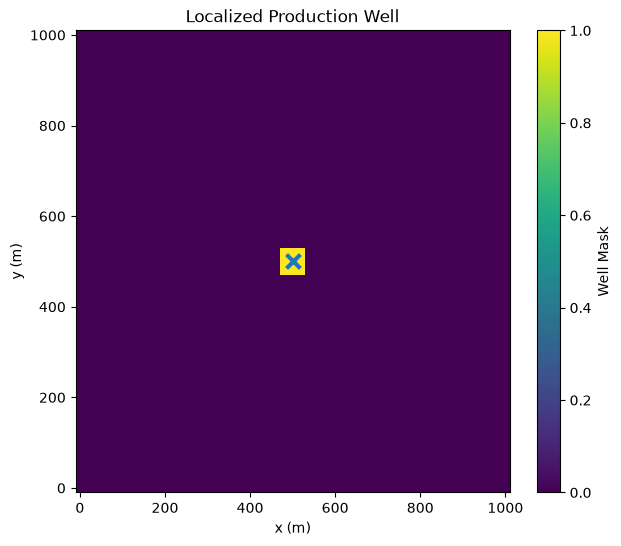

In [9]:
# ============================================================
# Visualize Localized Production Well
# ============================================================

plt.figure(figsize=(7, 6))

plt.pcolormesh(
    X_perm,
    Y_perm,
    well_mask.astype(float),
    shading="auto"
)

plt.scatter(
    well_x_actual,
    well_y_actual,
    marker="x",
    s=100,
    linewidths=3
)

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Localized Production Well")
plt.colorbar(label="Well Mask")

plt.savefig(
    "../results/localized_production_well.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
# ============================================================
# Define Normalized Production Strength
# ============================================================

well_source_strength = 0.01 * well_rate

print("Production Sink Configuration")
print("-----------------------------")
print(f"Well rate factor: {well_rate}")
print(f"Normalized source strength: {well_source_strength}")
print(f"Number of well cells: {well_mask.sum()}")

Production Sink Configuration
-----------------------------
Well rate factor: -1.0
Normalized source strength: -0.01
Number of well cells: 9


In [11]:
# ============================================================
# Create Localized Production Sink
# ============================================================

production_source = np.zeros_like(X_perm, dtype=float)

production_source[well_mask] = (
    well_source_strength / well_mask.sum()
)

print("Production Sink")
print("----------------")
print(f"Total sink strength: {production_source.sum():.6f}")
print(f"Minimum source value: {production_source.min():.6f}")
print(f"Maximum source value: {production_source.max():.6f}")
print(f"Active well cells: {(production_source != 0).sum()}")

Production Sink
----------------
Total sink strength: -0.010000
Minimum source value: -0.001111
Maximum source value: 0.000000
Active well cells: 9


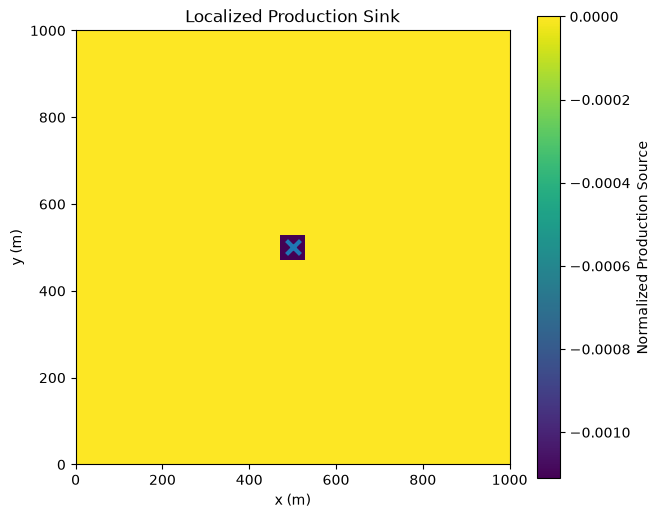

In [12]:
# ============================================================
# Visualize Production Sink - Correct Scale
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    production_source.T,
    origin="lower",
    extent=[
        x_physical.min(),
        x_physical.max(),
        y_physical.min(),
        y_physical.max()
    ],
    vmin=-0.0011111111111111111,
    vmax=0.0,
    aspect="equal"
)

ax.scatter(
    well_x_actual,
    well_y_actual,
    marker="x",
    s=100,
    linewidths=3
)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Localized Production Sink")

fig.colorbar(
    image,
    ax=ax,
    label="Normalized Production Source"
)

plt.savefig(
    "../results/production_sink.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
print("Production source check")
print("-----------------------")
print("Minimum:", production_source.min())
print("Maximum:", production_source.max())
print("Unique values:", np.unique(production_source))

Production source check
-----------------------
Minimum: -0.0011111111111111111
Maximum: 0.0
Unique values: [-0.00111111  0.        ]


In [14]:
# ============================================================
# Normalized Parameters for Well-Driven Reservoir
# ============================================================

# Reference permeability
k0 = 100.0  # mD

# Convert reference permeability to relative permeability field
kr_field = k_field_m2 / k_field_m2.mean()

# Reference diffusivity
alpha0 = k0 * 9.869233e-16 / (phi * mu * ct)

# Dimensionless diffusivity
alpha_star = alpha0 * T / (Lx**2)

# Physical and normalized time step
dt_physical = 300.0  # seconds
dt_star = dt_physical / T

print("Normalized Well-Driven Reservoir Parameters")
print("--------------------------------------------")
print(f"Reference permeability: {k0:.1f} mD")
print(f"Dimensionless diffusivity: {alpha_star:.6f}")
print(f"Physical time step: {dt_physical:.1f} s")
print(f"Normalized time step: {dt_star:.8f}")
print(f"Total simulation time: {T/86400:.1f} days")
print(f"Production source strength: {well_source_strength:.6f}")

Normalized Well-Driven Reservoir Parameters
--------------------------------------------
Reference permeability: 100.0 mD
Dimensionless diffusivity: 0.426351
Physical time step: 300.0 s
Normalized time step: 0.00011574
Total simulation time: 30.0 days
Production source strength: -0.010000


In [15]:
# ============================================================
# Numerical Stability Check and Initial Pressure
# ============================================================

# Dimensionless grid spacing
dx_star = dx / Lx
dy_star = dy / Ly

# Explicit 2D diffusion stability limit
dt_star_max = (
    1.0 / (
        2.0 * alpha_star *
        (1.0 / dx_star**2 + 1.0 / dy_star**2)
    )
)

# Initial pressure field
X_star = X_perm / Lx
Y_star = Y_perm / Ly

initial_pressure = (
    np.sin(np.pi * X_star) *
    np.sin(np.pi * Y_star)
)

print("Numerical Stability Check")
print("-------------------------")
print(f"dx*: {dx_star:.6f}")
print(f"dy*: {dy_star:.6f}")
print(f"Chosen dt*: {dt_star:.8f}")
print(f"Maximum stable dt*: {dt_star_max:.8f}")
print(f"Stability ratio: {dt_star / dt_star_max:.3f}")

print("\nInitial Pressure")
print("----------------")
print(f"Minimum: {initial_pressure.min():.6f}")
print(f"Maximum: {initial_pressure.max():.6f}")

Numerical Stability Check
-------------------------
dx*: 0.020000
dy*: 0.020000
Chosen dt*: 0.00011574
Maximum stable dt*: 0.00023455
Stability ratio: 0.493

Initial Pressure
----------------
Minimum: 0.000000
Maximum: 1.000000


In [16]:
# ============================================================
# Initialize Well-Driven Reservoir Simulation
# ============================================================

pressure_well = np.zeros(
    (len(time_heterogeneous), len(x_physical), len(y_physical)),
    dtype=np.float64
)

# Apply the initial pressure condition
pressure_well[0] = initial_pressure

print("Well-driven simulation initialized")
print("-----------------------------------")
print(f"Pressure array shape: {pressure_well.shape}")
print(f"Initial pressure minimum: {pressure_well[0].min():.6f}")
print(f"Initial pressure maximum: {pressure_well[0].max():.6f}")

Well-driven simulation initialized
-----------------------------------
Pressure array shape: (8641, 51, 51)
Initial pressure minimum: 0.000000
Initial pressure maximum: 1.000000


In [17]:
# ============================================================
# Prepare Face-Centered Permeability
# ============================================================

# Permeability at faces between neighboring cells
k_x_face = 0.5 * (
    k_field_m2[:-1, :] +
    k_field_m2[1:, :]
)

k_y_face = 0.5 * (
    k_field_m2[:, :-1] +
    k_field_m2[:, 1:]
)

print("Face-centered permeability prepared")
print("------------------------------------")
print(f"k_x_face shape: {k_x_face.shape}")
print(f"k_y_face shape: {k_y_face.shape}")

print(
    f"k_x_face range: "
    f"{k_x_face.min():.3e} to {k_x_face.max():.3e} m²"
)

print(
    f"k_y_face range: "
    f"{k_y_face.min():.3e} to {k_y_face.max():.3e} m²"
)

Face-centered permeability prepared
------------------------------------
k_x_face shape: (50, 51)
k_y_face shape: (51, 50)
k_x_face range: 4.954e-14 to 1.478e-13 m²
k_y_face range: 4.954e-14 to 1.478e-13 m²


In [18]:
# ============================================================
# Test One Production-Well Time Step
# ============================================================

p = pressure_well[0].copy()

# Heterogeneous diffusion term
flux_x = (
    k_x_face[1:, :] * (p[2:, :] - p[1:-1, :])
    - k_x_face[:-1, :] * (p[1:-1, :] - p[:-2, :])
) / dx**2

flux_y = (
    k_y_face[:, 1:] * (p[:, 2:] - p[:, 1:-1])
    - k_y_face[:, :-1] * (p[:, 1:-1] - p[:, :-2])
) / dy**2

# Convert physical flux term to pressure-rate term
diffusion_term = (
    flux_x[:, 1:-1] +
    flux_y[1:-1, :]
) / (phi * mu * ct)

# Convert to dimensionless pressure evolution
diffusion_term_normalized = T * diffusion_term

# Apply localized production sink
pressure_change = (
    dt_star *
    (diffusion_term_normalized + production_source[1:-1, 1:-1])
)

p_test = p.copy()

# Update only interior cells
p_test[1:-1, 1:-1] += pressure_change

print("One-step production-well test")
print("--------------------------------")
print(f"Initial pressure at well: {p[well_i, well_j]:.8f}")
print(f"Pressure after one step: {p_test[well_i, well_j]:.8f}")
print(f"Change at well: {p_test[well_i, well_j] - p[well_i, well_j]:.3e}")
print(f"Minimum pressure: {p_test.min():.8f}")
print(f"Maximum pressure: {p_test.max():.8f}")

One-step production-well test
--------------------------------
Initial pressure at well: 1.00000000
Pressure after one step: 0.99902616
Change at well: -9.738e-04
Minimum pressure: 0.00000000
Maximum pressure: 0.99902616


In [19]:
# ============================================================
# Run Full 30-Day Production-Well Reference Simulation
# ============================================================

for n in range(len(time_heterogeneous) - 1):

    p = pressure_well[n]

    # Heterogeneous diffusion term
    flux_x = (
        k_x_face[1:, :] * (p[2:, :] - p[1:-1, :])
        - k_x_face[:-1, :] * (p[1:-1, :] - p[:-2, :])
    ) / dx**2

    flux_y = (
        k_y_face[:, 1:] * (p[:, 2:] - p[:, 1:-1])
        - k_y_face[:, :-1] * (p[:, 1:-1] - p[:, :-2])
    ) / dy**2

    diffusion_term = (
        flux_x[:, 1:-1] +
        flux_y[1:-1, :]
    ) / (phi * mu * ct)

    # Convert to normalized time formulation
    diffusion_term_normalized = T * diffusion_term

    # Pressure update
    pressure_well[n + 1] = p.copy()

    pressure_well[n + 1, 1:-1, 1:-1] += (
        dt_star *
        (
            diffusion_term_normalized
            + production_source[1:-1, 1:-1]
        )
    )

    # Keep the outer boundary at zero pressure
    pressure_well[n + 1, 0, :] = 0.0
    pressure_well[n + 1, -1, :] = 0.0
    pressure_well[n + 1, :, 0] = 0.0
    pressure_well[n + 1, :, -1] = 0.0

print("Full production-well simulation completed")
print("--------------------------------------------")
print(f"Pressure array shape: {pressure_well.shape}")
print(f"Initial pressure maximum: {pressure_well[0].max():.6f}")
print(f"Final pressure minimum: {pressure_well[-1].min():.6f}")
print(f"Final pressure maximum: {pressure_well[-1].max():.6f}")
print(
    f"Final pressure at well: "
    f"{pressure_well[-1, well_i, well_j]:.6f}"
)

Full production-well simulation completed
--------------------------------------------
Pressure array shape: (8641, 51, 51)
Initial pressure maximum: 1.000000
Final pressure minimum: 0.000000
Final pressure maximum: 0.000254
Final pressure at well: 0.000253


In [20]:
# ============================================================
# Save Production-Well Reference Solution
# ============================================================

np.savez(
    "../data/reference_well_driven_reservoir.npz",
    x=x_physical,
    y=y_physical,
    time=time_heterogeneous,
    pressure=pressure_well,
    permeability_mD=k_field_mD,
    permeability_m2=k_field_m2,
    well_x=well_x_actual,
    well_y=well_y_actual,
    well_radius=well_radius,
    well_rate=well_rate,
    well_source_strength=well_source_strength,
    phi=phi,
    mu=mu,
    ct=ct,
    dt=dt_physical
)

print("Production-well reference solution saved")
print("-----------------------------------------")
print("File: ../data/reference_well_driven_reservoir.npz")
print(f"Pressure shape: {pressure_well.shape}")

Production-well reference solution saved
-----------------------------------------
File: ../data/reference_well_driven_reservoir.npz
Pressure shape: (8641, 51, 51)


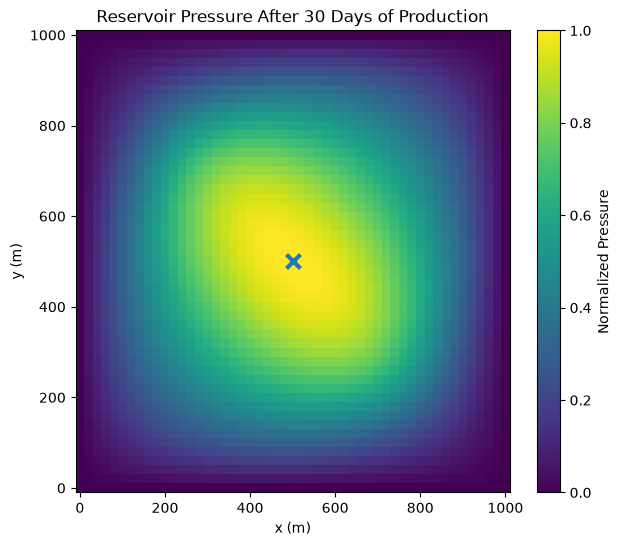

In [21]:
# ============================================================
# Visualize 30-Day Production-Well Pressure
# ============================================================

pressure_30d = pressure_well[-1]

plt.figure(figsize=(7, 6))

plt.pcolormesh(
    X_perm,
    Y_perm,
    pressure_30d,
    shading="auto"
)

plt.scatter(
    well_x_actual,
    well_y_actual,
    marker="x",
    s=100,
    linewidths=3
)

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Reservoir Pressure After 30 Days of Production")

plt.colorbar(label="Normalized Pressure")

plt.savefig(
    "../results/reference_well_driven_pressure_t30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# ============================================================
# Check Pressure Drawdown Around Production Well
# ============================================================

center_pressure = pressure_well[-1, well_i, well_j]

neighbor_pressures = [
    pressure_well[-1, well_i + 1, well_j],
    pressure_well[-1, well_i - 1, well_j],
    pressure_well[-1, well_i, well_j + 1],
    pressure_well[-1, well_i, well_j - 1]
]

print("Production Well Pressure Diagnostic")
print("-----------------------------------")
print(f"Well pressure: {center_pressure:.8f}")
print(f"Mean neighboring pressure: {np.mean(neighbor_pressures):.8f}")
print(f"Maximum neighboring pressure: {np.max(neighbor_pressures):.8f}")
print(f"Minimum neighboring pressure: {np.min(neighbor_pressures):.8f}")

print("\nLocal drawdown relative to neighbors:")
print(
    f"{np.mean(neighbor_pressures) - center_pressure:.3e}"
)

Production Well Pressure Diagnostic
-----------------------------------
Well pressure: 0.00025347
Mean neighboring pressure: 0.00025323
Maximum neighboring pressure: 0.00025323
Minimum neighboring pressure: 0.00025323

Local drawdown relative to neighbors:
-2.392e-07


In [23]:
# ============================================================
# Test Stronger Production Strength
# ============================================================

test_source_strength = -0.05

test_production_source = np.zeros_like(X_perm, dtype=float)

test_production_source[well_mask] = (
    test_source_strength / well_mask.sum()
)

print("Stronger Production Test")
print("------------------------")
print(f"Test source strength: {test_source_strength:.6f}")
print(f"Source per well cell: {test_production_source[well_mask][0]:.6f}")
print(f"Total sink strength: {test_production_source.sum():.6f}")

Stronger Production Test
------------------------
Test source strength: -0.050000
Source per well cell: -0.005556
Total sink strength: -0.050000


In [24]:
# ============================================================
# Full 30-Day Stronger Production Test
# ============================================================

pressure_test = np.zeros_like(pressure_well)
pressure_test[0] = initial_pressure

for n in range(len(time_heterogeneous) - 1):

    p = pressure_test[n]

    # Heterogeneous diffusion term
    flux_x = (
        k_x_face[1:, :] * (p[2:, :] - p[1:-1, :])
        - k_x_face[:-1, :] * (p[1:-1, :] - p[:-2, :])
    ) / dx**2

    flux_y = (
        k_y_face[:, 1:] * (p[:, 2:] - p[:, 1:-1])
        - k_y_face[:, :-1] * (p[:, 1:-1] - p[:, :-2])
    ) / dy**2

    diffusion_term = (
        flux_x[:, 1:-1] +
        flux_y[1:-1, :]
    ) / (phi * mu * ct)

    diffusion_term_normalized = T * diffusion_term

    # Update interior
    pressure_test[n + 1] = p.copy()

    pressure_test[n + 1, 1:-1, 1:-1] += (
        dt_star *
        (
            diffusion_term_normalized
            + test_production_source[1:-1, 1:-1]
        )
    )

    # Zero-pressure outer boundaries
    pressure_test[n + 1, 0, :] = 0.0
    pressure_test[n + 1, -1, :] = 0.0
    pressure_test[n + 1, :, 0] = 0.0
    pressure_test[n + 1, :, -1] = 0.0

# Diagnostics
test_well_pressure = pressure_test[-1, well_i, well_j]

test_neighbor_pressures = [
    pressure_test[-1, well_i + 1, well_j],
    pressure_test[-1, well_i - 1, well_j],
    pressure_test[-1, well_i, well_j + 1],
    pressure_test[-1, well_i, well_j - 1]
]

test_neighbor_mean = np.mean(test_neighbor_pressures)

print("Stronger Production Test Results")
print("---------------------------------")
print(f"Final minimum pressure: {pressure_test[-1].min():.8f}")
print(f"Final maximum pressure: {pressure_test[-1].max():.8f}")
print(f"Well pressure: {test_well_pressure:.8f}")
print(f"Mean neighboring pressure: {test_neighbor_mean:.8f}")
print(
    f"Local drawdown: "
    f"{test_neighbor_mean - test_well_pressure:.3e}"
)

Stronger Production Test Results
---------------------------------
Final minimum pressure: 0.00000000
Final maximum pressure: 0.00024042
Well pressure: 0.00023352
Mean neighboring pressure: 0.00023433
Local drawdown: 8.033e-07


In [25]:
# ============================================================
# Production Drawdown Diagnostic at 5 Days
# ============================================================

target_days = 5.0

target_index = np.argmin(
    np.abs(time_heterogeneous - target_days * 86400)
)

p_5d = pressure_test[target_index]

well_pressure_5d = p_5d[well_i, well_j]

neighbor_pressures_5d = [
    p_5d[well_i + 1, well_j],
    p_5d[well_i - 1, well_j],
    p_5d[well_i, well_j + 1],
    p_5d[well_i, well_j - 1]
]

neighbor_mean_5d = np.mean(neighbor_pressures_5d)

print("Production Well Diagnostic at 5 Days")
print("------------------------------------")
print(f"Actual time: {time_heterogeneous[target_index]/86400:.2f} days")
print(f"Well pressure: {well_pressure_5d:.8f}")
print(f"Mean neighboring pressure: {neighbor_mean_5d:.8f}")
print(
    f"Local drawdown: "
    f"{neighbor_mean_5d - well_pressure_5d:.6e}"
)
print(f"Reservoir maximum pressure: {p_5d.max():.8f}")

Production Well Diagnostic at 5 Days
------------------------------------
Actual time: 5.00 days
Well pressure: 0.24990206
Mean neighboring pressure: 0.24941952
Local drawdown: -4.825402e-04
Reservoir maximum pressure: 0.24990206


In [26]:
# ============================================================
# Uniform Initial Pressure for Production-Well Benchmark
# ============================================================

initial_pressure_well = np.ones_like(X_perm, dtype=float)

print("Uniform Initial Pressure")
print("------------------------")
print(f"Minimum pressure: {initial_pressure_well.min():.6f}")
print(f"Maximum pressure: {initial_pressure_well.max():.6f}")
print(f"Well pressure: {initial_pressure_well[well_i, well_j]:.6f}")

Uniform Initial Pressure
------------------------
Minimum pressure: 1.000000
Maximum pressure: 1.000000
Well pressure: 1.000000


In [27]:
# ============================================================
# Initialize Uniform-Pressure Production-Well Simulation
# ============================================================

pressure_well_uniform = np.zeros_like(pressure_well)

# Apply uniform initial pressure
pressure_well_uniform[0] = initial_pressure_well

print("Uniform-pressure simulation initialized")
print("-----------------------------------------")
print(f"Pressure array shape: {pressure_well_uniform.shape}")
print(f"Initial minimum: {pressure_well_uniform[0].min():.6f}")
print(f"Initial maximum: {pressure_well_uniform[0].max():.6f}")
print(
    f"Initial well pressure: "
    f"{pressure_well_uniform[0, well_i, well_j]:.6f}"
)

Uniform-pressure simulation initialized
-----------------------------------------
Pressure array shape: (8641, 51, 51)
Initial minimum: 1.000000
Initial maximum: 1.000000
Initial well pressure: 1.000000


In [28]:
# ============================================================
# One-Step Test: Uniform Reservoir + Production Well
# ============================================================

p = pressure_well_uniform[0].copy()

# Heterogeneous diffusion term
flux_x = (
    k_x_face[1:, :] * (p[2:, :] - p[1:-1, :])
    - k_x_face[:-1, :] * (p[1:-1, :] - p[:-2, :])
) / dx**2

flux_y = (
    k_y_face[:, 1:] * (p[:, 2:] - p[:, 1:-1])
    - k_y_face[:, :-1] * (p[:, 1:-1] - p[:, :-2])
) / dy**2

diffusion_term = (
    flux_x[:, 1:-1] +
    flux_y[1:-1, :]
) / (phi * mu * ct)

diffusion_term_normalized = T * diffusion_term

# Apply production sink
pressure_change = (
    dt_star *
    (
        diffusion_term_normalized
        + test_production_source[1:-1, 1:-1]
    )
)

p_test_uniform = p.copy()

# Update interior cells
p_test_uniform[1:-1, 1:-1] += pressure_change

print("One-Step Uniform-Pressure Production Test")
print("-------------------------------------------")
print(f"Initial well pressure: {p[well_i, well_j]:.8f}")
print(
    f"Pressure after one step: "
    f"{p_test_uniform[well_i, well_j]:.8f}"
)
print(
    f"Change at well: "
    f"{p_test_uniform[well_i, well_j] - p[well_i, well_j]:.3e}"
)
print(f"Minimum pressure: {p_test_uniform.min():.8f}")
print(f"Maximum pressure: {p_test_uniform.max():.8f}")

One-Step Uniform-Pressure Production Test
-------------------------------------------
Initial well pressure: 1.00000000
Pressure after one step: 0.99999936
Change at well: -6.430e-07
Minimum pressure: 0.99999936
Maximum pressure: 1.00000000


In [29]:
# ============================================================
# Full 30-Day Uniform-Pressure Production Simulation
# ============================================================

pressure_well_uniform = np.zeros_like(pressure_well)

pressure_well_uniform[0] = initial_pressure_well

for n in range(len(time_heterogeneous) - 1):

    p = pressure_well_uniform[n]

    # Heterogeneous diffusion term
    flux_x = (
        k_x_face[1:, :] * (p[2:, :] - p[1:-1, :])
        - k_x_face[:-1, :] * (p[1:-1, :] - p[:-2, :])
    ) / dx**2

    flux_y = (
        k_y_face[:, 1:] * (p[:, 2:] - p[:, 1:-1])
        - k_y_face[:, :-1] * (p[:, 1:-1] - p[:, :-2])
    ) / dy**2

    diffusion_term = (
        flux_x[:, 1:-1] +
        flux_y[1:-1, :]
    ) / (phi * mu * ct)

    diffusion_term_normalized = T * diffusion_term

    # Update interior cells
    pressure_well_uniform[n + 1] = p.copy()

    pressure_well_uniform[n + 1, 1:-1, 1:-1] += (
        dt_star *
        (
            diffusion_term_normalized
            + test_production_source[1:-1, 1:-1]
        )
    )

    # Zero-pressure outer boundaries
    pressure_well_uniform[n + 1, 0, :] = 0.0
    pressure_well_uniform[n + 1, -1, :] = 0.0
    pressure_well_uniform[n + 1, :, 0] = 0.0
    pressure_well_uniform[n + 1, :, -1] = 0.0

print("Full Uniform-Pressure Production Simulation")
print("---------------------------------------------")
print(f"Pressure array shape: {pressure_well_uniform.shape}")
print(f"Initial pressure: {pressure_well_uniform[0].max():.6f}")
print(f"Final minimum pressure: {pressure_well_uniform[-1].min():.6f}")
print(f"Final maximum pressure: {pressure_well_uniform[-1].max():.6f}")
print(
    f"Final well pressure: "
    f"{pressure_well_uniform[-1, well_i, well_j]:.6f}"
)

Full Uniform-Pressure Production Simulation
---------------------------------------------
Pressure array shape: (8641, 51, 51)
Initial pressure: 1.000000
Final minimum pressure: 0.000000
Final maximum pressure: 0.000398
Final well pressure: 0.000393


In [30]:
# ============================================================
# Final Production-Well Drawdown Diagnostic
# ============================================================

p_final = pressure_well_uniform[-1]

well_pressure_final = p_final[well_i, well_j]

neighbor_pressures_final = [
    p_final[well_i + 1, well_j],
    p_final[well_i - 1, well_j],
    p_final[well_i, well_j + 1],
    p_final[well_i, well_j - 1]
]

neighbor_mean_final = np.mean(neighbor_pressures_final)

print("Final Production-Well Diagnostic")
print("---------------------------------")
print(f"Well pressure: {well_pressure_final:.8f}")
print(f"Mean neighboring pressure: {neighbor_mean_final:.8f}")
print(
    f"Local drawdown: "
    f"{neighbor_mean_final - well_pressure_final:.6e}"
)
print(f"Reservoir maximum: {p_final.max():.8f}")
print(f"Reservoir minimum: {p_final.min():.8f}")

Final Production-Well Diagnostic
---------------------------------
Well pressure: 0.00039337
Mean neighboring pressure: 0.00039386
Local drawdown: 4.941769e-07
Reservoir maximum: 0.00039850
Reservoir minimum: 0.00000000


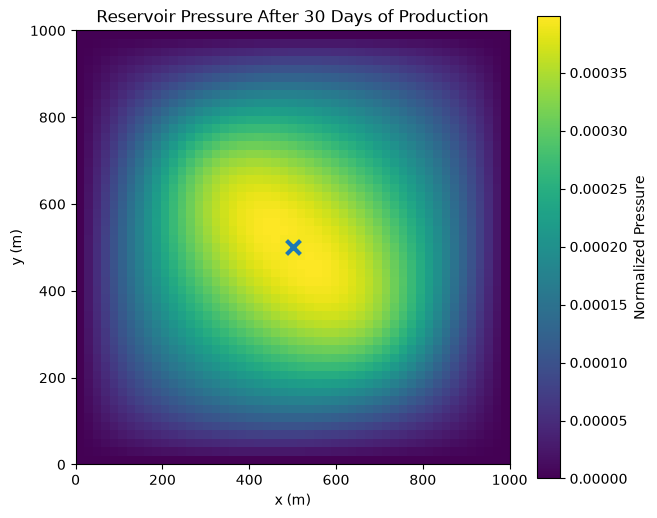

In [31]:
# ============================================================
# Visualize Final Production-Well Pressure
# ============================================================

pressure_final_uniform = pressure_well_uniform[-1]

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    pressure_final_uniform.T,
    origin="lower",
    extent=[
        x_physical.min(),
        x_physical.max(),
        y_physical.min(),
        y_physical.max()
    ],
    vmin=pressure_final_uniform.min(),
    vmax=pressure_final_uniform.max(),
    aspect="equal"
)

ax.scatter(
    well_x_actual,
    well_y_actual,
    marker="x",
    s=100,
    linewidths=3
)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Reservoir Pressure After 30 Days of Production")

fig.colorbar(
    image,
    ax=ax,
    label="Normalized Pressure"
)

plt.savefig(
    "../results/reference_well_driven_pressure_t30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
# ============================================================
# Save Final Production-Well Reference Solution
# ============================================================

np.savez(
    "../data/reference_well_driven_reservoir.npz",
    x=x_physical,
    y=y_physical,
    time=time_heterogeneous,
    pressure=pressure_well_uniform,
    permeability_mD=k_field_mD,
    permeability_m2=k_field_m2,
    well_x=well_x_actual,
    well_y=well_y_actual,
    well_radius=well_radius,
    well_rate=well_rate,
    well_source_strength=test_source_strength,
    phi=phi,
    mu=mu,
    ct=ct,
    dt=dt_physical
)

print("Final production-well reference solution saved")
print("-----------------------------------------------")
print("File: ../data/reference_well_driven_reservoir.npz")
print(f"Pressure shape: {pressure_well_uniform.shape}")
print(f"Well rate factor: {well_rate}")
print(f"Source strength: {test_source_strength}")
print(f"Well radius: {well_radius:.1f} m")

Final production-well reference solution saved
-----------------------------------------------
File: ../data/reference_well_driven_reservoir.npz
Pressure shape: (8641, 51, 51)
Well rate factor: -1.0
Source strength: -0.05
Well radius: 30.0 m


In [33]:
# ============================================================
# Normalized Coordinates for Production-Well PINN
# ============================================================

x_star = x_physical / Lx
y_star = y_physical / Ly
t_star = time_heterogeneous / T

print("Normalized PINN Coordinates")
print("---------------------------")
print(f"x* range: {x_star.min():.3f} to {x_star.max():.3f}")
print(f"y* range: {y_star.min():.3f} to {y_star.max():.3f}")
print(f"t* range: {t_star.min():.3f} to {t_star.max():.3f}")

print("\nNormalized Well Location")
print("------------------------")
print(f"x_w*: {well_x_actual / Lx:.3f}")
print(f"y_w*: {well_y_actual / Ly:.3f}")
print(f"Well radius*: {well_radius / Lx:.3f}")

Normalized PINN Coordinates
---------------------------
x* range: 0.000 to 1.000
y* range: 0.000 to 1.000
t* range: 0.000 to 1.000

Normalized Well Location
------------------------
x_w*: 0.500
y_w*: 0.500
Well radius*: 0.030


In [34]:
# ============================================================
# Production Source Function for PINN
# ============================================================

well_radius_star = well_radius / Lx

def production_source_function(X):
    """
    Returns the normalized production source at PINN points.

    X[:, 0] = x*
    X[:, 1] = y*
    X[:, 2] = t*
    """

    x = X[:, 0:1]
    y = X[:, 1:2]

    distance = tf.sqrt(
        (x - well_x_actual / Lx)**2 +
        (y - well_y_actual / Ly)**2
    )

    inside_well = tf.cast(
        distance <= well_radius_star,
        tf.float32
    )

    source_per_cell = (
        test_source_strength / well_mask.sum()
    )

    return source_per_cell * inside_well


print("Production Source Function")
print("---------------------------")
print(f"Well center: ({well_x_actual/Lx:.3f}, {well_y_actual/Ly:.3f})")
print(f"Well radius*: {well_radius_star:.3f}")
print(f"Total source strength: {test_source_strength:.6f}")
print(f"Source per active cell: {source_per_cell if 'source_per_cell' in locals() else test_source_strength / well_mask.sum():.6f}")

Production Source Function
---------------------------
Well center: (0.500, 0.500)
Well radius*: 0.030
Total source strength: -0.050000
Source per active cell: -0.005556


In [35]:
# ============================================================
# Test Production Source Function
# ============================================================

test_points = tf.constant([
    [0.50, 0.50, 0.50],  # Well center
    [0.00, 0.00, 0.50],  # Reservoir corner
    [0.50, 0.60, 0.50],  # Outside well radius
], dtype=tf.float32)

test_sources = production_source_function(test_points)

print("Production Source Function Test")
print("--------------------------------")

for point, source in zip(test_points.numpy(), test_sources.numpy()):
    print(
        f"(x*, y*, t*) = "
        f"({point[0]:.2f}, {point[1]:.2f}, {point[2]:.2f}) "
        f"-> source = {source[0]:.6f}"
    )

Production Source Function Test
--------------------------------
(x*, y*, t*) = (0.50, 0.50, 0.50) -> source = -0.005556
(x*, y*, t*) = (0.00, 0.00, 0.50) -> source = -0.000000
(x*, y*, t*) = (0.50, 0.60, 0.50) -> source = -0.000000


In [36]:
# ============================================================
# Production-Well PINN Architecture
# ============================================================

def build_well_pinn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(3,)),
        tf.keras.layers.Dense(50, activation="tanh"),
        tf.keras.layers.Dense(50, activation="tanh"),
        tf.keras.layers.Dense(50, activation="tanh"),
        tf.keras.layers.Dense(50, activation="tanh"),
        tf.keras.layers.Dense(1)
    ])

    return model


well_pinn = build_well_pinn()

well_pinn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,901 (30.86 KB)

 Trainable params: 7,901 (30.86 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# ============================================================
# Physics Residual for Production-Well PINN
# ============================================================

def well_pinn_residual(model, X):
    """
    Compute the PDE residual for the heterogeneous
    reservoir with a localized production well.

    X columns:
        X[:, 0] = x*
        X[:, 1] = y*
        X[:, 2] = t*
    """

    with tf.GradientTape(persistent=True) as tape2:

        tape2.watch(X)

        with tf.GradientTape(persistent=True) as tape1:

            tape1.watch(X)

            pressure = model(X)

        # First derivatives
        pressure_grad = tape1.gradient(
            pressure,
            X
        )

        p_x = pressure_grad[:, 0:1]
        p_y = pressure_grad[:, 1:2]
        p_t = pressure_grad[:, 2:3]

    # Relative permeability at arbitrary PINN points
    x = X[:, 0:1]
    y = X[:, 1:2]

    kr = (
        1.0
        + 0.5
        * tf.sin(2.0 * np.pi * x)
        * tf.sin(2.0 * np.pi * y)
    )

    # Derivatives of kr * pressure gradients
    kr_px = kr * p_x
    kr_py = kr * p_y

    d_kr_px_dx = tape2.gradient(
        kr_px,
        X
    )[:, 0:1]

    d_kr_py_dy = tape2.gradient(
        kr_py,
        X
    )[:, 1:2]

    # Localized production source
    source = production_source_function(X)

    # PDE residual
    residual = (
        p_t
        - alpha_star * (
            d_kr_px_dx
            + d_kr_py_dy
        )
        - source
    )

    del tape1
    del tape2

    return residual


print("Production-well PINN residual function defined.")

Production-well PINN residual function defined.


In [38]:
def well_pinn_residual(model, X):

    with tf.GradientTape(persistent=True) as tape2:

        tape2.watch(X)

        with tf.GradientTape() as tape1:

            tape1.watch(X)

            pressure = model(X)

        # First derivatives
        pressure_grad = tape1.gradient(pressure, X)

        p_x = pressure_grad[:, 0:1]
        p_y = pressure_grad[:, 1:2]
        p_t = pressure_grad[:, 2:3]

        # Coordinates
        x = X[:, 0:1]
        y = X[:, 1:2]

        # Relative permeability
        kr = (
            1.0
            + 0.5
            * tf.sin(2.0 * np.pi * x)
            * tf.sin(2.0 * np.pi * y)
        )

        # Flux terms
        kr_px = kr * p_x
        kr_py = kr * p_y

    # Second derivatives of the flux terms
    d_kr_px_dx = tape2.gradient(kr_px, X)[:, 0:1]
    d_kr_py_dy = tape2.gradient(kr_py, X)[:, 1:2]

    # Production-well source
    source = production_source_function(X)

    # PDE residual
    residual = (
        p_t
        - alpha_star * (d_kr_px_dx + d_kr_py_dy)
        - source
    )

    del tape2

    return residual


print("Production-well PINN residual function defined.")

Production-well PINN residual function defined.


In [39]:
# Test the production-well PINN residual

X_test = tf.convert_to_tensor(
    np.array([
        [0.50, 0.50, 0.50],  # well center
        [0.10, 0.10, 0.50],  # away from well
        [0.90, 0.90, 0.50],  # away from well
        [0.52, 0.50, 0.50],  # near well
        [0.50, 0.50, 1.00],  # well at final time
    ]),
    dtype=tf.float32
)

residual_test = well_pinn_residual(well_pinn, X_test)

print("Residual shape:", residual_test.shape)
print("Residual values:")
print(residual_test.numpy())

print("\nAll residuals finite:",
      np.all(np.isfinite(residual_test.numpy())))

Residual shape: (5, 1)
Residual values:
[[0.15265466]
 [0.04945324]
 [0.15757237]
 [0.1585179 ]
 [0.10557175]]

All residuals finite: True


In [40]:
# Generate physics collocation points

N_physics = 10000

X_physics = np.random.rand(N_physics, 3)

print("Physics points shape:", X_physics.shape)
print("Minimum values:", X_physics.min(axis=0))
print("Maximum values:", X_physics.max(axis=0))

Physics points shape: (10000, 3)
Minimum values: [2.43091962e-05 1.43923516e-05 1.47202087e-04]
Maximum values: [0.9998386  0.99997529 0.99987008]


In [41]:
# Generate initial-condition points

N_initial = 1000

X_initial = np.column_stack([
    np.random.rand(N_initial),  # x*
    np.random.rand(N_initial),  # y*
    np.zeros(N_initial)         # t* = 0
])

y_initial = np.ones((N_initial, 1))

print("Initial-condition points shape:", X_initial.shape)
print("Initial pressure shape:", y_initial.shape)
print("Time values:", np.unique(X_initial[:, 2]))
print("Pressure values:", np.unique(y_initial))

Initial-condition points shape: (1000, 3)
Initial pressure shape: (1000, 1)
Time values: [0.]
Pressure values: [1.]


In [42]:
# Generate boundary-condition points

N_boundary = 4000

# Random y, t for x = 0 and x = 1
y_boundary_1 = np.random.rand(N_boundary // 4)
t_boundary_1 = np.random.rand(N_boundary // 4)

X_left = np.column_stack([
    np.zeros(N_boundary // 4),
    y_boundary_1,
    t_boundary_1
])

X_right = np.column_stack([
    np.ones(N_boundary // 4),
    y_boundary_1,
    t_boundary_1
])

# Random x, t for y = 0 and y = 1
x_boundary_2 = np.random.rand(N_boundary // 4)
t_boundary_2 = np.random.rand(N_boundary // 4)

X_bottom = np.column_stack([
    x_boundary_2,
    np.zeros(N_boundary // 4),
    t_boundary_2
])

X_top = np.column_stack([
    x_boundary_2,
    np.ones(N_boundary // 4),
    t_boundary_2
])

# Combine all boundaries
X_boundary = np.vstack([
    X_left,
    X_right,
    X_bottom,
    X_top
])

# Boundary pressure = 0
y_boundary = np.zeros((N_boundary, 1))

print("Boundary points shape:", X_boundary.shape)
print("Boundary pressure shape:", y_boundary.shape)
print("Pressure values:", np.unique(y_boundary))
print("Minimum coordinates:", X_boundary.min(axis=0))
print("Maximum coordinates:", X_boundary.max(axis=0))

Boundary points shape: (4000, 3)
Boundary pressure shape: (4000, 1)
Pressure values: [0.]
Minimum coordinates: [0.         0.         0.00031507]
Maximum coordinates: [1.         1.         0.99997194]


In [43]:
# Convert training data to TensorFlow tensors

X_physics_tf = tf.convert_to_tensor(X_physics, dtype=tf.float32)

X_initial_tf = tf.convert_to_tensor(X_initial, dtype=tf.float32)
y_initial_tf = tf.convert_to_tensor(y_initial, dtype=tf.float32)

X_boundary_tf = tf.convert_to_tensor(X_boundary, dtype=tf.float32)
y_boundary_tf = tf.convert_to_tensor(y_boundary, dtype=tf.float32)

print("Physics tensor:", X_physics_tf.shape)
print("Initial tensor:", X_initial_tf.shape, y_initial_tf.shape)
print("Boundary tensor:", X_boundary_tf.shape, y_boundary_tf.shape)

Physics tensor: (10000, 3)
Initial tensor: (1000, 3) (1000, 1)
Boundary tensor: (4000, 3) (4000, 1)


In [44]:
def well_pinn_losses(model):

    # Physics loss
    residual = well_pinn_residual(model, X_physics_tf)
    physics_loss = tf.reduce_mean(tf.square(residual))

    # Initial-condition loss
    initial_prediction = model(X_initial_tf)
    initial_loss = tf.reduce_mean(
        tf.square(initial_prediction - y_initial_tf)
    )

    # Boundary-condition loss
    boundary_prediction = model(X_boundary_tf)
    boundary_loss = tf.reduce_mean(
        tf.square(boundary_prediction - y_boundary_tf)
    )

    return physics_loss, initial_loss, boundary_loss


print("Production-well PINN loss function defined.")

Production-well PINN loss function defined.


In [45]:
# Check the initial PINN losses

physics_loss, initial_loss, boundary_loss = well_pinn_losses(well_pinn)

print("Initial loss:", initial_loss.numpy())
print("Boundary loss:", boundary_loss.numpy())
print("Physics loss:", physics_loss.numpy())

Initial loss: 0.84305537
Boundary loss: 0.020850979
Physics loss: 0.028624633


In [46]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Optimizer defined.")
print("Learning rate:", optimizer.learning_rate.numpy())

Optimizer defined.
Learning rate: 0.001


In [47]:
@tf.function
def train_step(model):

    with tf.GradientTape() as tape:

        physics_loss, initial_loss, boundary_loss = well_pinn_losses(model)

        total_loss = (
            physics_loss
            + initial_loss
            + boundary_loss
        )

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return total_loss, physics_loss, initial_loss, boundary_loss


print("Training step defined.")

Training step defined.


In [48]:
# Test one training step

total_loss_before = sum(
    loss.numpy()
    for loss in well_pinn_losses(well_pinn)
)

total_loss, physics_loss, initial_loss, boundary_loss = train_step(well_pinn)

print("Total loss after one training step:", total_loss.numpy())
print("Physics loss:", physics_loss.numpy())
print("Initial loss:", initial_loss.numpy())
print("Boundary loss:", boundary_loss.numpy())

Total loss after one training step: 0.892531
Physics loss: 0.028624633
Initial loss: 0.84305537
Boundary loss: 0.020850979


In [49]:
# Train the production-well PINN

epochs = 5000

history = {
    "total": [],
    "physics": [],
    "initial": [],
    "boundary": []
}

for epoch in range(epochs):

    total_loss, physics_loss, initial_loss, boundary_loss = train_step(well_pinn)

    history["total"].append(total_loss.numpy())
    history["physics"].append(physics_loss.numpy())
    history["initial"].append(initial_loss.numpy())
    history["boundary"].append(boundary_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total: {total_loss.numpy():.6f} | "
            f"Physics: {physics_loss.numpy():.6f} | "
            f"Initial: {initial_loss.numpy():.6f} | "
            f"Boundary: {boundary_loss.numpy():.6f}"
        )

print("\nTraining complete.")

Epoch    0 | Total: 0.658357 | Physics: 0.035383 | Initial: 0.557879 | Boundary: 0.065095
Epoch  500 | Total: 0.205813 | Physics: 0.070616 | Initial: 0.052717 | Boundary: 0.082480
Epoch 1000 | Total: 0.106976 | Physics: 0.016814 | Initial: 0.036394 | Boundary: 0.053768
Epoch 1500 | Total: 0.073673 | Physics: 0.013078 | Initial: 0.020856 | Boundary: 0.039738
Epoch 2000 | Total: 0.051635 | Physics: 0.011247 | Initial: 0.013710 | Boundary: 0.026678
Epoch 2500 | Total: 0.035788 | Physics: 0.006260 | Initial: 0.008391 | Boundary: 0.021137
Epoch 3000 | Total: 0.031654 | Physics: 0.006416 | Initial: 0.007204 | Boundary: 0.018034
Epoch 3500 | Total: 0.027055 | Physics: 0.004305 | Initial: 0.007016 | Boundary: 0.015733
Epoch 4000 | Total: 0.024422 | Physics: 0.003586 | Initial: 0.006400 | Boundary: 0.014437
Epoch 4500 | Total: 0.022096 | Physics: 0.003073 | Initial: 0.005866 | Boundary: 0.013157

Training complete.


In [50]:
# Save production-well PINN training history

np.savez(
    "../results/well_driven_pinn_training_history.npz",
    total=np.array(history["total"]),
    physics=np.array(history["physics"]),
    initial=np.array(history["initial"]),
    boundary=np.array(history["boundary"])
)

print("Training history saved.")

Training history saved.


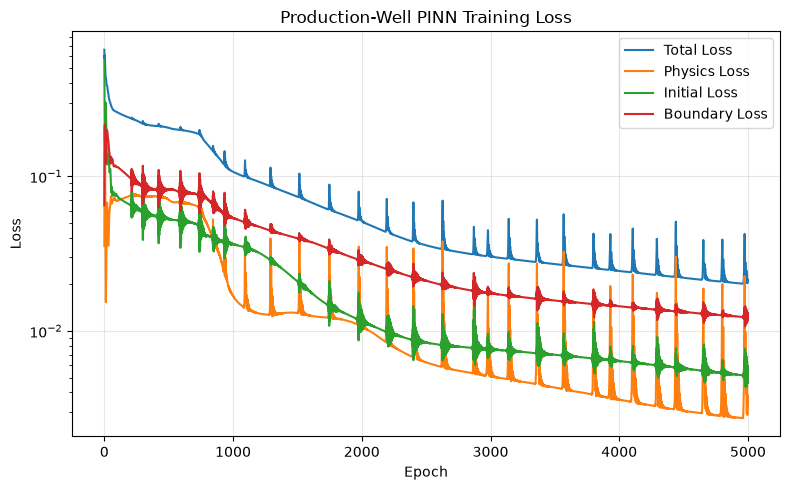

In [51]:
# Plot production-well PINN training loss

plt.figure(figsize=(8, 5))

plt.semilogy(history["total"], label="Total Loss")
plt.semilogy(history["physics"], label="Physics Loss")
plt.semilogy(history["initial"], label="Initial Loss")
plt.semilogy(history["boundary"], label="Boundary Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Production-Well PINN Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/well_driven_pinn_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
# Evaluate the PINN at the final time (30 days)

X_final = np.column_stack([
    X_perm.ravel() / Lx,
    Y_perm.ravel() / Ly,
    np.ones(X_perm.size)
])

X_final_tf = tf.convert_to_tensor(X_final, dtype=tf.float32)

pressure_pinn_final = well_pinn(X_final_tf).numpy().reshape(
    X_perm.shape
)

pressure_reference_final = pressure_well_uniform[-1]

absolute_error_final = np.abs(
    pressure_pinn_final - pressure_reference_final
)

print("PINN pressure shape:", pressure_pinn_final.shape)
print("Reference pressure shape:", pressure_reference_final.shape)

print("\nReference pressure:")
print("  Min:", pressure_reference_final.min())
print("  Max:", pressure_reference_final.max())

print("\nPINN pressure:")
print("  Min:", pressure_pinn_final.min())
print("  Max:", pressure_pinn_final.max())

print("\nAbsolute error:")
print("  MAE:", absolute_error_final.mean())
print("  Max error:", absolute_error_final.max())

PINN pressure shape: (51, 51)
Reference pressure shape: (51, 51)

Reference pressure:
  Min: 0.0
  Max: 0.00039849775910436903

PINN pressure:
  Min: -0.006382077
  Max: 0.0067053745

Absolute error:
  MAE: 0.003143266108436876
  Max error: 0.0067053744569420815


In [53]:
# Diagnose final-time boundary and production-well behavior

# Boundary values from the PINN
left_boundary = pressure_pinn_final[0, :]
right_boundary = pressure_pinn_final[-1, :]
bottom_boundary = pressure_pinn_final[:, 0]
top_boundary = pressure_pinn_final[:, -1]

boundary_values = np.concatenate([
    left_boundary,
    right_boundary,
    bottom_boundary,
    top_boundary
])

# Well pressure
well_pressure_pinn = pressure_pinn_final[well_i, well_j]
well_pressure_reference = pressure_reference_final[well_i, well_j]

# Reference and PINN neighboring pressure
neighbor_indices = [
    (well_i - 1, well_j),
    (well_i + 1, well_j),
    (well_i, well_j - 1),
    (well_i, well_j + 1)
]

pinn_neighbors = np.array([
    pressure_pinn_final[i, j]
    for i, j in neighbor_indices
])

reference_neighbors = np.array([
    pressure_reference_final[i, j]
    for i, j in neighbor_indices
])

print("Final-time boundary:")
print("  Mean absolute boundary pressure:",
      np.mean(np.abs(boundary_values)))
print("  Maximum absolute boundary pressure:",
      np.max(np.abs(boundary_values)))

print("\nProduction well pressure:")
print("  Reference:", well_pressure_reference)
print("  PINN:", well_pressure_pinn)

print("\nNeighbor pressure:")
print("  Reference mean:", reference_neighbors.mean())
print("  PINN mean:", pinn_neighbors.mean())

print("\nLocal drawdown:")
print("  Reference:",
      reference_neighbors.mean() - well_pressure_reference)
print("  PINN:",
      pinn_neighbors.mean() - well_pressure_pinn)

Final-time boundary:
  Mean absolute boundary pressure: 0.0035682905
  Maximum absolute boundary pressure: 0.0067053745

Production well pressure:
  Reference: 0.0003933674076093126
  PINN: 0.003931583

Neighbor pressure:
  Reference mean: 0.00039386158454678
  PINN mean: 0.0039298655

Local drawdown:
  Reference: 4.941769374673622e-07
  PINN: -1.7173588e-06


In [54]:
def well_pinn_weighted_losses(model):

    # Physics loss
    residual = well_pinn_residual(model, X_physics_tf)
    physics_loss = tf.reduce_mean(tf.square(residual))

    # Initial-condition loss
    initial_prediction = model(X_initial_tf)
    initial_loss = tf.reduce_mean(
        tf.square(initial_prediction - y_initial_tf)
    )

    # Boundary-condition loss
    boundary_prediction = model(X_boundary_tf)
    boundary_loss = tf.reduce_mean(
        tf.square(boundary_prediction - y_boundary_tf)
    )

    # Give the boundary condition 5x weight
    total_loss = (
        physics_loss
        + initial_loss
        + 5.0 * boundary_loss
    )

    return total_loss, physics_loss, initial_loss, boundary_loss


print("Weighted production-well PINN loss defined.")

Weighted production-well PINN loss defined.


In [55]:
# Create a fresh production-well PINN for the weighted-loss experiment

well_pinn_weighted = build_well_pinn()

optimizer_weighted = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Fresh weighted-loss PINN created.")
print(
    "Trainable parameters:",
    well_pinn_weighted.count_params()
)
print(
    "Learning rate:",
    optimizer_weighted.learning_rate.numpy()
)

Fresh weighted-loss PINN created.
Trainable parameters: 7901
Learning rate: 0.001


In [56]:
@tf.function
def weighted_train_step(model):

    with tf.GradientTape() as tape:

        total_loss, physics_loss, initial_loss, boundary_loss = (
            well_pinn_weighted_losses(model)
        )

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    optimizer_weighted.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return total_loss, physics_loss, initial_loss, boundary_loss


print("Weighted training step defined.")

Weighted training step defined.


In [57]:
# Test one weighted training step

total_loss, physics_loss, initial_loss, boundary_loss = (
    weighted_train_step(well_pinn_weighted)
)

print("Total weighted loss:", total_loss.numpy())
print("Physics loss:", physics_loss.numpy())
print("Initial loss:", initial_loss.numpy())
print("Boundary loss:", boundary_loss.numpy())

print("\nExpected weighted total:")
print(
    physics_loss.numpy()
    + initial_loss.numpy()
    + 5.0 * boundary_loss.numpy()
)

Total weighted loss: 1.8757439
Physics loss: 0.35638663
Initial loss: 1.0381869
Boundary loss: 0.096234046

Expected weighted total:
1.8757439


In [58]:
# Train the boundary-weighted production-well PINN

epochs = 5000

weighted_history = {
    "total": [],
    "physics": [],
    "initial": [],
    "boundary": []
}

for epoch in range(epochs):

    total_loss, physics_loss, initial_loss, boundary_loss = (
        weighted_train_step(well_pinn_weighted)
    )

    weighted_history["total"].append(total_loss.numpy())
    weighted_history["physics"].append(physics_loss.numpy())
    weighted_history["initial"].append(initial_loss.numpy())
    weighted_history["boundary"].append(boundary_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total: {total_loss.numpy():.6f} | "
            f"Physics: {physics_loss.numpy():.6f} | "
            f"Initial: {initial_loss.numpy():.6f} | "
            f"Boundary: {boundary_loss.numpy():.6f}"
        )

print("\nWeighted training complete.")

Epoch    0 | Total: 1.445857 | Physics: 0.174233 | Initial: 1.066820 | Boundary: 0.040961
Epoch  500 | Total: 0.346260 | Physics: 0.101736 | Initial: 0.149904 | Boundary: 0.018924
Epoch 1000 | Total: 0.194178 | Physics: 0.038952 | Initial: 0.087416 | Boundary: 0.013562
Epoch 1500 | Total: 0.096084 | Physics: 0.016040 | Initial: 0.037054 | Boundary: 0.008598
Epoch 2000 | Total: 0.064644 | Physics: 0.010450 | Initial: 0.023399 | Boundary: 0.006159
Epoch 2500 | Total: 0.053995 | Physics: 0.007500 | Initial: 0.020620 | Boundary: 0.005175
Epoch 3000 | Total: 0.047452 | Physics: 0.005928 | Initial: 0.018338 | Boundary: 0.004637
Epoch 3500 | Total: 0.042622 | Physics: 0.005073 | Initial: 0.016376 | Boundary: 0.004235
Epoch 4000 | Total: 0.038274 | Physics: 0.004461 | Initial: 0.014397 | Boundary: 0.003883
Epoch 4500 | Total: 0.034181 | Physics: 0.004004 | Initial: 0.012306 | Boundary: 0.003574

Weighted training complete.


In [59]:
# Evaluate the weighted PINN at the final time (30 days)

pressure_weighted_final = well_pinn_weighted(X_final_tf).numpy().reshape(
    X_perm.shape
)

absolute_error_weighted = np.abs(
    pressure_weighted_final - pressure_reference_final
)

print("Reference pressure:")
print("  Min:", pressure_reference_final.min())
print("  Max:", pressure_reference_final.max())

print("\nWeighted PINN pressure:")
print("  Min:", pressure_weighted_final.min())
print("  Max:", pressure_weighted_final.max())

print("\nAbsolute error:")
print("  MAE:", absolute_error_weighted.mean())
print("  Max error:", absolute_error_weighted.max())

Reference pressure:
  Min: 0.0
  Max: 0.00039849775910436903

Weighted PINN pressure:
  Min: -0.006650063
  Max: 0.008392495

Absolute error:
  MAE: 0.0015061115749939525
  Max error: 0.008392495103180408


In [60]:
# Set up a new production-well reference with no-flow boundaries

pressure_well_noflow = np.zeros_like(pressure_well_uniform)

# Uniform initial pressure
pressure_well_noflow[0] = initial_pressure_well

print("No-flow reference array created.")
print("Shape:", pressure_well_noflow.shape)
print("Initial minimum:", pressure_well_noflow[0].min())
print("Initial maximum:", pressure_well_noflow[0].max())
print("Initial well pressure:",
      pressure_well_noflow[0, well_i, well_j])

No-flow reference array created.
Shape: (8641, 51, 51)
Initial minimum: 1.0
Initial maximum: 1.0
Initial well pressure: 1.0


In [61]:
# Run the production-well reference simulation with no-flow boundaries

for n in range(len(time_heterogeneous) - 1):

    p = pressure_well_noflow[n]

    # Start from the current pressure field
    p_new = p.copy()

    # Interior flux terms
    flux_x = (
        k_x_face[1:, :] * (p[2:, :] - p[1:-1, :])
        - k_x_face[:-1, :] * (p[1:-1, :] - p[:-2, :])
    ) / dx**2

    flux_y = (
        k_y_face[:, 1:] * (p[:, 2:] - p[:, 1:-1])
        - k_y_face[:, :-1] * (p[:, 1:-1] - p[:, :-2])
    ) / dy**2

    # Interior pressure update
    p_new[1:-1, 1:-1] = (
        p[1:-1, 1:-1]
        + dt_physical / (phi * mu * ct)
        * (
            flux_x[:, 1:-1]
            + flux_y[1:-1, :]
        )
        + dt_physical / (phi * mu * ct)
        * production_source[1:-1, 1:-1]
    )

    # No-flow boundaries
    p_new[0, :] = p_new[1, :]
    p_new[-1, :] = p_new[-2, :]
    p_new[:, 0] = p_new[:, 1]
    p_new[:, -1] = p_new[:, -2]

    pressure_well_noflow[n + 1] = p_new

print("No-flow production-well simulation complete.")
print("Pressure shape:", pressure_well_noflow.shape)
print("Final minimum:", pressure_well_noflow[-1].min())
print("Final maximum:", pressure_well_noflow[-1].max())
print("Final well pressure:",
      pressure_well_noflow[-1, well_i, well_j])

No-flow production-well simulation complete.
Pressure shape: (8641, 51, 51)
Final minimum: -34983018615727.676
Final maximum: -14794660582030.172
Final well pressure: -34983018615727.676


In [62]:
# Reset the no-flow reference simulation

pressure_well_noflow = np.zeros_like(pressure_well_uniform)

# Uniform initial pressure
pressure_well_noflow[0] = initial_pressure_well

print("No-flow reference reset.")
print("Shape:", pressure_well_noflow.shape)
print("Initial pressure:",
      pressure_well_noflow[0].min(),
      "to",
      pressure_well_noflow[0].max())

No-flow reference reset.
Shape: (8641, 51, 51)
Initial pressure: 1.0 to 1.0


In [63]:
# Test one stable no-flow production-well time step

p = pressure_well_noflow[0]

# Start with the current pressure
p_new = p.copy()

# Interior flux divergence
flux_x = (
    k_x_face[1:, :] * (p[2:, :] - p[1:-1, :])
    - k_x_face[:-1, :] * (p[1:-1, :] - p[:-2, :])
) / dx**2

flux_y = (
    k_y_face[:, 1:] * (p[:, 2:] - p[:, 1:-1])
    - k_y_face[:, :-1] * (p[:, 1:-1] - p[:, :-2])
) / dy**2

# Interior update
p_new[1:-1, 1:-1] = (
    p[1:-1, 1:-1]
    + dt_physical / (phi * mu * ct)
    * (
        flux_x[:, 1:-1]
        + flux_y[1:-1, :]
    )
    + dt_physical / (phi * mu * ct)
    * production_source[1:-1, 1:-1]
)

# Enforce zero-gradient boundaries
p_new[0, :] = p_new[1, :]
p_new[-1, :] = p_new[-2, :]
p_new[:, 0] = p_new[:, 1]
p_new[:, -1] = p_new[:, -2]

print("One-step test complete.")
print("Minimum pressure:", p_new.min())
print("Maximum pressure:", p_new.max())
print("Well pressure:", p_new[well_i, well_j])
print("Well pressure change:",
      p_new[well_i, well_j] - p[well_i, well_j])

One-step test complete.
Minimum pressure: -555555555554.5555
Maximum pressure: 1.0
Well pressure: -555555555554.5555
Well pressure change: -555555555555.5555


In [64]:
# Reset the production-well reference for a dimensionless simulation

pressure_well_noflow = np.zeros_like(pressure_well_uniform)

# Uniform initial pressure
pressure_well_noflow[0] = 1.0

# Dimensionless grid
dx_star = dx / Lx
dy_star = dy / Ly
dt_star = dt_physical / T

# Dimensionless permeability
kr_field = k_field_m2 / k_field_m2.mean()

print("Dimensionless reference setup")
print("-----------------------------")
print("dx*:", dx_star)
print("dy*:", dy_star)
print("dt*:", dt_star)
print("alpha*:", alpha_star)
print("Initial pressure:", pressure_well_noflow[0].min(),
      "to", pressure_well_noflow[0].max())

Dimensionless reference setup
-----------------------------
dx*: 0.02
dy*: 0.02
dt*: 0.00011574074074074075
alpha*: 0.42635086559999996
Initial pressure: 1.0 to 1.0


In [65]:
# Test one dimensionless no-flow production-well time step

p = pressure_well_noflow[0]

p_new = p.copy()

# Dimensionless interior flux divergence
flux_x = (
    kr_field[1:-1, 1:-1] * (p[2:, 1:-1] - p[1:-1, 1:-1])
    - kr_field[:-2, 1:-1] * (p[1:-1, 1:-1] - p[:-2, 1:-1])
) / dx_star**2

flux_y = (
    kr_field[1:-1, 1:-1] * (p[1:-1, 2:] - p[1:-1, 1:-1])
    - kr_field[1:-1, :-2] * (p[1:-1, 1:-1] - p[1:-1, :-2])
) / dy_star**2

# Interior update
p_new[1:-1, 1:-1] = (
    p[1:-1, 1:-1]
    + dt_star * alpha_star * (flux_x + flux_y)
    + dt_star * production_source[1:-1, 1:-1]
)

# No-flow boundaries
p_new[0, :] = p_new[1, :]
p_new[-1, :] = p_new[-2, :]
p_new[:, 0] = p_new[:, 1]
p_new[:, -1] = p_new[:, -2]

print("One dimensionless step complete.")
print("Minimum pressure:", p_new.min())
print("Maximum pressure:", p_new.max())
print("Well pressure:", p_new[well_i, well_j])
print("Well pressure change:",
      p_new[well_i, well_j] - p[well_i, well_j])

One dimensionless step complete.
Minimum pressure: 0.999999871399177
Maximum pressure: 1.0
Well pressure: 0.999999871399177
Well pressure change: -1.2860082299059883e-07


In [66]:
# Run the full dimensionless production-well reference simulation

for n in range(len(time_heterogeneous) - 1):

    p = pressure_well_noflow[n]
    p_new = p.copy()

    # Dimensionless interior flux divergence
    flux_x = (
        kr_field[1:-1, 1:-1] * (p[2:, 1:-1] - p[1:-1, 1:-1])
        - kr_field[:-2, 1:-1] * (p[1:-1, 1:-1] - p[:-2, 1:-1])
    ) / dx_star**2

    flux_y = (
        kr_field[1:-1, 1:-1] * (p[1:-1, 2:] - p[1:-1, 1:-1])
        - kr_field[1:-1, :-2] * (p[1:-1, 1:-1] - p[1:-1, :-2])
    ) / dy_star**2

    # Interior update
    p_new[1:-1, 1:-1] = (
        p[1:-1, 1:-1]
        + dt_star * alpha_star * (flux_x + flux_y)
        + dt_star * production_source[1:-1, 1:-1]
    )

    # No-flow boundaries
    p_new[0, :] = p_new[1, :]
    p_new[-1, :] = p_new[-2, :]
    p_new[:, 0] = p_new[:, 1]
    p_new[:, -1] = p_new[:, -2]

    pressure_well_noflow[n + 1] = p_new

print("Full no-flow production-well simulation complete.")
print("Pressure shape:", pressure_well_noflow.shape)

print("\nFinal pressure:")
print("  Minimum:", pressure_well_noflow[-1].min())
print("  Maximum:", pressure_well_noflow[-1].max())

print("\nFinal well pressure:",
      pressure_well_noflow[-1, well_i, well_j])

Full no-flow production-well simulation complete.
Pressure shape: (8641, 51, 51)

Final pressure:
  Minimum: 0.9999919020166269
  Maximum: 0.9999965754110525

Final well pressure: 0.9999919020166269


In [67]:
# Quantify production-well drawdown

final_pressure = pressure_well_noflow[-1]

well_pressure = final_pressure[well_i, well_j]

neighbor_indices = [
    (well_i - 1, well_j),
    (well_i + 1, well_j),
    (well_i, well_j - 1),
    (well_i, well_j + 1)
]

neighbor_pressures = np.array([
    final_pressure[i, j]
    for i, j in neighbor_indices
])

neighbor_mean = neighbor_pressures.mean()

drawdown = neighbor_mean - well_pressure

print("Production-well drawdown analysis")
print("----------------------------------")
print("Well pressure:", well_pressure)
print("Mean neighbor pressure:", neighbor_mean)
print("Local drawdown:", drawdown)
print("Relative drawdown:", drawdown / neighbor_mean)

Production-well drawdown analysis
----------------------------------
Well pressure: 0.9999919020166269
Mean neighbor pressure: 0.9999921616492375
Local drawdown: 2.5963261063299825e-07
Relative drawdown: 2.5963464574042164e-07


In [68]:
# Test a stronger production-well source

test_source_strength_strong = -0.5

strong_production_source = np.zeros_like(X_perm, dtype=float)

strong_production_source[well_mask] = (
    test_source_strength_strong / well_mask.sum()
)

print("Strong production source")
print("------------------------")
print("Total source strength:",
      strong_production_source.sum())
print("Source per well cell:",
      strong_production_source[well_mask][0])

Strong production source
------------------------
Total source strength: -0.5
Source per well cell: -0.05555555555555555


In [69]:
# Test one time step with the stronger production source

p = np.ones_like(X_perm, dtype=float)
p_new = p.copy()

# Dimensionless interior flux divergence
flux_x = (
    kr_field[1:-1, 1:-1] * (p[2:, 1:-1] - p[1:-1, 1:-1])
    - kr_field[:-2, 1:-1] * (p[1:-1, 1:-1] - p[:-2, 1:-1])
) / dx_star**2

flux_y = (
    kr_field[1:-1, 1:-1] * (p[1:-1, 2:] - p[1:-1, 1:-1])
    - kr_field[1:-1, :-2] * (p[1:-1, 1:-1] - p[1:-1, :-2])
) / dy_star**2

# Interior update
p_new[1:-1, 1:-1] = (
    p[1:-1, 1:-1]
    + dt_star * alpha_star * (flux_x + flux_y)
    + dt_star * strong_production_source[1:-1, 1:-1]
)

# No-flow boundaries
p_new[0, :] = p_new[1, :]
p_new[-1, :] = p_new[-2, :]
p_new[:, 0] = p_new[:, 1]
p_new[:, -1] = p_new[:, -2]

print("One-step strong-source test complete.")
print("Minimum pressure:", p_new.min())
print("Maximum pressure:", p_new.max())
print("Well pressure:", p_new[well_i, well_j])
print("Well pressure change:",
      p_new[well_i, well_j] - 1.0)

One-step strong-source test complete.
Minimum pressure: 0.9999935699588477
Maximum pressure: 1.0
Well pressure: 0.9999935699588477
Well pressure change: -6.430041152305499e-06


In [70]:
# Run the full 30-day reference with the stronger production well

pressure_well_strong = np.zeros_like(pressure_well_uniform)

# Uniform initial pressure
pressure_well_strong[0] = 1.0

for n in range(len(time_heterogeneous) - 1):

    p = pressure_well_strong[n]
    p_new = p.copy()

    # Dimensionless interior flux divergence
    flux_x = (
        kr_field[1:-1, 1:-1] * (p[2:, 1:-1] - p[1:-1, 1:-1])
        - kr_field[:-2, 1:-1] * (p[1:-1, 1:-1] - p[:-2, 1:-1])
    ) / dx_star**2

    flux_y = (
        kr_field[1:-1, 1:-1] * (p[1:-1, 2:] - p[1:-1, 1:-1])
        - kr_field[1:-1, :-2] * (p[1:-1, 1:-1] - p[1:-1, :-2])
    ) / dy_star**2

    # Interior update
    p_new[1:-1, 1:-1] = (
        p[1:-1, 1:-1]
        + dt_star * alpha_star * (flux_x + flux_y)
        + dt_star * strong_production_source[1:-1, 1:-1]
    )

    # No-flow boundaries
    p_new[0, :] = p_new[1, :]
    p_new[-1, :] = p_new[-2, :]
    p_new[:, 0] = p_new[:, 1]
    p_new[:, -1] = p_new[:, -2]

    pressure_well_strong[n + 1] = p_new

print("Strong-source reference simulation complete.")
print("Pressure shape:", pressure_well_strong.shape)

print("\nFinal pressure:")
print("  Minimum:", pressure_well_strong[-1].min())
print("  Maximum:", pressure_well_strong[-1].max())

print("\nFinal well pressure:",
      pressure_well_strong[-1, well_i, well_j])

Strong-source reference simulation complete.
Pressure shape: (8641, 51, 51)

Final pressure:
  Minimum: 0.9995951008311049
  Maximum: 0.9998287705525243

Final well pressure: 0.9995951008311049


In [71]:
# Quantify drawdown around the stronger production well

final_strong = pressure_well_strong[-1]

well_pressure_strong = final_strong[well_i, well_j]

neighbor_pressures_strong = np.array([
    final_strong[well_i - 1, well_j],
    final_strong[well_i + 1, well_j],
    final_strong[well_i, well_j - 1],
    final_strong[well_i, well_j + 1]
])

neighbor_mean_strong = neighbor_pressures_strong.mean()

drawdown_strong = (
    neighbor_mean_strong - well_pressure_strong
)

relative_drawdown_strong = (
    drawdown_strong / neighbor_mean_strong
)

print("Strong production-well drawdown")
print("--------------------------------")
print("Well pressure:", well_pressure_strong)
print("Mean neighbor pressure:", neighbor_mean_strong)
print("Local drawdown:", drawdown_strong)
print("Relative drawdown:", relative_drawdown_strong)

Strong production-well drawdown
--------------------------------
Well pressure: 0.9995951008311049
Mean neighbor pressure: 0.9996080824616473
Local drawdown: 1.2981630542419076e-05
Relative drawdown: 1.2986720265856946e-05


In [72]:
# Update the PINN production source to match the strong reference

well_source_strength = test_source_strength_strong

print("Updated PINN production source strength:",
      well_source_strength)

Updated PINN production source strength: -0.5


In [73]:
# Verify the updated production source function

X_source_test = tf.convert_to_tensor(
    np.array([
        [0.50, 0.50, 0.50],  # well center
        [0.52, 0.50, 0.50],  # inside well
        [0.10, 0.10, 0.50],  # outside well
    ]),
    dtype=tf.float32
)

source_test = production_source_function(X_source_test)

print("Source values:")
print(source_test.numpy())

Source values:
[[-0.00555556]
 [-0.00555556]
 [-0.        ]]


In [74]:
# Update the production-well source function

well_radius_star = well_radius / Lx

def production_source_function(X):

    x = X[:, 0:1]
    y = X[:, 1:2]

    distance = tf.sqrt(
        (x - well_x_actual / Lx)**2
        + (y - well_y_actual / Ly)**2
    )

    inside_well = tf.cast(
        distance <= well_radius_star,
        tf.float32
    )

    source_per_cell = (
        well_source_strength / well_mask.sum()
    )

    return source_per_cell * inside_well


print("Production-well source function updated.")

Production-well source function updated.


In [75]:
source_test = production_source_function(X_source_test)

print("Source values:")
print(source_test.numpy())

Source values:
[[-0.05555556]
 [-0.05555556]
 [-0.        ]]


In [76]:
# Generate dedicated collocation points inside the production-well region

N_well_physics = 2000

# Random points inside the normalized well radius
theta = 2.0 * np.pi * np.random.rand(N_well_physics)
radius = well_radius_star * np.sqrt(
    np.random.rand(N_well_physics)
)

x_well_points = (
    well_x_actual / Lx
    + radius * np.cos(theta)
)

y_well_points = (
    well_y_actual / Ly
    + radius * np.sin(theta)
)

t_well_points = np.random.rand(N_well_physics)

X_well_physics = np.column_stack([
    x_well_points,
    y_well_points,
    t_well_points
])

print("Dedicated well physics points:", X_well_physics.shape)
print("x* range:", X_well_physics[:, 0].min(),
      "to", X_well_physics[:, 0].max())
print("y* range:", X_well_physics[:, 1].min(),
      "to", X_well_physics[:, 1].max())
print("t* range:", X_well_physics[:, 2].min(),
      "to", X_well_physics[:, 2].max())

Dedicated well physics points: (2000, 3)
x* range: 0.4703701681212201 to 0.5295173500497578
y* range: 0.470243897011869 to 0.529826232491975
t* range: 0.00042593386045131076 to 0.9998180856972629


In [77]:
# Combine general reservoir points with dedicated well-region points

X_physics_combined = np.vstack([
    X_physics,
    X_well_physics
])

print("General physics points:", X_physics.shape)
print("Dedicated well points:", X_well_physics.shape)
print("Combined physics points:", X_physics_combined.shape)

General physics points: (10000, 3)
Dedicated well points: (2000, 3)
Combined physics points: (12000, 3)


In [78]:
# Update the physics tensor to include dedicated well points

X_physics_tf = tf.convert_to_tensor(
    X_physics_combined,
    dtype=tf.float32
)

print("Updated physics tensor:", X_physics_tf.shape)

Updated physics tensor: (12000, 3)


In [79]:
# Create a fresh production-well PINN

well_pinn_final = build_well_pinn()

optimizer_final = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Fresh production-well PINN created.")
print("Trainable parameters:", well_pinn_final.count_params())
print("Learning rate:", optimizer_final.learning_rate.numpy())

Fresh production-well PINN created.
Trainable parameters: 7901
Learning rate: 0.001


In [80]:
@tf.function
def final_train_step(model):

    with tf.GradientTape() as tape:

        physics_loss, initial_loss, boundary_loss = (
            well_pinn_losses(model)
        )

        total_loss = (
            physics_loss
            + initial_loss
            + boundary_loss
        )

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    optimizer_final.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return total_loss, physics_loss, initial_loss, boundary_loss


print("Final production-well training step defined.")

Final production-well training step defined.


In [81]:
# Test one training step on the final production-well PINN

total_loss, physics_loss, initial_loss, boundary_loss = (
    final_train_step(well_pinn_final)
)

print("Total loss:", total_loss.numpy())
print("Physics loss:", physics_loss.numpy())
print("Initial loss:", initial_loss.numpy())
print("Boundary loss:", boundary_loss.numpy())

print("\nLoss check:")
print(
    physics_loss.numpy()
    + initial_loss.numpy()
    + boundary_loss.numpy()
)

Total loss: 0.9086966
Physics loss: 0.06896127
Initial loss: 0.79701084
Boundary loss: 0.042724475

Loss check:
0.9086966


In [82]:
# Train the final production-well PINN

epochs = 5000

final_history = {
    "total": [],
    "physics": [],
    "initial": [],
    "boundary": []
}

for epoch in range(epochs):

    total_loss, physics_loss, initial_loss, boundary_loss = (
        final_train_step(well_pinn_final)
    )

    final_history["total"].append(total_loss.numpy())
    final_history["physics"].append(physics_loss.numpy())
    final_history["initial"].append(initial_loss.numpy())
    final_history["boundary"].append(boundary_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total: {total_loss.numpy():.6f} | "
            f"Physics: {physics_loss.numpy():.6f} | "
            f"Initial: {initial_loss.numpy():.6f} | "
            f"Boundary: {boundary_loss.numpy():.6f}"
        )

print("\nFinal production-well PINN training complete.")

Epoch    0 | Total: 0.694109 | Physics: 0.081744 | Initial: 0.504537 | Boundary: 0.107828
Epoch  500 | Total: 0.191342 | Physics: 0.066689 | Initial: 0.046535 | Boundary: 0.078118
Epoch 1000 | Total: 0.094089 | Physics: 0.017781 | Initial: 0.029625 | Boundary: 0.046682
Epoch 1500 | Total: 0.049751 | Physics: 0.011626 | Initial: 0.010737 | Boundary: 0.027388
Epoch 2000 | Total: 0.033099 | Physics: 0.005847 | Initial: 0.008127 | Boundary: 0.019125
Epoch 2500 | Total: 0.027825 | Physics: 0.004274 | Initial: 0.007278 | Boundary: 0.016273
Epoch 3000 | Total: 0.024310 | Physics: 0.003455 | Initial: 0.006392 | Boundary: 0.014463
Epoch 3500 | Total: 0.021711 | Physics: 0.003034 | Initial: 0.005595 | Boundary: 0.013083
Epoch 4000 | Total: 0.019875 | Physics: 0.002839 | Initial: 0.004990 | Boundary: 0.012047
Epoch 4500 | Total: 0.018409 | Physics: 0.002694 | Initial: 0.004478 | Boundary: 0.011237

Final production-well PINN training complete.


In [83]:
# Evaluate the final production-well PINN at 30 days

pressure_final_pinn = well_pinn_final(X_final_tf).numpy().reshape(
    X_perm.shape
)

pressure_final_reference = pressure_well_strong[-1]

absolute_error = np.abs(
    pressure_final_pinn - pressure_final_reference
)

print("Reference pressure:")
print("  Min:", pressure_final_reference.min())
print("  Max:", pressure_final_reference.max())

print("\nPINN pressure:")
print("  Min:", pressure_final_pinn.min())
print("  Max:", pressure_final_pinn.max())

print("\nAbsolute error:")
print("  MAE:", absolute_error.mean())
print("  RMSE:", np.sqrt(np.mean(absolute_error**2)))
print("  Max error:", absolute_error.max())

Reference pressure:
  Min: 0.9995951008311049
  Max: 0.9998287705525243

PINN pressure:
  Min: -0.006914531
  Max: 0.018272113

Absolute error:
  MAE: 1.0005990139562488
  RMSE: 1.0006034207249548
  Max error: 1.0067356010454276


In [84]:
# Generate no-flow (Neumann) boundary points

N_boundary = 4000

# Left and right boundaries
y_boundary_1 = np.random.rand(N_boundary // 4)
t_boundary_1 = np.random.rand(N_boundary // 4)

X_left = np.column_stack([
    np.zeros(N_boundary // 4),
    y_boundary_1,
    t_boundary_1
])

X_right = np.column_stack([
    np.ones(N_boundary // 4),
    y_boundary_1,
    t_boundary_1
])

# Bottom and top boundaries
x_boundary_2 = np.random.rand(N_boundary // 4)
t_boundary_2 = np.random.rand(N_boundary // 4)

X_bottom = np.column_stack([
    x_boundary_2,
    np.zeros(N_boundary // 4),
    t_boundary_2
])

X_top = np.column_stack([
    x_boundary_2,
    np.ones(N_boundary // 4),
    t_boundary_2
])

X_boundary_noflow = np.vstack([
    X_left,
    X_right,
    X_bottom,
    X_top
])

print("No-flow boundary points:", X_boundary_noflow.shape)
print("Left boundary:", X_left.shape)
print("Right boundary:", X_right.shape)
print("Bottom boundary:", X_bottom.shape)
print("Top boundary:", X_top.shape)

No-flow boundary points: (4000, 3)
Left boundary: (1000, 3)
Right boundary: (1000, 3)
Bottom boundary: (1000, 3)
Top boundary: (1000, 3)


In [85]:
def noflow_boundary_loss(model):

    # Split the boundary points
    N_side = N_boundary // 4

    X_left_tf = tf.convert_to_tensor(
        X_boundary_noflow[:N_side],
        dtype=tf.float32
    )

    X_right_tf = tf.convert_to_tensor(
        X_boundary_noflow[N_side:2*N_side],
        dtype=tf.float32
    )

    X_bottom_tf = tf.convert_to_tensor(
        X_boundary_noflow[2*N_side:3*N_side],
        dtype=tf.float32
    )

    X_top_tf = tf.convert_to_tensor(
        X_boundary_noflow[3*N_side:4*N_side],
        dtype=tf.float32
    )

    # x = 0 boundary: dp/dx = 0
    with tf.GradientTape() as tape:
        tape.watch(X_left_tf)
        pressure_left = model(X_left_tf)

    grad_left = tape.gradient(pressure_left, X_left_tf)
    loss_left = tf.reduce_mean(
        tf.square(grad_left[:, 0:1])
    )

    # x = 1 boundary: dp/dx = 0
    with tf.GradientTape() as tape:
        tape.watch(X_right_tf)
        pressure_right = model(X_right_tf)

    grad_right = tape.gradient(pressure_right, X_right_tf)
    loss_right = tf.reduce_mean(
        tf.square(grad_right[:, 0:1])
    )

    # y = 0 boundary: dp/dy = 0
    with tf.GradientTape() as tape:
        tape.watch(X_bottom_tf)
        pressure_bottom = model(X_bottom_tf)

    grad_bottom = tape.gradient(pressure_bottom, X_bottom_tf)
    loss_bottom = tf.reduce_mean(
        tf.square(grad_bottom[:, 1:2])
    )

    # y = 1 boundary: dp/dy = 0
    with tf.GradientTape() as tape:
        tape.watch(X_top_tf)
        pressure_top = model(X_top_tf)

    grad_top = tape.gradient(pressure_top, X_top_tf)
    loss_top = tf.reduce_mean(
        tf.square(grad_top[:, 1:2])
    )

    # Total no-flow boundary loss
    boundary_loss = (
        loss_left
        + loss_right
        + loss_bottom
        + loss_top
    )

    return boundary_loss


print("No-flow boundary loss defined.")

No-flow boundary loss defined.


In [86]:
def noflow_pinn_losses(model):

    # Physics loss
    residual = well_pinn_residual(model, X_physics_tf)
    physics_loss = tf.reduce_mean(
        tf.square(residual)
    )

    # Initial-condition loss
    initial_prediction = model(X_initial_tf)
    initial_loss = tf.reduce_mean(
        tf.square(initial_prediction - y_initial_tf)
    )

    # No-flow boundary loss
    boundary_loss = noflow_boundary_loss(model)

    # Total loss
    total_loss = (
        physics_loss
        + initial_loss
        + boundary_loss
    )

    return total_loss, physics_loss, initial_loss, boundary_loss


print("No-flow PINN loss defined.")

No-flow PINN loss defined.


In [87]:
# Test the no-flow PINN losses

test_model_noflow = build_well_pinn()

total_loss, physics_loss, initial_loss, boundary_loss = (
    noflow_pinn_losses(test_model_noflow)
)

print("Total loss:", total_loss.numpy())
print("Physics loss:", physics_loss.numpy())
print("Initial loss:", initial_loss.numpy())
print("No-flow boundary loss:", boundary_loss.numpy())

print("\nLoss check:")
print(
    physics_loss.numpy()
    + initial_loss.numpy()
    + boundary_loss.numpy()
)

Total loss: 0.9018035
Physics loss: 0.017819446
Initial loss: 0.8092103
No-flow boundary loss: 0.07477373

Loss check:
0.9018035


In [88]:
# Define the training step for the no-flow production-well PINN

optimizer_noflow = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

@tf.function
def noflow_train_step(model):

    with tf.GradientTape() as tape:

        total_loss, physics_loss, initial_loss, boundary_loss = (
            noflow_pinn_losses(model)
        )

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    optimizer_noflow.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return total_loss, physics_loss, initial_loss, boundary_loss


print("No-flow training step defined.")

No-flow training step defined.


In [89]:
# Test one no-flow training step

model_noflow = build_well_pinn()

total_loss, physics_loss, initial_loss, boundary_loss = (
    noflow_train_step(model_noflow)
)

print("Total loss:", total_loss.numpy())
print("Physics loss:", physics_loss.numpy())
print("Initial loss:", initial_loss.numpy())
print("No-flow boundary loss:", boundary_loss.numpy())

print("\nLoss check:")
print(
    physics_loss.numpy()
    + initial_loss.numpy()
    + boundary_loss.numpy()
)

Total loss: 1.039825
Physics loss: 0.040548816
Initial loss: 0.8947439
No-flow boundary loss: 0.10453227

Loss check:
1.039825


In [90]:
# Train the no-flow production-well PINN

epochs = 5000

noflow_history = {
    "total": [],
    "physics": [],
    "initial": [],
    "boundary": []
}

for epoch in range(epochs):

    total_loss, physics_loss, initial_loss, boundary_loss = (
        noflow_train_step(model_noflow)
    )

    noflow_history["total"].append(total_loss.numpy())
    noflow_history["physics"].append(physics_loss.numpy())
    noflow_history["initial"].append(initial_loss.numpy())
    noflow_history["boundary"].append(boundary_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total: {total_loss.numpy():.6f} | "
            f"Physics: {physics_loss.numpy():.6f} | "
            f"Initial: {initial_loss.numpy():.6f} | "
            f"Boundary: {boundary_loss.numpy():.6f}"
        )

print("\nNo-flow production-well PINN training complete.")

Epoch    0 | Total: 0.776950 | Physics: 0.020149 | Initial: 0.681182 | Boundary: 0.075619
Epoch  500 | Total: 0.000445 | Physics: 0.000420 | Initial: 0.000003 | Boundary: 0.000021
Epoch 1000 | Total: 0.000403 | Physics: 0.000388 | Initial: 0.000002 | Boundary: 0.000013
Epoch 1500 | Total: 0.000366 | Physics: 0.000355 | Initial: 0.000001 | Boundary: 0.000011
Epoch 2000 | Total: 0.000331 | Physics: 0.000319 | Initial: 0.000001 | Boundary: 0.000012
Epoch 2500 | Total: 0.000298 | Physics: 0.000285 | Initial: 0.000001 | Boundary: 0.000012
Epoch 3000 | Total: 0.000289 | Physics: 0.000277 | Initial: 0.000001 | Boundary: 0.000011
Epoch 3500 | Total: 0.000286 | Physics: 0.000275 | Initial: 0.000001 | Boundary: 0.000010
Epoch 4000 | Total: 0.000283 | Physics: 0.000272 | Initial: 0.000001 | Boundary: 0.000010
Epoch 4500 | Total: 0.000281 | Physics: 0.000270 | Initial: 0.000001 | Boundary: 0.000009

No-flow production-well PINN training complete.


In [91]:
# Evaluate the trained no-flow PINN at 30 days

pressure_noflow_pinn = model_noflow(X_final_tf).numpy().reshape(
    X_perm.shape
)

pressure_noflow_reference = pressure_well_strong[-1]

absolute_error_noflow = np.abs(
    pressure_noflow_pinn - pressure_noflow_reference
)

print("Reference pressure:")
print("  Min:", pressure_noflow_reference.min())
print("  Max:", pressure_noflow_reference.max())

print("\nPINN pressure:")
print("  Min:", pressure_noflow_pinn.min())
print("  Max:", pressure_noflow_pinn.max())

print("\nAbsolute error:")
print("  MAE:", absolute_error_noflow.mean())
print("  RMSE:", np.sqrt(np.mean(absolute_error_noflow**2)))
print("  Max error:", absolute_error_noflow.max())

Reference pressure:
  Min: 0.9995951008311049
  Max: 0.9998287705525243

PINN pressure:
  Min: 0.9922114
  Max: 0.9957883

Absolute error:
  MAE: 0.00640058987632405
  RMSE: 0.0064468095975253135
  Max error: 0.0074662107886595


In [92]:
# Diagnose the production-well response of the trained PINN

well_pressure_ref = pressure_noflow_reference[well_i, well_j]
well_pressure_pred = pressure_noflow_pinn[well_i, well_j]

neighbor_ref = np.array([
    pressure_noflow_reference[well_i - 1, well_j],
    pressure_noflow_reference[well_i + 1, well_j],
    pressure_noflow_reference[well_i, well_j - 1],
    pressure_noflow_reference[well_i, well_j + 1]
])

neighbor_pred = np.array([
    pressure_noflow_pinn[well_i - 1, well_j],
    pressure_noflow_pinn[well_i + 1, well_j],
    pressure_noflow_pinn[well_i, well_j - 1],
    pressure_noflow_pinn[well_i, well_j + 1]
])

drawdown_ref = neighbor_ref.mean() - well_pressure_ref
drawdown_pred = neighbor_pred.mean() - well_pressure_pred

print("Production-well response")
print("-------------------------")

print("Reference well pressure:", well_pressure_ref)
print("PINN well pressure:", well_pressure_pred)

print("\nReference neighbor pressure:",
      neighbor_ref.mean())
print("PINN neighbor pressure:",
      neighbor_pred.mean())

print("\nReference local drawdown:",
      drawdown_ref)
print("PINN local drawdown:",
      drawdown_pred)

Production-well response
-------------------------
Reference well pressure: 0.9995951008311049
PINN well pressure: 0.9922141

Reference neighbor pressure: 0.9996080824616473
PINN neighbor pressure: 0.9922185

Reference local drawdown: 1.2981630542419076e-05
PINN local drawdown: 4.4107437e-06


In [93]:
# Check reservoir-wide depletion and source magnitude

initial_total = np.sum(pressure_well_strong[0])
final_total = np.sum(pressure_well_strong[-1])

total_pressure_change = final_total - initial_total

print("Reference mass-balance diagnostic")
print("---------------------------------")
print("Initial total pressure:", initial_total)
print("Final total pressure:", final_total)
print("Total pressure change:", total_pressure_change)

print("\nSource strength per timestep:")
print("Well source strength:", test_source_strength_strong)
print("dt*:", dt_star)

print("\nExpected cumulative source contribution:",
      test_source_strength_strong * dt_star * (len(time_heterogeneous) - 1))

Reference mass-balance diagnostic
---------------------------------
Initial total pressure: 2601.0
Final total pressure: 2600.4624414547316
Total pressure change: -0.537558545268439

Source strength per timestep:
Well source strength: -0.5
dt*: 0.00011574074074074075

Expected cumulative source contribution: -0.5


In [94]:
# Corrected conservative no-flow reference solver

pressure_well_noflow_corrected = np.zeros_like(pressure_well_uniform)
pressure_well_noflow_corrected[0] = 1.0

for n in range(len(time_heterogeneous) - 1):

    p = pressure_well_noflow_corrected[n]
    p_new = p.copy()

    # Face-centered relative permeability
    kr_x_face = 0.5 * (
        kr_field[:-1, :] + kr_field[1:, :]
    )

    kr_y_face = 0.5 * (
        kr_field[:, :-1] + kr_field[:, 1:]
    )

    # Fluxes between neighboring cells
    flux_x = kr_x_face * (
        p[1:, :] - p[:-1, :]
    ) / dx_star

    flux_y = kr_y_face * (
        p[:, 1:] - p[:, :-1]
    ) / dy_star

    # Divergence of flux for interior cells
    div_x = (
        flux_x[1:, :] - flux_x[:-1, :]
    ) / dx_star

    div_y = (
        flux_y[:, 1:] - flux_y[:, :-1]
    ) / dy_star

    # Interior update
    p_new[1:-1, 1:-1] = (
        p[1:-1, 1:-1]
        + dt_star * alpha_star * (
            div_x[:, 1:-1]
            + div_y[1:-1, :]
        )
    )

    # Explicit zero-flux boundaries
    p_new[0, :] = p_new[1, :]
    p_new[-1, :] = p_new[-2, :]
    p_new[:, 0] = p_new[:, 1]
    p_new[:, -1] = p_new[:, -2]

    # Apply production well source
    p_new[well_mask] += (
        dt_star *
        well_source_strength /
        well_mask.sum()
    )

    pressure_well_noflow_corrected[n + 1] = p_new

print("Corrected no-flow reference solver complete.")
print("Shape:", pressure_well_noflow_corrected.shape)
print("Initial pressure:", pressure_well_noflow_corrected[0].min(),
      pressure_well_noflow_corrected[0].max())
print("Final pressure:", pressure_well_noflow_corrected[-1].min(),
      pressure_well_noflow_corrected[-1].max())

Corrected no-flow reference solver complete.
Shape: (8641, 51, 51)
Initial pressure: 1.0 1.0
Final pressure: 0.9995951085935 0.9998287646306924


In [95]:
# Verify mass balance of corrected no-flow reference

initial_total_corrected = np.sum(
    pressure_well_noflow_corrected[0]
)

final_total_corrected = np.sum(
    pressure_well_noflow_corrected[-1]
)

total_pressure_change_corrected = (
    final_total_corrected - initial_total_corrected
)

expected_change = (
    well_source_strength
    * dt_star
    * (len(time_heterogeneous) - 1)
)

mass_balance_error = (
    total_pressure_change_corrected - expected_change
)

print("Corrected reference mass balance")
print("--------------------------------")
print("Initial total pressure:",
      initial_total_corrected)

print("Final total pressure:",
      final_total_corrected)

print("Actual total pressure change:",
      total_pressure_change_corrected)

print("Expected source contribution:",
      expected_change)

print("Mass-balance error:",
      mass_balance_error)

print("Relative mass-balance error (%):",
      abs(mass_balance_error / expected_change) * 100)

Corrected reference mass balance
--------------------------------
Initial total pressure: 2601.0
Final total pressure: 2600.4624409704356
Actual total pressure change: -0.5375590295643633
Expected source contribution: -0.5
Mass-balance error: -0.0375590295643633
Relative mass-balance error (%): 7.51180591287266


In [96]:
# Verify the discrete production source

source_array = np.zeros_like(X_perm, dtype=float)

source_array[well_mask] = (
    well_source_strength / well_mask.sum()
)

print("Well cells:", well_mask.sum())
print("Source per well cell:", source_array[well_mask][0])
print("Total discrete source:", source_array.sum())
print("Expected total source:", well_source_strength)

Well cells: 9
Source per well cell: -0.05555555555555555
Total discrete source: -0.5
Expected total source: -0.5


In [97]:
# Strictly conservative no-flow reference solver

pressure_well_conservative = np.zeros_like(pressure_well_uniform)
pressure_well_conservative[0] = 1.0

for n in range(len(time_heterogeneous) - 1):

    p = pressure_well_conservative[n]
    
    # Face-centered relative permeability
    kr_x_face = 0.5 * (
        kr_field[:-1, :] + kr_field[1:, :]
    )
    
    kr_y_face = 0.5 * (
        kr_field[:, :-1] + kr_field[:, 1:]
    )

    # Internal face fluxes
    flux_x = (
        kr_x_face *
        (p[1:, :] - p[:-1, :]) /
        dx_star
    )

    flux_y = (
        kr_y_face *
        (p[:, 1:] - p[:, :-1]) /
        dy_star
    )

    # Net flux divergence
    div = np.zeros_like(p)

    # x-direction internal flux contribution
    div[1:-1, :] += (
        flux_x[1:, :] - flux_x[:-1, :]
    ) / dx_star

    # y-direction internal flux contribution
    div[:, 1:-1] += (
        flux_y[:, 1:] - flux_y[:, :-1]
    ) / dy_star

    # Update from diffusion
    p_new = p + dt_star * alpha_star * div

    # Production source
    p_new[well_mask] += (
        dt_star *
        well_source_strength /
        well_mask.sum()
    )

    # Zero-flux boundary condition:
    # boundary cells receive no outward flux.
    p_new[0, :] = p[0, :]
    p_new[-1, :] = p[-1, :]
    p_new[:, 0] = p[:, 0]
    p_new[:, -1] = p[:, -1]

    pressure_well_conservative[n + 1] = p_new

print("Strictly conservative reference solver complete.")
print("Shape:", pressure_well_conservative.shape)
print(
    "Final pressure range:",
    pressure_well_conservative[-1].min(),
    pressure_well_conservative[-1].max()
)

Strictly conservative reference solver complete.
Shape: (8641, 51, 51)
Final pressure range: 0.9997507259496266 1.0


In [100]:
# Verify strict conservation

initial_total = np.sum(
    pressure_well_conservative[0]
)

final_total = np.sum(
    pressure_well_conservative[-1]
)

actual_change = final_total - initial_total

expected_change = (
    well_source_strength
    * dt_star
    * (len(time_heterogeneous) - 1)
)

mass_balance_error = actual_change - expected_change

print("Strictly conservative reference mass balance")
print("---------------------------------------------")
print("Initial total pressure:", initial_total)
print("Final total pressure:", final_total)
print("Actual total pressure change:", actual_change)
print("Expected source contribution:", expected_change)
print("Mass-balance error:", mass_balance_error)
print(
    "Relative mass-balance error (%):",
    abs(mass_balance_error / expected_change) * 100
)

Strictly conservative reference mass balance
---------------------------------------------
Initial total pressure: 2601.0
Final total pressure: 2600.913017529823
Actual total pressure change: -0.08698247017719041
Expected source contribution: -0.5
Mass-balance error: 0.4130175298228096
Relative mass-balance error (%): 82.60350596456192


In [101]:
# Fully conservative finite-volume reference solver
# with exact zero-flux outer boundaries

pressure_well_conservative = np.zeros_like(pressure_well_uniform)
pressure_well_conservative[0] = 1.0

for n in range(len(time_heterogeneous) - 1):

    p = pressure_well_conservative[n]

    # Face-centered relative permeability
    kr_x_face = 0.5 * (
        kr_field[:-1, :] + kr_field[1:, :]
    )

    kr_y_face = 0.5 * (
        kr_field[:, :-1] + kr_field[:, 1:]
    )

    # Internal face fluxes
    # Positive flux means flow toward increasing x/y
    flux_x = (
        kr_x_face *
        (p[1:, :] - p[:-1, :]) /
        dx_star
    )

    flux_y = (
        kr_y_face *
        (p[:, 1:] - p[:, :-1]) /
        dy_star
    )

    # Net divergence
    div = np.zeros_like(p)

    # x-direction
    # Left boundary: zero external flux
    div[0, :] += flux_x[0, :] / dx_star

    # Interior cells
    div[1:-1, :] += (
        flux_x[1:, :] - flux_x[:-1, :]
    ) / dx_star

    # Right boundary: zero external flux
    div[-1, :] += -flux_x[-1, :] / dx_star

    # y-direction
    # Bottom boundary: zero external flux
    div[:, 0] += flux_y[:, 0] / dy_star

    # Interior cells
    div[:, 1:-1] += (
        flux_y[:, 1:] - flux_y[:, :-1]
    ) / dy_star

    # Top boundary: zero external flux
    div[:, -1] += -flux_y[:, -1] / dy_star

    # Diffusion update
    p_new = (
        p +
        dt_star * alpha_star * div
    )

    # Production well source
    p_new[well_mask] += (
        dt_star *
        well_source_strength /
        well_mask.sum()
    )

    pressure_well_conservative[n + 1] = p_new

print("Fully conservative finite-volume solver complete.")
print("Shape:", pressure_well_conservative.shape)

print(
    "Final pressure range:",
    pressure_well_conservative[-1].min(),
    pressure_well_conservative[-1].max()
)

Fully conservative finite-volume solver complete.
Shape: (8641, 51, 51)
Final pressure range: 0.999608143653394 0.9998439813569553


In [102]:
# Verify mass conservation of the fully conservative solver

initial_total = np.sum(
    pressure_well_conservative[0]
)

final_total = np.sum(
    pressure_well_conservative[-1]
)

actual_change = final_total - initial_total

expected_change = (
    well_source_strength
    * dt_star
    * (len(time_heterogeneous) - 1)
)

mass_balance_error = actual_change - expected_change

print("Fully conservative reference mass balance")
print("-----------------------------------------")
print("Initial total pressure:", initial_total)
print("Final total pressure:", final_total)
print("Actual total pressure change:", actual_change)
print("Expected source contribution:", expected_change)
print("Mass-balance error:", mass_balance_error)
print(
    "Relative mass-balance error (%):",
    abs(mass_balance_error / expected_change) * 100
)

Fully conservative reference mass balance
-----------------------------------------
Initial total pressure: 2601.0
Final total pressure: 2600.499999999998
Actual total pressure change: -0.500000000001819
Expected source contribution: -0.5
Mass-balance error: -1.8189894035458565e-12
Relative mass-balance error (%): 3.637978807091713e-10


In [103]:
# Save the validated conservative well-driven reference solution

np.savez(
    "../data/reference_well_driven_reservoir.npz",
    x=x_physical,
    y=y_physical,
    time=time_heterogeneous,
    pressure=pressure_well_conservative,
    permeability_mD=k_field_mD,
    permeability_m2=k_field_m2,
    phi=phi,
    mu=mu,
    ct=ct,
    dt=dt_physical,
    well_x=well_x_actual,
    well_y=well_y_actual,
    well_radius=well_radius,
    well_source_strength=well_source_strength
)

print("Validated well-driven reference saved.")
print("File: ../data/reference_well_driven_reservoir.npz")

Validated well-driven reference saved.
File: ../data/reference_well_driven_reservoir.npz


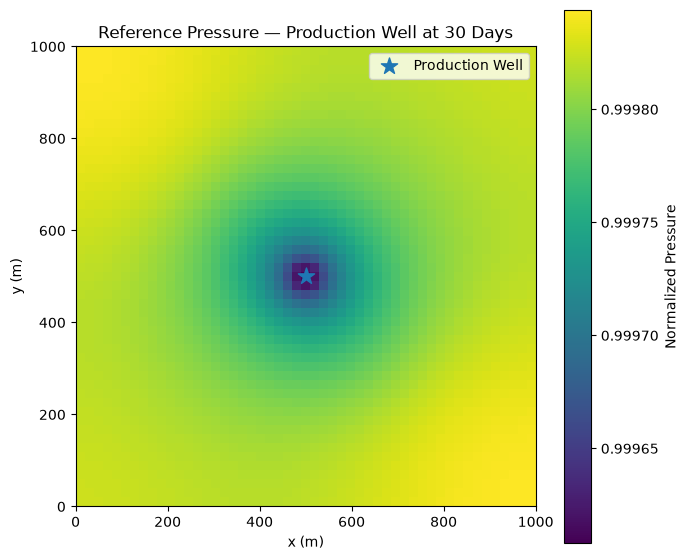

In [104]:
# Plot validated production-well reference at 30 days

plt.figure(figsize=(7, 6))

plt.imshow(
    pressure_well_conservative[-1].T,
    origin="lower",
    extent=[
        x_physical[0],
        x_physical[-1],
        y_physical[0],
        y_physical[-1]
    ],
    aspect="equal"
)

plt.colorbar(label="Normalized Pressure")
plt.scatter(
    well_x_actual,
    well_y_actual,
    marker="*",
    s=150,
    label="Production Well"
)

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Reference Pressure — Production Well at 30 Days")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../results/reference_well_driven_pressure_t30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [105]:
# Create pressure-drawdown reference solution

initial_pressure = 1.0

drawdown_reference = (
    initial_pressure - pressure_well_conservative
)

print("Drawdown reference created.")
print("--------------------------------")

print("Initial drawdown:")
print("  Min:", drawdown_reference[0].min())
print("  Max:", drawdown_reference[0].max())

print("\nFinal drawdown:")
print("  Min:", drawdown_reference[-1].min())
print("  Max:", drawdown_reference[-1].max())

well_drawdown = drawdown_reference[-1, well_i, well_j]

print("\n30-day well drawdown:")
print("  ", well_drawdown)

Drawdown reference created.
--------------------------------
Initial drawdown:
  Min: 0.0
  Max: 0.0

Final drawdown:
  Min: 0.00015601864304470858
  Max: 0.0003918563466059899

30-day well drawdown:
   0.0003918563466059899


In [106]:
# Drawdown source for the production-well PINN

drawdown_source_strength = -well_source_strength

def drawdown_source_function(X):
    x = X[:, 0:1]
    y = X[:, 1:2]

    distance = tf.sqrt(
        (x - well_x_actual / Lx)**2
        + (y - well_y_actual / Ly)**2
    )

    inside_well = tf.cast(
        distance <= well_radius_star,
        tf.float32
    )

    source_per_cell = (
        drawdown_source_strength /
        well_mask.sum()
    )

    return source_per_cell * inside_well


# Verify source sign and magnitude
source_test = drawdown_source_function(
    X_physics_tf[:10]
).numpy()

print("Drawdown source defined.")
print("------------------------")
print("Total drawdown source:",
      drawdown_source_strength)
print("Source per well cell:",
      drawdown_source_strength / well_mask.sum())
print("Source is positive:",
      drawdown_source_strength > 0)
print("Sample source values:", source_test[:10].flatten())

Drawdown source defined.
------------------------
Total drawdown source: 0.5
Source per well cell: 0.05555555555555555
Source is positive: True
Sample source values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [107]:
# Drawdown PINN residual

def drawdown_pinn_residual(model, X):
    
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(X)

        with tf.GradientTape() as tape1:
            tape1.watch(X)

            drawdown = model(X)

        drawdown_grad = tape1.gradient(drawdown, X)

        s_x = drawdown_grad[:, 0:1]
        s_y = drawdown_grad[:, 1:2]
        s_t = drawdown_grad[:, 2:3]

        x = X[:, 0:1]
        y = X[:, 1:2]

        # Heterogeneous relative permeability
        kr = (
            1.0
            + 0.5
            * tf.sin(2.0 * np.pi * x)
            * tf.sin(2.0 * np.pi * y)
        )

        kr_sx = kr * s_x
        kr_sy = kr * s_y

    d_kr_sx_dx = tape2.gradient(
        kr_sx, X
    )[:, 0:1]

    d_kr_sy_dy = tape2.gradient(
        kr_sy, X
    )[:, 1:2]

    source = drawdown_source_function(X)

    residual = (
        s_t
        - alpha_star * (
            d_kr_sx_dx
            + d_kr_sy_dy
        )
        - source
    )

    del tape2

    return residual


print("Drawdown PINN residual function defined.")

Drawdown PINN residual function defined.


In [108]:
# Test the drawdown PINN residual

test_model_drawdown = build_well_pinn()

X_test_drawdown = tf.convert_to_tensor(
    X_physics_tf[:5],
    dtype=tf.float32
)

residual_test = drawdown_pinn_residual(
    test_model_drawdown,
    X_test_drawdown
)

print("Drawdown residual test")
print("----------------------")
print("Residual shape:", residual_test.shape)
print("Residual values:")
print(residual_test.numpy())
print("All values finite:",
      np.all(np.isfinite(residual_test.numpy())))

Drawdown residual test
----------------------
Residual shape: (5, 1)
Residual values:
[[-0.22635585]
 [-0.409575  ]
 [-0.26239493]
 [-0.31376037]
 [-0.41609022]]
All values finite: True


In [109]:
# Drawdown PINN loss function

def drawdown_pinn_losses(model):

    # Physics loss
    residual = drawdown_pinn_residual(
        model,
        X_physics_tf
    )

    physics_loss = tf.reduce_mean(
        tf.square(residual)
    )

    # Initial condition: drawdown = 0
    initial_prediction = model(
        X_initial_tf
    )

    initial_loss = tf.reduce_mean(
        tf.square(initial_prediction)
    )

    # No-flow boundary loss
    boundary_loss = noflow_boundary_loss(
        model
    )

    # Total loss
    total_loss = (
        physics_loss
        + initial_loss
        + boundary_loss
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )


# Test the loss function
test_loss_model = build_well_pinn()

losses_test = drawdown_pinn_losses(
    test_loss_model
)

print("Drawdown PINN loss function defined.")
print("-------------------------------")
print("Total loss:", losses_test[0].numpy())
print("Physics loss:", losses_test[1].numpy())
print("Initial loss:", losses_test[2].numpy())
print("Boundary loss:", losses_test[3].numpy())

print(
    "Loss sum check:",
    (
        losses_test[1]
        + losses_test[2]
        + losses_test[3]
    ).numpy()
)

Drawdown PINN loss function defined.
-------------------------------
Total loss: 0.27817756
Physics loss: 0.05009908
Initial loss: 0.010455958
Boundary loss: 0.21762253
Loss sum check: 0.27817756


In [110]:
# Drawdown PINN training step

optimizer_drawdown = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

@tf.function
def drawdown_train_step(model):

    with tf.GradientTape() as tape:

        (
            total_loss,
            physics_loss,
            initial_loss,
            boundary_loss
        ) = drawdown_pinn_losses(model)

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    optimizer_drawdown.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )


print("Drawdown PINN training step defined.")

Drawdown PINN training step defined.


In [111]:
# Test one drawdown PINN training step

model_drawdown_test = build_well_pinn()

before = drawdown_pinn_losses(model_drawdown_test)

step_losses = drawdown_train_step(
    model_drawdown_test
)

after = drawdown_pinn_losses(model_drawdown_test)

print("One-step training test")
print("----------------------")

print("Loss before:", before[0].numpy())
print("Loss returned by training step:", step_losses[0].numpy())
print("Loss after:", after[0].numpy())

print("\nPhysics loss after:", after[1].numpy())
print("Initial loss after:", after[2].numpy())
print("Boundary loss after:", after[3].numpy())

One-step training test
----------------------
Loss before: 0.505267
Loss returned by training step: 0.505267
Loss after: 0.20884472

Physics loss after: 0.18692508
Initial loss after: 0.0011491589
Boundary loss after: 0.020770477


In [118]:
# Fresh optimizer and training function for the final drawdown PINN

optimizer_drawdown_final = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

@tf.function
def drawdown_train_step_final(model):

    with tf.GradientTape() as tape:

        (
            total_loss,
            physics_loss,
            initial_loss,
            boundary_loss
        ) = drawdown_pinn_losses(model)

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    optimizer_drawdown_final.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )

print("Fresh drawdown training function created.")

Fresh drawdown training function created.


In [119]:
# Train the drawdown PINN

model_drawdown = build_well_pinn()

epochs_drawdown = 5000

history_drawdown = {
    "total_loss": [],
    "physics_loss": [],
    "initial_loss": [],
    "boundary_loss": []
}

for epoch in range(epochs_drawdown):

    (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    ) = drawdown_train_step_final(model_drawdown)

    history_drawdown["total_loss"].append(
        total_loss.numpy()
    )

    history_drawdown["physics_loss"].append(
        physics_loss.numpy()
    )

    history_drawdown["initial_loss"].append(
        initial_loss.numpy()
    )

    history_drawdown["boundary_loss"].append(
        boundary_loss.numpy()
    )

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total: {total_loss.numpy():.6f} | "
            f"Physics: {physics_loss.numpy():.6f} | "
            f"Initial: {initial_loss.numpy():.6f} | "
            f"Boundary: {boundary_loss.numpy():.6f}"
        )

print("\nDrawdown PINN training complete.")

Epoch    0 | Total: 0.774102 | Physics: 0.138833 | Initial: 0.087098 | Boundary: 0.548172
Epoch  500 | Total: 0.000438 | Physics: 0.000433 | Initial: 0.000000 | Boundary: 0.000005
Epoch 1000 | Total: 0.000418 | Physics: 0.000414 | Initial: 0.000000 | Boundary: 0.000004
Epoch 1500 | Total: 0.000402 | Physics: 0.000397 | Initial: 0.000000 | Boundary: 0.000005
Epoch 2000 | Total: 0.000385 | Physics: 0.000378 | Initial: 0.000000 | Boundary: 0.000007
Epoch 2500 | Total: 0.000366 | Physics: 0.000357 | Initial: 0.000000 | Boundary: 0.000009
Epoch 3000 | Total: 0.000334 | Physics: 0.000326 | Initial: 0.000000 | Boundary: 0.000008
Epoch 3500 | Total: 0.000278 | Physics: 0.000271 | Initial: 0.000001 | Boundary: 0.000007
Epoch 4000 | Total: 0.000271 | Physics: 0.000263 | Initial: 0.000001 | Boundary: 0.000006
Epoch 4500 | Total: 0.000266 | Physics: 0.000258 | Initial: 0.000001 | Boundary: 0.000006

Drawdown PINN training complete.


In [120]:
# Evaluate the trained drawdown PINN at 30 days

X_final_drawdown = np.column_stack([
    (X_perm / Lx).ravel(),
    (Y_perm / Ly).ravel(),
    np.full(X_perm.size, 1.0)
])

X_final_drawdown_tf = tf.convert_to_tensor(
    X_final_drawdown,
    dtype=tf.float32
)

# PINN prediction
drawdown_pinn = (
    model_drawdown(X_final_drawdown_tf)
    .numpy()
    .reshape(X_perm.shape)
)

# Reference drawdown
drawdown_ref_final = drawdown_reference[-1]

# Error
drawdown_error = np.abs(
    drawdown_pinn - drawdown_ref_final
)

mae_drawdown = np.mean(drawdown_error)
rmse_drawdown = np.sqrt(
    np.mean(
        (drawdown_pinn - drawdown_ref_final) ** 2
    )
)
max_error_drawdown = np.max(drawdown_error)

# Well values
well_drawdown_ref = drawdown_ref_final[
    well_i, well_j
]

well_drawdown_pinn = drawdown_pinn[
    well_i, well_j
]

print("Drawdown PINN — 30-day evaluation")
print("----------------------------------")

print("Reference drawdown:")
print("  Min:", drawdown_ref_final.min())
print("  Max:", drawdown_ref_final.max())

print("\nPINN drawdown:")
print("  Min:", drawdown_pinn.min())
print("  Max:", drawdown_pinn.max())

print("\nAbsolute error:")
print("  MAE:", mae_drawdown)
print("  RMSE:", rmse_drawdown)
print("  Max error:", max_error_drawdown)

print("\nProduction-well drawdown:")
print("  Reference:", well_drawdown_ref)
print("  PINN:", well_drawdown_pinn)

Drawdown PINN — 30-day evaluation
----------------------------------
Reference drawdown:
  Min: 0.00015601864304470858
  Max: 0.0003918563466059899

PINN drawdown:
  Min: 0.0036369157
  Max: 0.0075746034

Absolute error:
  MAE: 0.006078366285081079
  RMSE: 0.006137606053268554
  Max error: 0.007259097239483925

Production-well drawdown:
  Reference: 0.0003918563466059899
  PINN: 0.0075735827


In [121]:
# Compare the discrete reference source with the
# continuous PINN source representation

well_radius_star = well_radius / Lx

well_area_star = np.pi * well_radius_star**2

pinn_source_density = (
    drawdown_source_strength / well_area_star
)

reference_source_per_cell = (
    drawdown_source_strength / well_mask.sum()
)

print("Source consistency check")
print("------------------------")
print("Well radius (normalized):", well_radius_star)
print("Well area (normalized):", well_area_star)

print("\nReference source:")
print("  Total source:", drawdown_source_strength)
print("  Source per grid cell:", reference_source_per_cell)

print("\nContinuous PINN source:")
print("  Source density:", pinn_source_density)

print("\nRatio of PINN source density to")
print("reference source per grid cell:",
      pinn_source_density / reference_source_per_cell)

Source consistency check
------------------------
Well radius (normalized): 0.03
Well area (normalized): 0.0028274333882308137

Reference source:
  Total source: 0.5
  Source per grid cell: 0.05555555555555555

Continuous PINN source:
  Source density: 176.8388256576615

Ratio of PINN source density to
reference source per grid cell: 3183.098861837907


In [122]:
# Smooth, normalized production-well source

drawdown_source_strength = -well_source_strength

well_x_star = well_x_actual / Lx
well_y_star = well_y_actual / Ly

sigma_well = 0.01

source_amplitude = (
    drawdown_source_strength
    / (2.0 * np.pi * sigma_well**2)
)

def smooth_drawdown_source(X):

    x = X[:, 0:1]
    y = X[:, 1:2]

    r_squared = (
        (x - well_x_star)**2
        + (y - well_y_star)**2
    )

    source = (
        source_amplitude
        * tf.exp(
            -r_squared /
            (2.0 * sigma_well**2)
        )
    )

    return source


print("Smooth drawdown source defined.")
print("--------------------------------")
print("Total source strength:", drawdown_source_strength)
print("Well center:", well_x_star, well_y_star)
print("Sigma:", sigma_well)
print("Source amplitude:", source_amplitude)

Smooth drawdown source defined.
--------------------------------
Total source strength: 0.5
Well center: 0.5 0.5
Sigma: 0.01
Source amplitude: 795.7747154594767


In [123]:
# Evaluate the smooth Gaussian source on the reference grid

r_squared_grid = (
    (X_perm / Lx - well_x_star)**2
    + (Y_perm / Ly - well_y_star)**2
)

gaussian_source_grid = (
    source_amplitude
    * np.exp(
        -r_squared_grid /
        (2.0 * sigma_well**2)
    )
)

# Normalize the discrete grid source so that
# its total exactly equals 0.5

gaussian_source_grid *= (
    drawdown_source_strength /
    gaussian_source_grid.sum()
)

print("Gaussian grid source")
print("--------------------")
print("Grid source sum:", gaussian_source_grid.sum())
print("Expected total:", drawdown_source_strength)
print("Maximum source:", gaussian_source_grid.max())
print("Minimum source:", gaussian_source_grid.min())

Gaussian grid source
--------------------
Grid source sum: 0.49999999999999994
Expected total: 0.5
Maximum source: 0.30934673858823536
Minimum source: 0.0


In [124]:
# Conservative finite-volume reference using the
# same normalized Gaussian production source

pressure_gaussian_reference = np.zeros_like(
    pressure_well_uniform
)

pressure_gaussian_reference[0] = 1.0

for n in range(len(time_heterogeneous) - 1):

    p = pressure_gaussian_reference[n]

    # Face-centered relative permeability
    kr_x_face = 0.5 * (
        kr_field[:-1, :] + kr_field[1:, :]
    )

    kr_y_face = 0.5 * (
        kr_field[:, :-1] + kr_field[:, 1:]
    )

    # Internal face fluxes
    flux_x = (
        kr_x_face *
        (p[1:, :] - p[:-1, :]) /
        dx_star
    )

    flux_y = (
        kr_y_face *
        (p[:, 1:] - p[:, :-1]) /
        dy_star
    )

    # Net flux divergence
    div = np.zeros_like(p)

    # x-direction
    div[0, :] += flux_x[0, :] / dx_star

    div[1:-1, :] += (
        flux_x[1:, :] - flux_x[:-1, :]
    ) / dx_star

    div[-1, :] += -flux_x[-1, :] / dx_star

    # y-direction
    div[:, 0] += flux_y[:, 0] / dy_star

    div[:, 1:-1] += (
        flux_y[:, 1:] - flux_y[:, :-1]
    ) / dy_star

    div[:, -1] += -flux_y[:, -1] / dy_star

    # Diffusion update
    p_new = (
        p +
        dt_star * alpha_star * div
    )

    # Apply the same normalized Gaussian production source
    p_new -= (
        dt_star *
        gaussian_source_grid
    )

    pressure_gaussian_reference[n + 1] = p_new

print("Gaussian-source reference solver complete.")
print("Shape:", pressure_gaussian_reference.shape)

print(
    "Final pressure range:",
    pressure_gaussian_reference[-1].min(),
    pressure_gaussian_reference[-1].max()
)

Gaussian-source reference solver complete.
Shape: (8641, 51, 51)
Final pressure range: 0.9995359283913146 0.9998440222419708


In [125]:
# Verify mass conservation of Gaussian-source reference

initial_total_gaussian = np.sum(
    pressure_gaussian_reference[0]
)

final_total_gaussian = np.sum(
    pressure_gaussian_reference[-1]
)

actual_change_gaussian = (
    final_total_gaussian
    - initial_total_gaussian
)

expected_change_gaussian = (
    -drawdown_source_strength
    * dt_star
    * (len(time_heterogeneous) - 1)
)

mass_balance_error_gaussian = (
    actual_change_gaussian
    - expected_change_gaussian
)

print("Gaussian-source reference mass balance")
print("---------------------------------------")
print("Initial total pressure:",
      initial_total_gaussian)

print("Final total pressure:",
      final_total_gaussian)

print("Actual total pressure change:",
      actual_change_gaussian)

print("Expected source contribution:",
      expected_change_gaussian)

print("Mass-balance error:",
      mass_balance_error_gaussian)

print(
    "Relative mass-balance error (%):",
    abs(
        mass_balance_error_gaussian /
        expected_change_gaussian
    ) * 100
)

Gaussian-source reference mass balance
---------------------------------------
Initial total pressure: 2601.0
Final total pressure: 2600.4999999999895
Actual total pressure change: -0.5000000000104592
Expected source contribution: -0.5
Mass-balance error: -1.0459189070388675e-11
Relative mass-balance error (%): 2.091837814077735e-09


In [126]:
# Save the validated Gaussian-source reference dataset

np.savez(
    "../data/reference_well_driven_reservoir.npz",
    x=x_physical,
    y=y_physical,
    time=time_heterogeneous,
    pressure=pressure_gaussian_reference,
    permeability_mD=k_field_mD,
    permeability_m2=k_field_m2,
    phi=phi,
    mu=mu,
    ct=ct,
    dt=dt_physical,
    well_x=well_x_actual,
    well_y=well_y_actual,
    well_radius=well_radius,
    well_source_strength=well_source_strength,
    source_type="normalized_gaussian"
)

print("Final validated well-driven reference saved.")
print("Source type: normalized Gaussian")
print("File: ../data/reference_well_driven_reservoir.npz")

Final validated well-driven reference saved.
Source type: normalized Gaussian
File: ../data/reference_well_driven_reservoir.npz


In [127]:
# Update the drawdown PINN residual to use
# the same smooth Gaussian source as the reference

def drawdown_pinn_residual(model, X):

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(X)

        with tf.GradientTape() as tape1:
            tape1.watch(X)

            drawdown = model(X)

        drawdown_grad = tape1.gradient(
            drawdown,
            X
        )

        s_x = drawdown_grad[:, 0:1]
        s_y = drawdown_grad[:, 1:2]
        s_t = drawdown_grad[:, 2:3]

        x = X[:, 0:1]
        y = X[:, 1:2]

        # Heterogeneous relative permeability
        kr = (
            1.0
            + 0.5
            * tf.sin(2.0 * np.pi * x)
            * tf.sin(2.0 * np.pi * y)
        )

        kr_sx = kr * s_x
        kr_sy = kr * s_y

    d_kr_sx_dx = tape2.gradient(
        kr_sx,
        X
    )[:, 0:1]

    d_kr_sy_dy = tape2.gradient(
        kr_sy,
        X
    )[:, 1:2]

    # IMPORTANT:
    # Use the same smooth Gaussian source
    # as the numerical reference.
    source = smooth_drawdown_source(X)

    residual = (
        s_t
        - alpha_star * (
            d_kr_sx_dx
            + d_kr_sy_dy
        )
        - source
    )

    del tape2

    return residual


print("Drawdown PINN residual updated.")
print("Source: normalized Gaussian")

Drawdown PINN residual updated.
Source: normalized Gaussian


In [128]:
# Test the updated drawdown PINN residual
# at the well and away from the well

X_residual_test = np.array([
    [0.50, 0.50, 0.50],  # well center
    [0.51, 0.50, 0.50],  # near well
    [0.55, 0.50, 0.50],  # farther away
    [0.80, 0.80, 0.50]   # far from well
], dtype=np.float32)

X_residual_test_tf = tf.convert_to_tensor(
    X_residual_test,
    dtype=tf.float32
)

test_model_gaussian = build_well_pinn()

source_test_gaussian = smooth_drawdown_source(
    X_residual_test_tf
).numpy()

residual_test_gaussian = drawdown_pinn_residual(
    test_model_gaussian,
    X_residual_test_tf
).numpy()

print("Gaussian-source residual test")
print("-----------------------------")

for i in range(len(X_residual_test)):
    print(
        f"Point {i+1}: "
        f"(x={X_residual_test[i,0]:.2f}, "
        f"y={X_residual_test[i,1]:.2f}, "
        f"t={X_residual_test[i,2]:.2f})"
    )
    print(
        f"  Source: {source_test_gaussian[i,0]:.6f}"
    )
    print(
        f"  Residual: {residual_test_gaussian[i,0]:.6f}"
    )

print("\nAll residual values finite:",
      np.all(np.isfinite(residual_test_gaussian)))

Gaussian-source residual test
-----------------------------
Point 1: (x=0.50, y=0.50, t=0.50)
  Source: 795.774719
  Residual: -795.595581
Point 2: (x=0.51, y=0.50, t=0.50)
  Source: 482.662231
  Residual: -482.480652
Point 3: (x=0.55, y=0.50, t=0.50)
  Source: 0.002966
  Residual: 0.187807
Point 4: (x=0.80, y=0.80, t=0.50)
  Source: 0.000000
  Residual: 0.074430

All residual values finite: True


In [129]:
# Check how well the physics points resolve the Gaussian source

x_points = X_physics_combined[:, 0]
y_points = X_physics_combined[:, 1]

distance_points = np.sqrt(
    (x_points - well_x_star)**2
    + (y_points - well_y_star)**2
)

for radius in [0.005, 0.01, 0.02, 0.03, 0.05]:

    count = np.sum(
        distance_points <= radius
    )

    percentage = (
        count / len(distance_points) * 100
    )

    print(
        f"Within radius {radius:.3f}: "
        f"{count} points ({percentage:.2f}%)"
    )

Within radius 0.005: 46 points (0.38%)
Within radius 0.010: 229 points (1.91%)
Within radius 0.020: 923 points (7.69%)
Within radius 0.030: 2033 points (16.94%)
Within radius 0.050: 2086 points (17.38%)


In [130]:
# Test a better-resolved Gaussian well source

sigma_well_test = 0.02

source_amplitude_test = (
    drawdown_source_strength
    / (2.0 * np.pi * sigma_well_test**2)
)

gaussian_source_test = (
    source_amplitude_test
    * np.exp(
        -r_squared_grid /
        (2.0 * sigma_well_test**2)
    )
)

# Normalize on the discrete grid
gaussian_source_test *= (
    drawdown_source_strength /
    gaussian_source_test.sum()
)

print("Gaussian source resolution test")
print("--------------------------------")
print("Sigma:", sigma_well_test)
print("Grid spacing:", dx_star)
print("Sigma / grid spacing:",
      sigma_well_test / dx_star)

print("Discrete source sum:",
      gaussian_source_test.sum())

print("Maximum source:",
      gaussian_source_test.max())

Gaussian source resolution test
--------------------------------
Sigma: 0.02
Grid spacing: 0.02
Sigma / grid spacing: 1.0
Discrete source sum: 0.5
Maximum source: 0.07957747069437715


In [131]:
# Set the final well-source width

sigma_well = 0.02

source_amplitude = (
    drawdown_source_strength
    / (2.0 * np.pi * sigma_well**2)
)

print("Final Gaussian well source")
print("--------------------------")
print("Sigma:", sigma_well)
print("Grid spacing:", dx_star)
print("Sigma / grid spacing:",
      sigma_well / dx_star)
print("Continuous source amplitude:",
      source_amplitude)

Final Gaussian well source
--------------------------
Sigma: 0.02
Grid spacing: 0.02
Sigma / grid spacing: 1.0
Continuous source amplitude: 198.94367886486918


In [132]:
# Build the final normalized Gaussian source on the reservoir grid

r_squared_grid = (
    (X_perm / Lx - well_x_star)**2
    + (Y_perm / Ly - well_y_star)**2
)

gaussian_source_grid = (
    source_amplitude
    * np.exp(
        -r_squared_grid /
        (2.0 * sigma_well**2)
    )
)

# Normalize so the total discrete source strength is exactly 0.5
gaussian_source_grid *= (
    drawdown_source_strength /
    gaussian_source_grid.sum()
)

print("Final Gaussian source grid")
print("---------------------------")
print("Shape:", gaussian_source_grid.shape)
print("Total source:", gaussian_source_grid.sum())
print("Maximum source:", gaussian_source_grid.max())
print("Minimum source:", gaussian_source_grid.min())

Final Gaussian source grid
---------------------------
Shape: (51, 51)
Total source: 0.5
Maximum source: 0.07957747069437715
Minimum source: 2.929131989157168e-273


In [133]:
# Rebuild the fully conservative well-driven reference
# using the final Gaussian production source

pressure_gaussian_reference = np.zeros_like(pressure_well_uniform)

# Initial pressure
pressure_gaussian_reference[0] = 1.0

for n in range(len(time_heterogeneous) - 1):

    p = pressure_gaussian_reference[n]

    # Face-centered relative permeability
    kr_x_face = 0.5 * (
        kr_field[:-1, :] + kr_field[1:, :]
    )

    kr_y_face = 0.5 * (
        kr_field[:, :-1] + kr_field[:, 1:]
    )

    # Fluxes
    flux_x = kr_x_face * (
        p[1:, :] - p[:-1, :]
    ) / dx_star

    flux_y = kr_y_face * (
        p[:, 1:] - p[:, :-1]
    ) / dy_star

    # Conservative divergence
    div = np.zeros_like(p)

    # x-direction
    div[0, :] += flux_x[0, :] / dx_star
    div[1:-1, :] += (
        flux_x[1:, :] - flux_x[:-1, :]
    ) / dx_star
    div[-1, :] += -flux_x[-1, :] / dx_star

    # y-direction
    div[:, 0] += flux_y[:, 0] / dy_star
    div[:, 1:-1] += (
        flux_y[:, 1:] - flux_y[:, :-1]
    ) / dy_star
    div[:, -1] += -flux_y[:, -1] / dy_star

    # Diffusion + production source
    p_new = (
        p
        + dt_star * alpha_star * div
        - dt_star * gaussian_source_grid
    )

    pressure_gaussian_reference[n + 1] = p_new

print("Final Gaussian well-driven reference")
print("-------------------------------------")
print("Shape:", pressure_gaussian_reference.shape)
print("Final minimum pressure:", pressure_gaussian_reference[-1].min())
print("Final maximum pressure:", pressure_gaussian_reference[-1].max())

Final Gaussian well-driven reference
-------------------------------------
Shape: (8641, 51, 51)
Final minimum pressure: 0.9996095988437607
Final maximum pressure: 0.9998439509931868


In [134]:
# Mass-balance validation for the final Gaussian well-driven reference

initial_total_mass = pressure_gaussian_reference[0].sum()
final_total_mass = pressure_gaussian_reference[-1].sum()

actual_mass_change = final_total_mass - initial_total_mass
expected_mass_change = -drawdown_source_strength

mass_balance_error = actual_mass_change - expected_mass_change
relative_mass_balance_error = (
    abs(mass_balance_error)
    / abs(expected_mass_change)
    * 100
)

print("Mass-balance validation")
print("-----------------------")
print("Initial total pressure:", initial_total_mass)
print("Final total pressure:", final_total_mass)
print("Actual change:", actual_mass_change)
print("Expected change:", expected_mass_change)
print("Mass-balance error:", mass_balance_error)
print(
    "Relative error (%):",
    relative_mass_balance_error
)

Mass-balance validation
-----------------------
Initial total pressure: 2601.0
Final total pressure: 2600.5000000000246
Actual change: -0.49999999997544364
Expected change: -0.5
Mass-balance error: 2.4556356947869062e-11
Relative error (%): 4.9112713895738125e-09


In [135]:
# Final Gaussian production source for the PINN
# This uses the same normalized Gaussian definition as the
# validated finite-volume reference.

cell_area_star = dx_star * dy_star

# Raw Gaussian on the reference grid
gaussian_raw_grid = np.exp(
    -r_squared_grid / (2.0 * sigma_well**2)
)

# Discrete quadrature normalization
source_normalization = (
    gaussian_raw_grid.sum() * cell_area_star
)

# Source density used by the continuous PINN
source_amplitude_pinn = (
    drawdown_source_strength /
    source_normalization
)

print("PINN Gaussian source")
print("--------------------")
print("Sigma:", sigma_well)
print("Cell area:", cell_area_star)
print("Source normalization:", source_normalization)
print("PINN source amplitude:", source_amplitude_pinn)

PINN Gaussian source
--------------------
Sigma: 0.02
Cell area: 0.0004
Source normalization: 0.0025132741497667604
PINN source amplitude: 198.94367673594286


In [136]:
# Final smooth Gaussian production source used by the PINN

def smooth_drawdown_source(X):
    x = X[:, 0:1]
    y = X[:, 1:2]

    r_squared = (
        (x - well_x_star)**2
        + (y - well_y_star)**2
    )

    source = (
        source_amplitude_pinn
        * tf.exp(
            -r_squared /
            (2.0 * sigma_well**2)
        )
    )

    return source

In [137]:
# Diagnostic: inspect the final Gaussian source at key locations

test_points = np.array([
    [0.50, 0.50, 0.50],  # exactly at the well
    [0.52, 0.50, 0.50],  # one grid spacing away
    [0.54, 0.50, 0.50],  # two grid spacings away
    [0.80, 0.80, 0.50],  # far from the well
], dtype=np.float32)

test_source = smooth_drawdown_source(
    tf.constant(test_points)
).numpy().flatten()

print("Final PINN source diagnostic")
print("----------------------------")

for point, source_value in zip(test_points, test_source):
    print(
        f"x={point[0]:.2f}, "
        f"y={point[1]:.2f}, "
        f"t={point[2]:.2f}  "
        f"-> source={source_value:.6f}"
    )

Final PINN source diagnostic
----------------------------
x=0.50, y=0.50, t=0.50  -> source=198.943680
x=0.52, y=0.50, t=0.50  -> source=120.665558
x=0.54, y=0.50, t=0.50  -> source=26.924042
x=0.80, y=0.80, t=0.50  -> source=0.000000


In [138]:
# Final physics-collocation diagnostic

print("Final PINN physics sampling")
print("---------------------------")
print("Total physics points:", X_physics_combined.shape[0])
print("Random points:", X_physics.shape[0])
print("Dedicated well points:", X_well_physics.shape[0])

well_distance_physics = np.sqrt(
    (X_physics_combined[:, 0] - well_x_star)**2
    + (X_physics_combined[:, 1] - well_y_star)**2
)

for radius in [0.01, 0.02, 0.04, 0.06]:
    count = np.sum(well_distance_physics <= radius)
    percentage = 100 * count / len(well_distance_physics)

    print(
        f"Within radius {radius:.2f}: "
        f"{count} points ({percentage:.2f}%)"
    )

Final PINN physics sampling
---------------------------
Total physics points: 12000
Random points: 10000
Dedicated well points: 2000
Within radius 0.01: 229 points (1.91%)
Within radius 0.02: 923 points (7.69%)
Within radius 0.04: 2055 points (17.12%)
Within radius 0.06: 2112 points (17.60%)


In [139]:
# Create the final well-driven drawdown PINN

model_drawdown_final = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    
    tf.keras.layers.Dense(
        50,
        activation="tanh"
    ),
    
    tf.keras.layers.Dense(
        50,
        activation="tanh"
    ),
    
    tf.keras.layers.Dense(
        50,
        activation="tanh"
    ),
    
    tf.keras.layers.Dense(
        50,
        activation="tanh"
    ),
    
    tf.keras.layers.Dense(1)
])

model_drawdown_final.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_70 (Dense)                │ (None, 50)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,901 (30.86 KB)

 Trainable params: 7,901 (30.86 KB)

 Non-trainable params: 0 (0.00 B)

In [140]:
# Final loss function for the well-driven drawdown PINN

def drawdown_pinn_losses_final(model):

    # Physics loss
    residual = drawdown_pinn_residual(
        model,
        X_physics_combined_tf
    )

    physics_loss = tf.reduce_mean(
        tf.square(residual)
    )

    # Initial condition: s(x,y,0) = 0
    initial_prediction = model(
        X_initial_tf
    )

    initial_loss = tf.reduce_mean(
        tf.square(initial_prediction)
    )

    # No-flow boundaries
    boundary_loss = noflow_boundary_loss(
        model
    )

    # Total loss
    total_loss = (
        physics_loss
        + initial_loss
        + boundary_loss
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )

print("Final PINN loss function defined.")

Final PINN loss function defined.


In [141]:
# Final optimizer for the well-driven PINN

optimizer_well_final = tf.keras.optimizers.Adam(
    learning_rate=0.001
)


@tf.function
def well_pinn_train_step(model):

    with tf.GradientTape() as tape:

        (
            total_loss,
            physics_loss,
            initial_loss,
            boundary_loss
        ) = drawdown_pinn_losses_final(model)

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    optimizer_well_final.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )


print("Final optimizer and training step defined.")

Final optimizer and training step defined.


In [143]:
# Convert final collocation points to TensorFlow tensors

X_physics_combined_tf = tf.constant(
    X_physics_combined,
    dtype=tf.float32
)

X_initial_tf = tf.constant(
    X_initial,
    dtype=tf.float32
)

print("TensorFlow training tensors ready")
print("--------------------------------")
print("Physics points:", X_physics_combined_tf.shape)
print("Initial points:", X_initial_tf.shape)

TensorFlow training tensors ready
--------------------------------
Physics points: (12000, 3)
Initial points: (1000, 3)


In [145]:
# Explicitly build the final model before using it inside tf.function

_ = model_drawdown_final(
    tf.zeros((1, 3), dtype=tf.float32)
)

print("Model explicitly built.")
print("Trainable parameters:",
      model_drawdown_final.count_params())

Model explicitly built.
Trainable parameters: 7901


In [147]:
# Fresh training step created after the model has been built

optimizer_well_final = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

@tf.function
def well_pinn_train_step_final(model):

    with tf.GradientTape() as tape:

        (
            total_loss,
            physics_loss,
            initial_loss,
            boundary_loss
        ) = drawdown_pinn_losses_final(model)

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    optimizer_well_final.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    )

print("Final training step created.")

Final training step created.


In [148]:
# Test one final training step

(
    total_loss,
    physics_loss,
    initial_loss,
    boundary_loss
) = well_pinn_train_step_final(
    model_drawdown_final
)

print("Final single-step test")
print("----------------------")
print("Total loss:", float(total_loss))
print("Physics loss:", float(physics_loss))
print("Initial loss:", float(initial_loss))
print("Boundary loss:", float(boundary_loss))

Final single-step test
----------------------
Total loss: 2687.675048828125
Physics loss: 2687.63623046875
Initial loss: 0.009034624323248863
Boundary loss: 0.029821153730154037


In [149]:
# Final training of the well-driven reservoir PINN

epochs = 5000

history_well = {
    "total_loss": [],
    "physics_loss": [],
    "initial_loss": [],
    "boundary_loss": []
}

for epoch in range(epochs):

    (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss
    ) = well_pinn_train_step_final(
        model_drawdown_final
    )

    history_well["total_loss"].append(
        float(total_loss)
    )
    history_well["physics_loss"].append(
        float(physics_loss)
    )
    history_well["initial_loss"].append(
        float(initial_loss)
    )
    history_well["boundary_loss"].append(
        float(boundary_loss)
    )

    if epoch % 500 == 0 or epoch == epochs - 1:

        print(
            f"Epoch {epoch:4d} | "
            f"Total: {float(total_loss):.6f} | "
            f"Physics: {float(physics_loss):.6f} | "
            f"Initial: {float(initial_loss):.6f} | "
            f"Boundary: {float(boundary_loss):.6f}"
        )

Epoch    0 | Total: 2680.955566 | Physics: 2680.929443 | Initial: 0.003180 | Boundary: 0.022854
Epoch  500 | Total: 4.246674 | Physics: 4.161617 | Initial: 0.012436 | Boundary: 0.072621
Epoch 1000 | Total: 1.146295 | Physics: 1.068469 | Initial: 0.010676 | Boundary: 0.067151
Epoch 1500 | Total: 1.125888 | Physics: 1.068837 | Initial: 0.004483 | Boundary: 0.052568
Epoch 2000 | Total: 0.551322 | Physics: 0.497454 | Initial: 0.003996 | Boundary: 0.049871
Epoch 2500 | Total: 0.419938 | Physics: 0.366353 | Initial: 0.004000 | Boundary: 0.049585
Epoch 3000 | Total: 1.481230 | Physics: 1.428512 | Initial: 0.003990 | Boundary: 0.048728
Epoch 3500 | Total: 0.494115 | Physics: 0.442410 | Initial: 0.003900 | Boundary: 0.047805
Epoch 4000 | Total: 1.419157 | Physics: 1.369115 | Initial: 0.003796 | Boundary: 0.046246
Epoch 4500 | Total: 0.477762 | Physics: 0.430294 | Initial: 0.003747 | Boundary: 0.043721
Epoch 4999 | Total: 0.899202 | Physics: 0.855482 | Initial: 0.003614 | Boundary: 0.040107


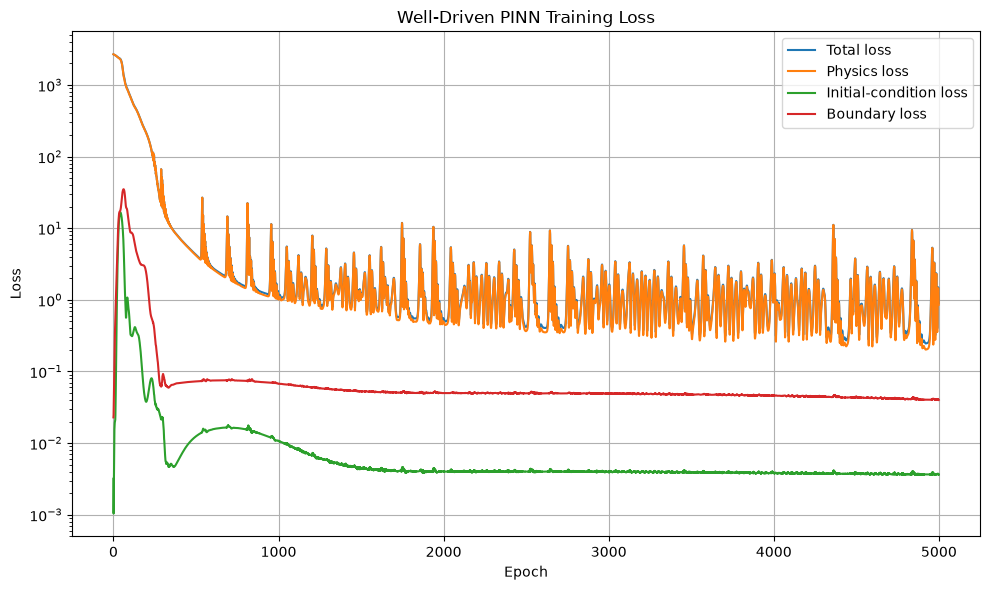

In [150]:
# Plot final well-driven PINN training history

plt.figure(figsize=(10, 6))

plt.semilogy(
    history_well["total_loss"],
    label="Total loss"
)

plt.semilogy(
    history_well["physics_loss"],
    label="Physics loss"
)

plt.semilogy(
    history_well["initial_loss"],
    label="Initial-condition loss"
)

plt.semilogy(
    history_well["boundary_loss"],
    label="Boundary loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Well-Driven PINN Training Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../results/well_driven_pinn_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [151]:
# Identify the best epochs from the completed training run

total_losses = np.array(history_well["total_loss"])
physics_losses = np.array(history_well["physics_loss"])

best_total_epoch = np.argmin(total_losses)
best_physics_epoch = np.argmin(physics_losses)

print("Best training points")
print("--------------------")
print(
    "Lowest total loss:",
    total_losses[best_total_epoch]
)
print(
    "Epoch:",
    best_total_epoch
)

print()

print(
    "Lowest physics loss:",
    physics_losses[best_physics_epoch]
)
print(
    "Epoch:",
    best_physics_epoch
)

Best training points
--------------------
Lowest total loss: 0.24596919119358063
Epoch: 4920

Lowest physics loss: 0.201947882771492
Epoch: 4920


In [152]:
# Evaluate the trained well-driven PINN against the validated reference

drawdown_reference = 1.0 - pressure_gaussian_reference

# Build full spatial grid in normalized coordinates
X_eval_grid, Y_eval_grid = np.meshgrid(
    x_physical / Lx,
    y_physical / Ly,
    indexing="ij"
)

X_eval_space = np.column_stack([
    X_eval_grid.ravel(),
    Y_eval_grid.ravel()
])

# Evaluate at 15 days and 30 days
evaluation_results = []

for day in [15, 30]:

    time_seconds = day * 24 * 3600
    time_star = time_seconds / T

    X_eval = np.column_stack([
        X_eval_space,
        np.full(
            len(X_eval_space),
            time_star
        )
    ]).astype(np.float32)

    drawdown_prediction = (
        model_drawdown_final(
            tf.constant(X_eval)
        )
        .numpy()
        .flatten()
    )

    # Reference time index
    time_index = np.argmin(
        np.abs(time_heterogeneous - time_seconds)
    )

    drawdown_ref = (
        drawdown_reference[time_index]
        .ravel()
    )

    error = drawdown_prediction - drawdown_ref

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))
    max_error = np.max(np.abs(error))

    well_index = (
        well_i * len(y_physical) + well_j
    )

    evaluation_results.append([
        day,
        mae,
        rmse,
        max_error,
        drawdown_ref.max(),
        drawdown_prediction.max(),
        drawdown_ref[well_index],
        drawdown_prediction[well_index]
    ])

    print(f"\n{day}-day evaluation")
    print("------------------")
    print("Reference max drawdown:", drawdown_ref.max())
    print("PINN max drawdown:", drawdown_prediction.max())
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("Maximum absolute error:", max_error)
    print("Reference well drawdown:", drawdown_ref[well_index])
    print("PINN well drawdown:", drawdown_prediction[well_index])

evaluation_results = np.array(
    evaluation_results
)

print("\nEvaluation complete.")


15-day evaluation
------------------
Reference max drawdown: 0.0002941569934520327
PINN max drawdown: 0.5901705
MAE: 0.10964649403631956
RMSE: 0.13184238924900293
Maximum absolute error: 0.5898763456692067
Reference well drawdown: 0.0002941569934520327
PINN well drawdown: 0.5901705

30-day evaluation
------------------
Reference max drawdown: 0.00039040115623933946
PINN max drawdown: 0.72530794
MAE: 0.22071404748814544
RMSE: 0.23631761996224385
Maximum absolute error: 0.7249175402805282
Reference well drawdown: 0.00039040115623933946
PINN well drawdown: 0.72530794

Evaluation complete.


In [154]:
# Correct continuous source density for the finite-volume reference
# The source must integrate to a total production strength of 0.5.

cell_area_star = dx_star * dy_star

gaussian_raw_grid = np.exp(
    -r_squared_grid /
    (2.0 * sigma_well**2)
)

# Normalize the source density using numerical quadrature
source_normalization = (
    gaussian_raw_grid.sum() *
    cell_area_star
)

source_amplitude_reference = (
    drawdown_source_strength /
    source_normalization
)

gaussian_source_density_grid = (
    source_amplitude_reference *
    gaussian_raw_grid
)

total_integrated_source = (
    gaussian_source_density_grid.sum() *
    cell_area_star
)

print("Corrected Gaussian source density")
print("---------------------------------")
print("Source amplitude:", source_amplitude_reference)
print("Maximum source density:",
      gaussian_source_density_grid.max())
print("Cell area:", cell_area_star)
print("Integrated total source:",
      total_integrated_source)

Corrected Gaussian source density
---------------------------------
Source amplitude: 198.94367673594286
Maximum source density: 198.94367673594286
Cell area: 0.0004
Integrated total source: 0.5


In [155]:
# Rebuild the well-driven reference using the
# density-consistent Gaussian production source

pressure_gaussian_reference = np.zeros_like(
    pressure_well_uniform
)

# Initial pressure
pressure_gaussian_reference[0] = 1.0

for n in range(len(time_heterogeneous) - 1):

    p = pressure_gaussian_reference[n]

    # Face-centered relative permeability
    kr_x_face = 0.5 * (
        kr_field[:-1, :] + kr_field[1:, :]
    )

    kr_y_face = 0.5 * (
        kr_field[:, :-1] + kr_field[:, 1:]
    )

    # Fluxes
    flux_x = kr_x_face * (
        p[1:, :] - p[:-1, :]
    ) / dx_star

    flux_y = kr_y_face * (
        p[:, 1:] - p[:, :-1]
    ) / dy_star

    # Conservative divergence
    div = np.zeros_like(p)

    # x-direction
    div[0, :] += flux_x[0, :] / dx_star
    div[1:-1, :] += (
        flux_x[1:, :] - flux_x[:-1, :]
    ) / dx_star
    div[-1, :] += -flux_x[-1, :] / dx_star

    # y-direction
    div[:, 0] += flux_y[:, 0] / dy_star
    div[:, 1:-1] += (
        flux_y[:, 1:] - flux_y[:, :-1]
    ) / dy_star
    div[:, -1] += -flux_y[:, -1] / dy_star

    # Diffusion + continuous production source density
    p_new = (
        p
        + dt_star * alpha_star * div
        - dt_star * gaussian_source_density_grid
    )

    pressure_gaussian_reference[n + 1] = p_new

print("Density-consistent well-driven reference")
print("-----------------------------------------")
print("Shape:", pressure_gaussian_reference.shape)
print(
    "Final minimum pressure:",
    pressure_gaussian_reference[-1].min()
)
print(
    "Final maximum pressure:",
    pressure_gaussian_reference[-1].max()
)

Density-consistent well-driven reference
-----------------------------------------
Shape: (8641, 51, 51)
Final minimum pressure: 0.02399710936975698
Final maximum pressure: 0.6098774829470183


In [157]:
# Correct integrated mass-balance validation
# for the density-consistent reference

cell_area_star = dx_star * dy_star

initial_mass = (
    pressure_gaussian_reference[0].sum()
    * cell_area_star
)

final_mass = (
    pressure_gaussian_reference[-1].sum()
    * cell_area_star
)

actual_mass_change = final_mass - initial_mass

expected_mass_change = -drawdown_source_strength * T / T
# Since the source is already defined in normalized-time units:
# expected total change = -0.5

mass_balance_error = (
    actual_mass_change - expected_mass_change
)

relative_mass_balance_error = (
    abs(mass_balance_error)
    / abs(expected_mass_change)
    * 100
)

print("Corrected mass-balance validation")
print("----------------------------------")
print("Initial integrated mass:", initial_mass)
print("Final integrated mass:", final_mass)
print("Actual mass change:", actual_mass_change)
print("Expected mass change:", expected_mass_change)
print("Mass-balance error:", mass_balance_error)
print(
    "Relative error (%):",
    relative_mass_balance_error
)

Corrected mass-balance validation
----------------------------------
Initial integrated mass: 1.0404
Final integrated mass: 0.5403999999999947
Actual mass change: -0.5000000000000053
Expected mass change: -0.5
Mass-balance error: -5.329070518200751e-15
Relative error (%): 1.0658141036401503e-12


In [158]:
# Save the corrected, density-consistent well-driven reference

np.savez(
    "../data/reference_well_driven_reservoir.npz",
    x=x_physical,
    y=y_physical,
    time=time_heterogeneous,
    pressure=pressure_gaussian_reference,
    permeability_mD=k_field_mD,
    permeability_m2=k_field_m2,
    phi=phi,
    mu=mu,
    ct=ct,
    dt=dt_physical,
    well_x=well_x_actual,
    well_y=well_y_actual,
    well_radius=well_radius,
    well_source_strength=well_source_strength,
    source_type="normalized_gaussian_density",
    sigma_well=sigma_well,
    source_amplitude=source_amplitude_reference
)

print("Corrected reference dataset saved.")

Corrected reference dataset saved.


In [159]:
# Re-evaluate the trained well-driven PINN
# against the corrected reference

drawdown_reference = (
    1.0 - pressure_gaussian_reference
)

evaluation_results = []

for day in [15, 30]:

    time_seconds = day * 24 * 3600
    time_star = time_seconds / T

    X_eval = np.column_stack([
        X_eval_space,
        np.full(
            len(X_eval_space),
            time_star
        )
    ]).astype(np.float32)

    # PINN prediction
    drawdown_prediction = (
        model_drawdown_final(
            tf.constant(X_eval)
        )
        .numpy()
        .flatten()
    )

    # Corresponding reference time
    time_index = np.argmin(
        np.abs(
            time_heterogeneous -
            time_seconds
        )
    )

    drawdown_ref = (
        drawdown_reference[time_index]
        .ravel()
    )

    error = (
        drawdown_prediction -
        drawdown_ref
    )

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))
    max_error = np.max(np.abs(error))

    well_index = (
        well_i * len(y_physical)
        + well_j
    )

    evaluation_results.append([
        day,
        mae,
        rmse,
        max_error,
        drawdown_ref.max(),
        drawdown_prediction.max(),
        drawdown_ref[well_index],
        drawdown_prediction[well_index]
    ])

    print(f"\n{day}-day evaluation")
    print("------------------")
    print(
        "Reference max drawdown:",
        drawdown_ref.max()
    )
    print(
        "PINN max drawdown:",
        drawdown_prediction.max()
    )
    print("MAE:", mae)
    print("RMSE:", rmse)
    print(
        "Maximum absolute error:",
        max_error
    )
    print(
        "Reference well drawdown:",
        drawdown_ref[well_index]
    )
    print(
        "PINN well drawdown:",
        drawdown_prediction[well_index]
    )

print("\nEvaluation complete.")


15-day evaluation
------------------
Reference max drawdown: 0.735392483649886
PINN max drawdown: 0.5901705
MAE: 0.13055611763297373
RMSE: 0.13077506581166284
Maximum absolute error: 0.15506492107282877
Reference well drawdown: 0.735392483649886
PINN well drawdown: 0.5901705

30-day evaluation
------------------
Reference max drawdown: 0.976002890630243
PINN max drawdown: 0.72530794
MAE: 0.2596781093746143
RMSE: 0.2600082434626041
Maximum absolute error: 0.31551884025702226
Reference well drawdown: 0.976002890630243
PINN well drawdown: 0.72530794

Evaluation complete.


In [160]:
# 30-day spatial error diagnostic

day = 30

time_seconds = day * 24 * 3600
time_star = time_seconds / T

X_eval = np.column_stack([
    X_eval_space,
    np.full(
        len(X_eval_space),
        time_star
    )
]).astype(np.float32)

drawdown_prediction_30d = (
    model_drawdown_final(
        tf.constant(X_eval)
    )
    .numpy()
    .flatten()
)

time_index_30d = np.argmin(
    np.abs(
        time_heterogeneous -
        time_seconds
    )
)

drawdown_reference_30d = (
    drawdown_reference[time_index_30d]
    .ravel()
)

absolute_error_30d = np.abs(
    drawdown_prediction_30d -
    drawdown_reference_30d
)

print("30-day spatial error diagnostic")
print("--------------------------------")
print("Mean absolute error:",
      absolute_error_30d.mean())
print("Maximum absolute error:",
      absolute_error_30d.max())

for radius in [0.02, 0.04, 0.06, 0.10, 0.20]:

    distance = np.sqrt(
        (X_eval_space[:, 0] - well_x_star)**2
        + (X_eval_space[:, 1] - well_y_star)**2
    )

    mask = distance <= radius

    print(
        f"Within radius {radius:.2f}: "
        f"MAE = {absolute_error_30d[mask].mean():.6f}, "
        f"points = {mask.sum()}"
    )

30-day spatial error diagnostic
--------------------------------
Mean absolute error: 0.2596781093746143
Maximum absolute error: 0.31551884025702226
Within radius 0.02: MAE = 0.250695, points = 1
Within radius 0.04: MAE = 0.243951, points = 11
Within radius 0.06: MAE = 0.241352, points = 27
Within radius 0.10: MAE = 0.240646, points = 79
Within radius 0.20: MAE = 0.241621, points = 317


In [161]:
# Global drawdown / mass-response diagnostic

print("Global drawdown diagnostic")
print("--------------------------")

for day in [15, 30]:

    time_seconds = day * 24 * 3600
    time_star = time_seconds / T

    X_eval = np.column_stack([
        X_eval_space,
        np.full(
            len(X_eval_space),
            time_star
        )
    ]).astype(np.float32)

    pinn_drawdown = (
        model_drawdown_final(
            tf.constant(X_eval)
        )
        .numpy()
        .flatten()
    )

    time_index = np.argmin(
        np.abs(
            time_heterogeneous -
            time_seconds
        )
    )

    reference_drawdown = (
        drawdown_reference[time_index]
        .ravel()
    )

    print(f"\n{day}-day")
    print("------------------")
    print(
        "Reference mean drawdown:",
        reference_drawdown.mean()
    )
    print(
        "PINN mean drawdown:",
        pinn_drawdown.mean()
    )
    print(
        "Reference total integrated drawdown:",
        reference_drawdown.sum() * cell_area_star
    )
    print(
        "PINN total integrated drawdown:",
        pinn_drawdown.sum() * cell_area_star
    )

Global drawdown diagnostic
--------------------------

15-day
------------------
Reference mean drawdown: 0.24029219530949986
PINN mean drawdown: 0.10973607
Reference total integrated drawdown: 0.25000000000000366
PINN total integrated drawdown: 0.1141694091796875

30-day
------------------
Reference mean drawdown: 0.48058439061899794
PINN mean drawdown: 0.22090629
Reference total integrated drawdown: 0.5000000000000054
PINN total integrated drawdown: 0.22983090820312502


In [162]:
# Verify the continuous Gaussian source integral
# used by the PINN

source_grid_pinn = smooth_drawdown_source(
    tf.constant(
        np.column_stack([
            X_eval_space,
            np.zeros(len(X_eval_space))
        ]),
        dtype=tf.float32
    )
).numpy().flatten()

source_integral_pinn = (
    source_grid_pinn.sum()
    * cell_area_star
)

print("PINN source integral diagnostic")
print("-------------------------------")
print("Source amplitude:",
      source_amplitude_pinn)
print("Grid cell area:",
      cell_area_star)
print("Numerical source integral:",
      source_integral_pinn)
print("Expected source strength:",
      drawdown_source_strength)

PINN source integral diagnostic
-------------------------------
Source amplitude: 198.94367673594286
Grid cell area: 0.0004
Numerical source integral: 0.500000048828125
Expected source strength: 0.5


In [163]:
# Diagnose global mass-balance error in the trained PINN
#
# If the PINN exactly satisfies the PDE and no-flow boundaries,
# the integrated drawdown should increase according to the
# integrated production source.

print("PINN global PDE-balance diagnostic")
print("----------------------------------")

for day in [15, 30]:

    time_seconds = day * 24 * 3600
    time_star = time_seconds / T

    # Full spatial grid at this time
    X_balance = np.column_stack([
        X_eval_space,
        np.full(
            len(X_eval_space),
            time_star
        )
    ]).astype(np.float32)

    X_balance_tf = tf.constant(
        X_balance,
        dtype=tf.float32
    )

    # Evaluate PDE residual
    residual = drawdown_pinn_residual(
        model_drawdown_final,
        X_balance_tf
    ).numpy().flatten()

    # Integrated residual over the reservoir
    integrated_residual = (
        residual.sum() * cell_area_star
    )

    # Integrated source
    source_values = (
        smooth_drawdown_source(
            X_balance_tf
        )
        .numpy()
        .flatten()
    )

    integrated_source = (
        source_values.sum() * cell_area_star
    )

    print(f"\n{day}-day")
    print("------------------")
    print(
        "Integrated PDE residual:",
        integrated_residual
    )
    print(
        "Integrated source:",
        integrated_source
    )
    print(
        "Residual / source ratio:",
        integrated_residual / integrated_source
    )

PINN global PDE-balance diagnostic
----------------------------------

15-day
------------------
Integrated PDE residual: -0.122959619140625
Integrated source: 0.500000048828125
Residual / source ratio: -0.24591921426570174

30-day
------------------
Integrated PDE residual: -0.018160739135742187
Integrated source: 0.500000048828125
Residual / source ratio: -0.03632147472446536


In [164]:
# Integrated drawdown evolution diagnostic

diagnostic_days = [1, 5, 10, 15, 20, 25, 30]

print("Integrated drawdown evolution")
print("----------------------------")

for day in diagnostic_days:

    time_seconds = day * 24 * 3600
    time_star = time_seconds / T

    X_eval_time = np.column_stack([
        X_eval_space,
        np.full(
            len(X_eval_space),
            time_star
        )
    ]).astype(np.float32)

    # PINN drawdown
    pinn_drawdown = (
        model_drawdown_final(
            tf.constant(X_eval_time)
        )
        .numpy()
        .flatten()
    )

    # Reference drawdown
    time_index = np.argmin(
        np.abs(
            time_heterogeneous -
            time_seconds
        )
    )

    reference_drawdown = (
        drawdown_reference[time_index]
        .ravel()
    )

    pinn_integrated = (
        pinn_drawdown.sum()
        * cell_area_star
    )

    reference_integrated = (
        reference_drawdown.sum()
        * cell_area_star
    )

    expected_integrated = (
        drawdown_source_strength
        * time_star
    )

    print(
        f"Day {day:2d} | "
        f"Reference: {reference_integrated:.6f} | "
        f"PINN: {pinn_integrated:.6f} | "
        f"Expected: {expected_integrated:.6f}"
    )

Integrated drawdown evolution
----------------------------
Day  1 | Reference: 0.016667 | PINN: 0.004259 | Expected: 0.016667
Day  5 | Reference: 0.083333 | PINN: 0.035302 | Expected: 0.083333
Day 10 | Reference: 0.166667 | PINN: 0.074636 | Expected: 0.166667
Day 15 | Reference: 0.250000 | PINN: 0.114169 | Expected: 0.250000
Day 20 | Reference: 0.333333 | PINN: 0.153479 | Expected: 0.333333
Day 25 | Reference: 0.416667 | PINN: 0.192157 | Expected: 0.416667
Day 30 | Reference: 0.500000 | PINN: 0.229831 | Expected: 0.500000


In [165]:
# Verify reference cumulative production / drawdown balance

print("Reference conservation check")
print("----------------------------")

for day in [1, 5, 10, 15, 20, 25, 30]:

    time_seconds = day * 24 * 3600
    time_star = time_seconds / T

    time_index = np.argmin(
        np.abs(
            time_heterogeneous -
            time_seconds
        )
    )

    reference_drawdown = (
        drawdown_reference[time_index]
    )

    integrated_drawdown = (
        reference_drawdown.sum()
        * cell_area_star
    )

    expected_drawdown = (
        drawdown_source_strength
        * time_star
    )

    error = (
        integrated_drawdown -
        expected_drawdown
    )

    print(
        f"Day {day:2d} | "
        f"Integrated: {integrated_drawdown:.8f} | "
        f"Expected: {expected_drawdown:.8f} | "
        f"Error: {error:.2e}"
    )

Reference conservation check
----------------------------
Day  1 | Integrated: 0.01666667 | Expected: 0.01666667 | Error: 2.53e-16
Day  5 | Integrated: 0.08333333 | Expected: 0.08333333 | Error: 1.28e-15
Day 10 | Integrated: 0.16666667 | Expected: 0.16666667 | Error: 2.44e-15
Day 15 | Integrated: 0.25000000 | Expected: 0.25000000 | Error: 3.66e-15
Day 20 | Integrated: 0.33333333 | Expected: 0.33333333 | Error: 4.94e-15
Day 25 | Integrated: 0.41666667 | Expected: 0.41666667 | Error: 5.38e-15
Day 30 | Integrated: 0.50000000 | Expected: 0.50000000 | Error: 5.44e-15


In [166]:
# Spatial grid used for the global conservation loss

X_mass_grid, Y_mass_grid = np.meshgrid(
    x_physical / Lx,
    y_physical / Ly,
    indexing="ij"
)

X_mass_space = np.column_stack([
    X_mass_grid.ravel(),
    Y_mass_grid.ravel()
]).astype(np.float32)

X_mass_space_tf = tf.constant(
    X_mass_space,
    dtype=tf.float32
)

print("Mass-balance integration grid")
print("-----------------------------")
print("Grid shape:", X_mass_grid.shape)
print("Integration points:", X_mass_space_tf.shape[0])
print("Cell area:", cell_area_star)


Mass-balance integration grid
-----------------------------
Grid shape: (51, 51)
Integration points: 2601
Cell area: 0.0004


In [167]:
# Global mass-conservation loss

# Random times used for the conservation constraint
mass_time_count = 20

mass_times = tf.random.uniform(
    shape=(mass_time_count, 1),
    minval=0.0,
    maxval=1.0,
    dtype=tf.float32
)


def mass_conservation_loss(model):

    losses = []

    for i in range(mass_time_count):

        t_star = mass_times[i, 0]

        # Add the same time to every spatial integration point
        time_column = tf.ones(
            (X_mass_space_tf.shape[0], 1),
            dtype=tf.float32
        ) * t_star

        X_mass = tf.concat(
            [
                X_mass_space_tf,
                time_column
            ],
            axis=1
        )

        # PINN drawdown over the whole reservoir
        predicted_drawdown = model(X_mass)

        # Spatial integral
        integrated_drawdown = (
            tf.reduce_sum(predicted_drawdown)
            * cell_area_star
        )

        # Required cumulative production
        expected_drawdown = (
            drawdown_source_strength * t_star
        )

        # Conservation error
        loss = tf.square(
            integrated_drawdown
            - expected_drawdown
        )

        losses.append(loss)

    return tf.reduce_mean(
        tf.stack(losses)
    )


print("Global mass-conservation loss defined.")

Global mass-conservation loss defined.


In [168]:
# Test the global mass-conservation loss

current_mass_loss = mass_conservation_loss(
    model_drawdown_final
)

print("Mass-conservation loss test")
print("---------------------------")
print("Current mass loss:",
      float(current_mass_loss))

Mass-conservation loss test
---------------------------
Current mass loss: 0.0293290913105011


In [169]:
# Conservation-enhanced PINN loss

mass_loss_weight = 10.0


def drawdown_pinn_losses_conservation(model):

    # Local physics
    residual = drawdown_pinn_residual(
        model,
        X_physics_combined_tf
    )

    physics_loss = tf.reduce_mean(
        tf.square(residual)
    )

    # Initial condition
    initial_prediction = model(
        X_initial_tf
    )

    initial_loss = tf.reduce_mean(
        tf.square(initial_prediction)
    )

    # No-flow boundaries
    boundary_loss = noflow_boundary_loss(
        model
    )

    # Global conservation
    mass_loss = mass_conservation_loss(
        model
    )

    # Combined objective
    total_loss = (
        physics_loss
        + initial_loss
        + boundary_loss
        + mass_loss_weight * mass_loss
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss,
        mass_loss
    )


print("Conservation-enhanced loss defined.")
print("Mass-loss weight:", mass_loss_weight)

Conservation-enhanced loss defined.
Mass-loss weight: 10.0


In [170]:
# Fresh model for the conservation-enhanced experiment

model_drawdown_conservation = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),

    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),

    tf.keras.layers.Dense(1)
])

# Explicitly build the model
_ = model_drawdown_conservation(
    tf.zeros((1, 3), dtype=tf.float32)
)

print("Fresh conservation-enhanced PINN")
print("--------------------------------")
print(
    "Trainable parameters:",
    model_drawdown_conservation.count_params()
)

Fresh conservation-enhanced PINN
--------------------------------
Trainable parameters: 7901


In [171]:
# Optimizer for the conservation-enhanced PINN

optimizer_conservation = tf.keras.optimizers.Adam(
    learning_rate=0.001
)


@tf.function
def conservation_train_step(model):

    with tf.GradientTape() as tape:

        (
            total_loss,
            physics_loss,
            initial_loss,
            boundary_loss,
            mass_loss
        ) = drawdown_pinn_losses_conservation(model)

    gradients = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    optimizer_conservation.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss,
        mass_loss
    )


print("Conservation-enhanced training step defined.")

Conservation-enhanced training step defined.


In [172]:
# Test one optimization step for the conservation-enhanced PINN

(
    total_loss,
    physics_loss,
    initial_loss,
    boundary_loss,
    mass_loss
) = conservation_train_step(
    model_drawdown_conservation
)

print("Conservation-enhanced single-step test")
print("--------------------------------------")
print("Total loss:", float(total_loss))
print("Physics loss:", float(physics_loss))
print("Initial loss:", float(initial_loss))
print("Boundary loss:", float(boundary_loss))
print("Mass-conservation loss:", float(mass_loss))

Conservation-enhanced single-step test
--------------------------------------
Total loss: 2694.40380859375
Physics loss: 2692.775390625
Initial loss: 0.003840989200398326
Boundary loss: 0.013500438071787357
Mass-conservation loss: 0.1611023247241974


In [173]:
# Train the conservation-enhanced PINN
# with best-model checkpointing

epochs_conservation = 5000

history_conservation = {
    "total_loss": [],
    "physics_loss": [],
    "initial_loss": [],
    "boundary_loss": [],
    "mass_loss": []
}

best_loss = np.inf
best_weights = None
best_epoch = None

for epoch in range(epochs_conservation):

    (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss,
        mass_loss
    ) = conservation_train_step(
        model_drawdown_conservation
    )

    total_value = float(total_loss)
    physics_value = float(physics_loss)
    initial_value = float(initial_loss)
    boundary_value = float(boundary_loss)
    mass_value = float(mass_loss)

    history_conservation["total_loss"].append(
        total_value
    )
    history_conservation["physics_loss"].append(
        physics_value
    )
    history_conservation["initial_loss"].append(
        initial_value
    )
    history_conservation["boundary_loss"].append(
        boundary_value
    )
    history_conservation["mass_loss"].append(
        mass_value
    )

    # Save the best model weights
    if total_value < best_loss:
        best_loss = total_value
        best_weights = model_drawdown_conservation.get_weights()
        best_epoch = epoch

    if epoch % 500 == 0 or epoch == epochs_conservation - 1:

        print(
            f"Epoch {epoch:4d} | "
            f"Total: {total_value:.6f} | "
            f"Physics: {physics_value:.6f} | "
            f"Initial: {initial_value:.6f} | "
            f"Boundary: {boundary_value:.6f} | "
            f"Mass: {mass_value:.6f}"
        )

print("\nTraining complete.")
print("Best epoch:", best_epoch)
print("Best total loss:", best_loss)

Epoch    0 | Total: 2684.621826 | Physics: 2683.972412 | Initial: 0.002070 | Boundary: 0.033050 | Mass: 0.061443
Epoch  500 | Total: 4.927447 | Physics: 4.570292 | Initial: 0.010615 | Boundary: 0.030213 | Mass: 0.031633
Epoch 1000 | Total: 2.292564 | Physics: 2.073368 | Initial: 0.032716 | Boundary: 0.059956 | Mass: 0.012652
Epoch 1500 | Total: 2.167959 | Physics: 1.977282 | Initial: 0.025365 | Boundary: 0.064792 | Mass: 0.010052
Epoch 2000 | Total: 0.756201 | Physics: 0.591953 | Initial: 0.018483 | Boundary: 0.069599 | Mass: 0.007617
Epoch 2500 | Total: 1.834818 | Physics: 1.693301 | Initial: 0.014052 | Boundary: 0.070216 | Mass: 0.005725
Epoch 3000 | Total: 1.916931 | Physics: 1.797516 | Initial: 0.011071 | Boundary: 0.066251 | Mass: 0.004209
Epoch 3500 | Total: 1.461707 | Physics: 1.365954 | Initial: 0.008053 | Boundary: 0.058499 | Mass: 0.002920
Epoch 4000 | Total: 0.773794 | Physics: 0.697995 | Initial: 0.006259 | Boundary: 0.050356 | Mass: 0.001918
Epoch 4500 | Total: 0.710549 | 

In [174]:
# Restore the best conservation-enhanced PINN weights

model_drawdown_conservation.set_weights(
    best_weights
)

print("Best model restored.")
print("Best epoch:", best_epoch)
print("Best total loss:", best_loss)

Best model restored.
Best epoch: 4914
Best total loss: 0.34234610199928284


In [175]:
# Evaluate the best conservation-enhanced PINN
# against the reference at multiple times

diagnostic_days = [1, 5, 10, 15, 20, 25, 30]

print("Conservation-enhanced PINN evaluation")
print("-------------------------------------")

for day in diagnostic_days:

    time_seconds = day * 24 * 3600
    time_star = time_seconds / T

    X_eval_time = np.column_stack([
        X_eval_space,
        np.full(
            len(X_eval_space),
            time_star
        )
    ]).astype(np.float32)

    # PINN prediction
    pinn_drawdown = (
        model_drawdown_conservation(
            tf.constant(X_eval_time)
        )
        .numpy()
        .flatten()
    )

    # Reference
    time_index = np.argmin(
        np.abs(
            time_heterogeneous -
            time_seconds
        )
    )

    reference_drawdown = (
        drawdown_reference[time_index]
        .ravel()
    )

    # Errors
    error = (
        pinn_drawdown -
        reference_drawdown
    )

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))
    max_error = np.max(np.abs(error))

    # Integrated drawdown
    pinn_integrated = (
        pinn_drawdown.sum()
        * cell_area_star
    )

    reference_integrated = (
        reference_drawdown.sum()
        * cell_area_star
    )

    expected_integrated = (
        drawdown_source_strength
        * time_star
    )

    # Well value
    well_index = (
        well_i * len(y_physical)
        + well_j
    )

    print(
        f"\nDay {day:2d}"
    )
    print(
        f"MAE: {mae:.6f}"
    )
    print(
        f"RMSE: {rmse:.6f}"
    )
    print(
        f"Max error: {max_error:.6f}"
    )
    print(
        f"Reference well drawdown: "
        f"{reference_drawdown[well_index]:.6f}"
    )
    print(
        f"PINN well drawdown: "
        f"{pinn_drawdown[well_index]:.6f}"
    )
    print(
        f"Reference integrated drawdown: "
        f"{reference_integrated:.6f}"
    )
    print(
        f"PINN integrated drawdown: "
        f"{pinn_integrated:.6f}"
    )
    print(
        f"Expected integrated drawdown: "
        f"{expected_integrated:.6f}"
    )

Conservation-enhanced PINN evaluation
-------------------------------------

Day  1
MAE: 0.038642
RMSE: 0.042564
Max error: 0.091850
Reference well drawdown: 0.411816
PINN well drawdown: 0.489792
Reference integrated drawdown: 0.016667
PINN integrated drawdown: 0.056870
Expected integrated drawdown: 0.016667

Day  5
MAE: 0.027504
RMSE: 0.033388
Max error: 0.101877
Reference well drawdown: 0.564699
PINN well drawdown: 0.552473
Reference integrated drawdown: 0.083333
PINN integrated drawdown: 0.111533
Expected integrated drawdown: 0.083333

Day 10
MAE: 0.016944
RMSE: 0.023204
Max error: 0.085015
Reference well drawdown: 0.654143
PINN well drawdown: 0.632426
Reference integrated drawdown: 0.166667
PINN integrated drawdown: 0.181603
Expected integrated drawdown: 0.166667

Day 15
MAE: 0.009125
RMSE: 0.014102
Max error: 0.053920
Reference well drawdown: 0.735392
PINN well drawdown: 0.712188
Reference integrated drawdown: 0.250000
PINN integrated drawdown: 0.252103
Expected integrated drawdow

In [176]:
# Save the best conservation-enhanced PINN
# (lambda_mass = 10)

model_drawdown_conservation.save(
    "../models/pinn_well_conservation_lambda10.keras"
)

np.savez(
    "../results/well_conservation_lambda10_history.npz",
    total_loss=np.array(
        history_conservation["total_loss"]
    ),
    physics_loss=np.array(
        history_conservation["physics_loss"]
    ),
    initial_loss=np.array(
        history_conservation["initial_loss"]
    ),
    boundary_loss=np.array(
        history_conservation["boundary_loss"]
    ),
    mass_loss=np.array(
        history_conservation["mass_loss"]
    ),
    best_epoch=best_epoch,
    best_loss=best_loss
)

print("Lambda=10 conservation PINN saved.")

Lambda=10 conservation PINN saved.


In [177]:
# Change only the global conservation weight

mass_loss_weight = 25.0

print("New conservation-loss weight")
print("----------------------------")
print("Mass-loss weight:", mass_loss_weight)

New conservation-loss weight
----------------------------
Mass-loss weight: 25.0


In [178]:
# Fresh PINN for the lambda = 25 experiment

model_drawdown_conservation25 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),

    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),
    tf.keras.layers.Dense(50, activation="tanh"),

    tf.keras.layers.Dense(1)
])

# Explicitly build the model
_ = model_drawdown_conservation25(
    tf.zeros((1, 3), dtype=tf.float32)
)

print("Fresh lambda=25 PINN")
print("--------------------")
print(
    "Trainable parameters:",
    model_drawdown_conservation25.count_params()
)

Fresh lambda=25 PINN
--------------------
Trainable parameters: 7901


In [179]:
optimizer_conservation25 = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

print("Fresh optimizer created")
print("Learning rate:", 0.001)

Fresh optimizer created
Learning rate: 0.001


In [180]:
@tf.function
def train_step_conservation25():
    with tf.GradientTape() as tape:

        total_loss, physics_loss, initial_loss, boundary_loss = (
            drawdown_pinn_losses(model_drawdown_conservation25)
        )

        mass_loss = mass_conservation_loss(
            model_drawdown_conservation25
        )

        total_loss = (
            physics_loss
            + 10.0 * initial_loss
            + boundary_loss
            + mass_loss_weight * mass_loss
        )

    gradients = tape.gradient(
        total_loss,
        model_drawdown_conservation25.trainable_variables
    )

    optimizer_conservation25.apply_gradients(
        zip(
            gradients,
            model_drawdown_conservation25.trainable_variables
        )
    )

    return (
        total_loss,
        physics_loss,
        initial_loss,
        boundary_loss,
        mass_loss
    )

print("Lambda=25 training step created")

Lambda=25 training step created


In [181]:
test_losses_25 = train_step_conservation25()

print("Lambda = 25 single-step test")
print("-----------------------------")
print("Total loss:     ", float(test_losses_25[0]))
print("Physics loss:   ", float(test_losses_25[1]))
print("Initial loss:   ", float(test_losses_25[2]))
print("Boundary loss:  ", float(test_losses_25[3]))
print("Mass loss:      ", float(test_losses_25[4]))

Lambda = 25 single-step test
-----------------------------
Total loss:      2698.525390625
Physics loss:    2696.64208984375
Initial loss:    0.15373803675174713
Boundary loss:   0.3979008197784424
Mass loss:       0.053266216069459915


In [182]:
epochs = 5000

history_conservation25 = {
    "total": [],
    "physics": [],
    "initial": [],
    "boundary": [],
    "mass": []
}

best_total_loss = np.inf
best_weights = None
best_epoch = None

for epoch in range(epochs):

    losses = train_step_conservation25()

    total_loss = float(losses[0])
    physics_loss = float(losses[1])
    initial_loss = float(losses[2])
    boundary_loss = float(losses[3])
    mass_loss = float(losses[4])

    history_conservation25["total"].append(total_loss)
    history_conservation25["physics"].append(physics_loss)
    history_conservation25["initial"].append(initial_loss)
    history_conservation25["boundary"].append(boundary_loss)
    history_conservation25["mass"].append(mass_loss)

    if total_loss < best_total_loss:
        best_total_loss = total_loss
        best_epoch = epoch
        best_weights = model_drawdown_conservation25.get_weights()

    if epoch % 500 == 0 or epoch == epochs - 1:
        print(
            f"Epoch {epoch:4d} | "
            f"Total: {total_loss:.6f} | "
            f"Physics: {physics_loss:.6f} | "
            f"Initial: {initial_loss:.6f} | "
            f"Boundary: {boundary_loss:.6f} | "
            f"Mass: {mass_loss:.6f}"
        )

print("\nTraining complete.")
print("Best epoch:", best_epoch)
print("Best total loss:", best_total_loss)

Epoch    0 | Total: 2691.752197 | Physics: 2689.969971 | Initial: 0.184001 | Boundary: 0.441563 | Mass: 0.046256
Epoch  500 | Total: 8.363979 | Physics: 7.844738 | Initial: 0.028305 | Boundary: 0.230379 | Mass: 0.010422
Epoch 1000 | Total: 3.122059 | Physics: 2.797629 | Initial: 0.018611 | Boundary: 0.136742 | Mass: 0.006763
Epoch 1500 | Total: 3.453352 | Physics: 3.266008 | Initial: 0.010133 | Boundary: 0.090384 | Mass: 0.003473
Epoch 2000 | Total: 1.232067 | Physics: 1.138700 | Initial: 0.004804 | Boundary: 0.059378 | Mass: 0.001167
Epoch 2500 | Total: 1.203437 | Physics: 1.150901 | Initial: 0.003079 | Boundary: 0.040451 | Mass: 0.000360
Epoch 3000 | Total: 1.352533 | Physics: 1.313871 | Initial: 0.002930 | Boundary: 0.032061 | Mass: 0.000147
Epoch 3500 | Total: 1.781839 | Physics: 1.749098 | Initial: 0.003238 | Boundary: 0.027484 | Mass: 0.000081
Epoch 4000 | Total: 0.961611 | Physics: 0.932620 | Initial: 0.003376 | Boundary: 0.024281 | Mass: 0.000053
Epoch 4500 | Total: 0.390743 | 

In [183]:
model_drawdown_conservation25.set_weights(best_weights)

print("Best lambda=25 weights restored")
print("Best epoch:", best_epoch)
print("Best total loss:", best_total_loss)

Best lambda=25 weights restored
Best epoch: 4773
Best total loss: 0.3311961591243744


In [184]:
evaluation_days = [1, 5, 10, 15, 20, 25, 30]

results_lambda25 = []

for day in evaluation_days:

    target_time = day * 86400.0
    time_index = np.argmin(
        np.abs(time_heterogeneous - target_time)
    )

    t_physical = time_heterogeneous[time_index]
    t_star = t_physical / T

    # Reference drawdown
    reference_pressure = pressure_well_conservative[time_index]
    reference_drawdown = 1.0 - reference_pressure

    # PINN prediction
    X_eval = np.column_stack([
        X_perm.ravel() / Lx,
        Y_perm.ravel() / Ly,
        np.full(X_perm.size, t_star)
    ]).astype(np.float32)

    pinn_drawdown = (
        model_drawdown_conservation25(X_eval, training=False)
        .numpy()
        .reshape(X_perm.shape)
    )

    # Errors
    error = pinn_drawdown - reference_drawdown

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))
    max_error = np.max(np.abs(error))

    # Well value
    reference_well = reference_drawdown[well_i, well_j]
    pinn_well = pinn_drawdown[well_i, well_j]

    # Integrated drawdown
    reference_integrated = (
        np.sum(reference_drawdown) * cell_area_star
    )

    pinn_integrated = (
        np.sum(pinn_drawdown) * cell_area_star
    )

    expected_integrated = (
        drawdown_source_strength * t_star
    )

    results_lambda25.append({
        "day": day,
        "MAE": mae,
        "RMSE": rmse,
        "Max_Error": max_error,
        "Reference_Well_Drawdown": reference_well,
        "PINN_Well_Drawdown": pinn_well,
        "Reference_Integrated": reference_integrated,
        "PINN_Integrated": pinn_integrated,
        "Expected_Integrated": expected_integrated
    })

results_lambda25_df = pd.DataFrame(results_lambda25)

print(results_lambda25_df.to_string(index=False))

 day      MAE     RMSE  Max_Error  Reference_Well_Drawdown  PINN_Well_Drawdown  Reference_Integrated  PINN_Integrated  Expected_Integrated
   1 0.033795 0.063890   0.471038                 0.000166            0.471204              0.000007         0.026516             0.016667
   5 0.084759 0.103918   0.534868                 0.000227            0.535095              0.000033         0.088216             0.083333
  10 0.161097 0.172903   0.618180                 0.000263            0.618443              0.000067         0.167672             0.166667
  15 0.239057 0.248054   0.704246                 0.000296            0.704542              0.000100         0.248815             0.250000
  20 0.317619 0.325278   0.791674                 0.000328            0.792002              0.000133         0.330584             0.333333
  25 0.395725 0.402672   0.878980                 0.000360            0.879340              0.000167         0.411879             0.416667
  30 0.472352 0.478893   0.

In [185]:
print("Available reference arrays:")
print("--------------------------")

print("pressure_well_conservative shape:",
      pressure_well_conservative.shape)

print("Initial pressure min/max:",
      pressure_well_conservative[0].min(),
      pressure_well_conservative[0].max())

print("Final pressure min/max:",
      pressure_well_conservative[-1].min(),
      pressure_well_conservative[-1].max())

print("Final integrated drawdown:",
      np.sum(1.0 - pressure_well_conservative[-1]) * cell_area_star)

Available reference arrays:
--------------------------
pressure_well_conservative shape: (8641, 51, 51)
Initial pressure min/max: 1.0 1.0
Final pressure min/max: 0.999608143653394 0.9998439813569553
Final integrated drawdown: 0.00020000000000080305


In [186]:
# Rebuild the official density-consistent Gaussian-source reference

cell_area_star = dx_star * dy_star

# Gaussian source
gaussian_raw_grid = np.exp(
    -r_squared_grid / (2 * sigma_well**2)
)

source_normalization = (
    gaussian_raw_grid.sum() * cell_area_star
)

source_amplitude_reference = (
    drawdown_source_strength / source_normalization
)

gaussian_source_density_grid = (
    source_amplitude_reference * gaussian_raw_grid
)

print("Official Gaussian source reference")
print("-----------------------------------")
print("Source amplitude:", source_amplitude_reference)
print("Maximum source density:",
      gaussian_source_density_grid.max())
print("Integrated source:",
      gaussian_source_density_grid.sum() * cell_area_star)

Official Gaussian source reference
-----------------------------------
Source amplitude: 198.94367673594286
Maximum source density: 198.94367673594286
Integrated source: 0.5


In [ ]:
# Official density-consistent Gaussian-source reference solver

pressure_well_gaussian = np.zeros_like(pressure_well_uniform)
pressure_well_gaussian[0] = 1.0

for n in range(len(time_heterogeneous) - 1):

    p = pressure_well_gaussian[n]

    # Face-centered relative permeability
    kr_x_face = 0.5 * (
        kr_field[:-1, :] + kr_field[1:, :]
    )

    kr_y_face = 0.5 * (
        kr_field[:, :-1] + kr_field[:, 1:]
    )

    # Internal fluxes
    flux_x = kr_x_face * (
        p[1:, :] - p[:-1, :]
    ) / dx_star

    flux_y = kr_y_face * (
        p[:, 1:] - p[:, :-1]
    ) / dy_star

    # Divergence with zero external boundary flux
    div = np.zeros_like(p)

    div[0, :] += flux_x[0, :] / dx_star
    div[1:-1, :] += (
        flux_x[1:, :] - flux_x[:-1, :]
    ) / dx_star
    div[-1, :] += -flux_x[-1, :] / dx_star

    div[:, 0] += flux_y[:, 0] / dy_star
    div[:, 1:-1] += (
        flux_y[:, 1:] - flux_y[:, :-1]
    ) / dy_star
    div[:, -1] += -flux_y[:, -1] / dy_star

    # Diffusion update
    p_new = (
        p
        + dt_star * alpha_star * div
    )

    # Production source: pressure decreases
    p_new -= (
        dt_star
        * alpha_star
        * gaussian_source_density_grid
    )

    pressure_well_gaussian[n + 1] = p_new

print("Gaussian-source reference rebuilt")
print("----------------------------------")
print("Shape:", pressure_well_gaussian.shape)
print("Initial pressure:",
      pressure_well_gaussian[0].min(),
      pressure_well_gaussian[0].max())
print("Final pressure:",
      pressure_well_gaussian[-1].min(),
      pressure_well_gaussian[-1].max())

Gaussian-source reference rebuilt
----------------------------------
Shape: (8641, 51, 51)
Initial pressure: 1.0 1.0
Final pressure: 0.5838803227516828 0.8336709271644055


In [188]:
print("Reference mass conservation check")
print("---------------------------------")

for day in [1, 5, 10, 15, 20, 25, 30]:

    target_time = day * 86400.0
    time_index = np.argmin(
        np.abs(time_heterogeneous - target_time)
    )

    t_star = time_heterogeneous[time_index] / T

    reference_drawdown = (
        1.0 - pressure_well_gaussian[time_index]
    )

    integrated_drawdown = (
        np.sum(reference_drawdown) * cell_area_star
    )

    expected_drawdown = (
        drawdown_source_strength * t_star
    )

    error = integrated_drawdown - expected_drawdown

    print(
        f"Day {day:2d}: "
        f"Integrated = {integrated_drawdown:.6f} | "
        f"Expected = {expected_drawdown:.6f} | "
        f"Error = {error:.2e}"
    )

Reference mass conservation check
---------------------------------
Day  1: Integrated = 0.007106 | Expected = 0.016667 | Error = -9.56e-03
Day  5: Integrated = 0.035529 | Expected = 0.083333 | Error = -4.78e-02
Day 10: Integrated = 0.071058 | Expected = 0.166667 | Error = -9.56e-02
Day 15: Integrated = 0.106588 | Expected = 0.250000 | Error = -1.43e-01
Day 20: Integrated = 0.142117 | Expected = 0.333333 | Error = -1.91e-01
Day 25: Integrated = 0.177646 | Expected = 0.416667 | Error = -2.39e-01
Day 30: Integrated = 0.213175 | Expected = 0.500000 | Error = -2.87e-01


In [189]:
# Diagnose the discrete reference update

print("alpha_star:", alpha_star)
print("dt_star:", dt_star)
print("dt_star * source integral:",
      dt_star * gaussian_source_density_grid.sum() * cell_area_star)

# Total expected source added to drawdown per timestep
expected_source_increment = (
    dt_star
    * gaussian_source_density_grid.sum()
    * cell_area_star
)

print("Expected drawdown increment per timestep:",
      expected_source_increment)

print("Expected final integrated drawdown:",
      expected_source_increment * (len(time_heterogeneous) - 1))

print("Actual final integrated drawdown:",
      np.sum(
          1.0 - pressure_well_gaussian[-1]
      ) * cell_area_star)

alpha_star: 0.42635086559999996
dt_star: 0.00011574074074074075
dt_star * source integral: 5.787037037037037e-05
Expected drawdown increment per timestep: 5.787037037037037e-05
Expected final integrated drawdown: 0.5
Actual final integrated drawdown: 0.21317543280000925


In [190]:
# Fresh reference: explicit source accounting

pressure_well_gaussian_v2 = np.zeros_like(pressure_well_uniform)
pressure_well_gaussian_v2[0] = 1.0

cumulative_source = 0.0

for n in range(len(time_heterogeneous) - 1):

    p = pressure_well_gaussian_v2[n]

    # Face-centered relative permeability
    kr_x_face = 0.5 * (
        kr_field[:-1, :] + kr_field[1:, :]
    )

    kr_y_face = 0.5 * (
        kr_field[:, :-1] + kr_field[:, 1:]
    )

    # Internal fluxes
    flux_x = kr_x_face * (
        p[1:, :] - p[:-1, :]
    ) / dx_star

    flux_y = kr_y_face * (
        p[:, 1:] - p[:, :-1]
    ) / dy_star

    # Conservative divergence
    div = np.zeros_like(p)

    div[0, :] += flux_x[0, :] / dx_star
    div[1:-1, :] += (
        flux_x[1:, :] - flux_x[:-1, :]
    ) / dx_star
    div[-1, :] += -flux_x[-1, :] / dx_star

    div[:, 0] += flux_y[:, 0] / dy_star
    div[:, 1:-1] += (
        flux_y[:, 1:] - flux_y[:, :-1]
    ) / dy_star
    div[:, -1] += -flux_y[:, -1] / dy_star

    # Diffusion
    p_new = p + dt_star * alpha_star * div

    # Source contribution — NO alpha_star here
    source_increment = dt_star * gaussian_source_density_grid

    p_new -= source_increment

    # Track total source added during this timestep
    cumulative_source += (
        np.sum(source_increment) * cell_area_star
    )

    pressure_well_gaussian_v2[n + 1] = p_new

print("Fresh reference v2")
print("------------------")
print("Final pressure min:",
      pressure_well_gaussian_v2[-1].min())
print("Final pressure max:",
      pressure_well_gaussian_v2[-1].max())

print("Cumulative source added:",
      cumulative_source)

print("Integrated final drawdown:",
      np.sum(
          1.0 - pressure_well_gaussian_v2[-1]
      ) * cell_area_star)

Fresh reference v2
------------------
Final pressure min: 0.02399710936975698
Final pressure max: 0.6098774829470183
Cumulative source added: 0.49999999999994227
Integrated final drawdown: 0.5000000000000054


In [191]:
evaluation_days = [1, 5, 10, 15, 20, 25, 30]

results_lambda25 = []

for day in evaluation_days:

    target_time = day * 86400.0
    time_index = np.argmin(
        np.abs(time_heterogeneous - target_time)
    )

    t_physical = time_heterogeneous[time_index]
    t_star = t_physical / T

    # Correct reference drawdown
    reference_pressure = pressure_well_gaussian_v2[time_index]
    reference_drawdown = 1.0 - reference_pressure

    # PINN prediction
    X_eval = np.column_stack([
        X_perm.ravel() / Lx,
        Y_perm.ravel() / Ly,
        np.full(X_perm.size, t_star)
    ]).astype(np.float32)

    pinn_drawdown = (
        model_drawdown_conservation25(X_eval, training=False)
        .numpy()
        .reshape(X_perm.shape)
    )

    error = pinn_drawdown - reference_drawdown

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))
    max_error = np.max(np.abs(error))

    reference_well = reference_drawdown[well_i, well_j]
    pinn_well = pinn_drawdown[well_i, well_j]

    reference_integrated = (
        np.sum(reference_drawdown) * cell_area_star
    )

    pinn_integrated = (
        np.sum(pinn_drawdown) * cell_area_star
    )

    expected_integrated = (
        drawdown_source_strength * t_star
    )

    results_lambda25.append({
        "day": day,
        "MAE": mae,
        "RMSE": rmse,
        "Max_Error": max_error,
        "Reference_Well_Drawdown": reference_well,
        "PINN_Well_Drawdown": pinn_well,
        "Reference_Integrated": reference_integrated,
        "PINN_Integrated": pinn_integrated,
        "Expected_Integrated": expected_integrated
    })

results_lambda25_df = pd.DataFrame(results_lambda25)

print(results_lambda25_df.to_string(index=False))

 day      MAE     RMSE  Max_Error  Reference_Well_Drawdown  PINN_Well_Drawdown  Reference_Integrated  PINN_Integrated  Expected_Integrated
   1 0.018617 0.024813   0.072608                 0.411816            0.471204              0.016667         0.026516             0.016667
   5 0.016374 0.020635   0.072435                 0.564699            0.535095              0.083333         0.088216             0.083333
  10 0.016478 0.020886   0.069615                 0.654143            0.618443              0.166667         0.167672             0.166667
  15 0.014043 0.017125   0.053674                 0.735392            0.704542              0.250000         0.248815             0.250000
  20 0.011182 0.013235   0.036679                 0.815727            0.792002              0.333333         0.330584             0.333333
  25 0.008953 0.011569   0.041072                 0.895888            0.879340              0.416667         0.411879             0.416667
  30 0.009982 0.014071   0.

In [192]:
model_drawdown_conservation10 = tf.keras.models.load_model(
    "../models/pinn_well_conservation_lambda10.keras"
)

print("Lambda=10 model loaded")
print(
    "Trainable parameters:",
    model_drawdown_conservation10.count_params()
)

Lambda=10 model loaded
Trainable parameters: 7901


In [193]:
evaluation_days = [1, 5, 10, 15, 20, 25, 30]

results_lambda10 = []

for day in evaluation_days:

    target_time = day * 86400.0
    time_index = np.argmin(
        np.abs(time_heterogeneous - target_time)
    )

    t_physical = time_heterogeneous[time_index]
    t_star = t_physical / T

    # Correct reference
    reference_pressure = pressure_well_gaussian_v2[time_index]
    reference_drawdown = 1.0 - reference_pressure

    # PINN prediction
    X_eval = np.column_stack([
        X_perm.ravel() / Lx,
        Y_perm.ravel() / Ly,
        np.full(X_perm.size, t_star)
    ]).astype(np.float32)

    pinn_drawdown = (
        model_drawdown_conservation10(X_eval, training=False)
        .numpy()
        .reshape(X_perm.shape)
    )

    # Error metrics
    error = pinn_drawdown - reference_drawdown

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))
    max_error = np.max(np.abs(error))

    # Well drawdown
    reference_well = reference_drawdown[well_i, well_j]
    pinn_well = pinn_drawdown[well_i, well_j]

    # Integrated drawdown
    reference_integrated = (
        np.sum(reference_drawdown) * cell_area_star
    )

    pinn_integrated = (
        np.sum(pinn_drawdown) * cell_area_star
    )

    expected_integrated = (
        drawdown_source_strength * t_star
    )

    results_lambda10.append({
        "day": day,
        "MAE": mae,
        "RMSE": rmse,
        "Max_Error": max_error,
        "Reference_Well_Drawdown": reference_well,
        "PINN_Well_Drawdown": pinn_well,
        "Reference_Integrated": reference_integrated,
        "PINN_Integrated": pinn_integrated,
        "Expected_Integrated": expected_integrated
    })

results_lambda10_df = pd.DataFrame(results_lambda10)

print(results_lambda10_df.to_string(index=False))

 day      MAE     RMSE  Max_Error  Reference_Well_Drawdown  PINN_Well_Drawdown  Reference_Integrated  PINN_Integrated  Expected_Integrated
   1 0.038642 0.042564   0.091850                 0.411816            0.489792              0.016667         0.056870             0.016667
   5 0.027504 0.033388   0.101877                 0.564699            0.552473              0.083333         0.111533             0.083333
  10 0.016944 0.023204   0.085015                 0.654143            0.632426              0.166667         0.181603             0.166667
  15 0.009125 0.014102   0.053920                 0.735392            0.712188              0.250000         0.252103             0.250000
  20 0.014941 0.016462   0.042066                 0.815727            0.789733              0.333333         0.321390             0.333333
  25 0.027553 0.030538   0.076819                 0.895888            0.863456              0.416667         0.388001             0.416667
  30 0.047283 0.050054   0.

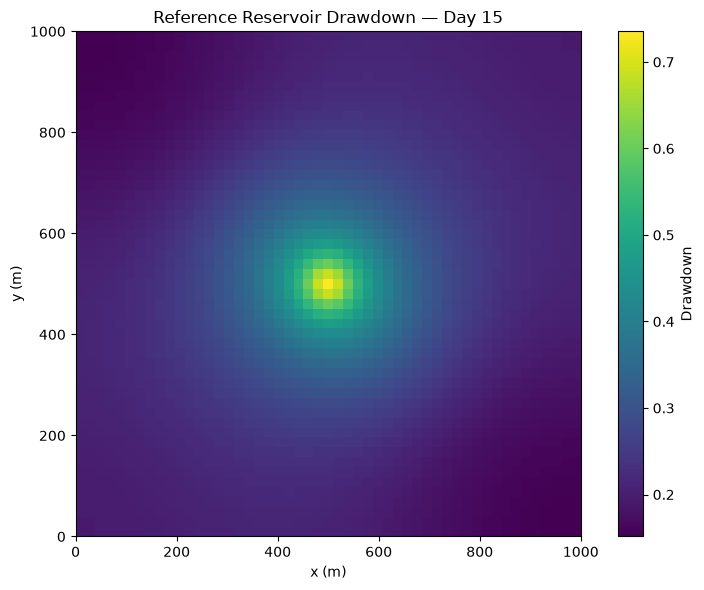

Reference 15-day drawdown map saved.
Maximum drawdown: 0.735392483649886
Well drawdown: 0.735392483649886


In [195]:
# 15-day reference drawdown

day = 15

target_time = day * 86400.0
time_index = np.argmin(
    np.abs(time_heterogeneous - target_time)
)

reference_drawdown_15 = (
    1.0 - pressure_well_gaussian_v2[time_index]
)

plt.figure(figsize=(8, 6))

plt.imshow(
    reference_drawdown_15.T,
    origin="lower",
    extent=[0, Lx, 0, Ly],
    aspect="equal"
)

plt.colorbar(label="Drawdown")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Reference Reservoir Drawdown — Day 15")

plt.tight_layout()

plt.savefig(
    "../results/reference_well_drawdown_t15.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Reference 15-day drawdown map saved.")
print("Maximum drawdown:",
      reference_drawdown_15.max())
print("Well drawdown:",
      reference_drawdown_15[well_i, well_j])

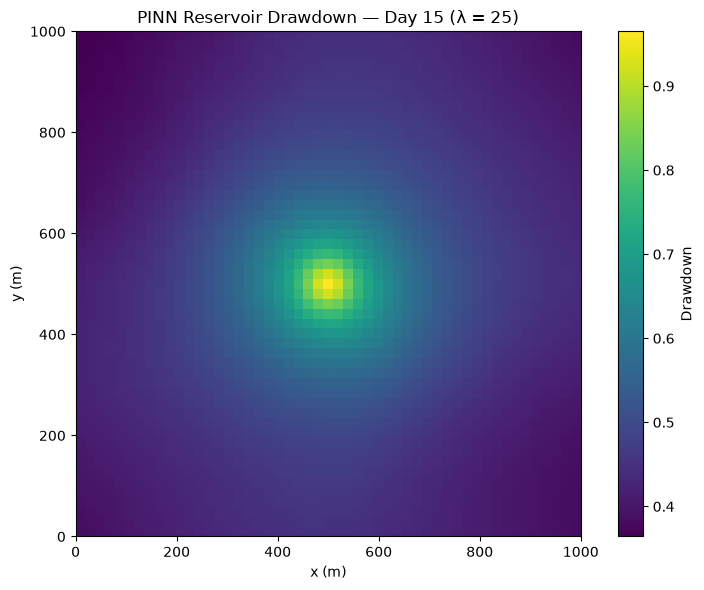

PINN 15-day drawdown map saved.
Maximum drawdown: 0.9650956
Well drawdown: 0.9650956


In [200]:
# 15-day lambda=25 PINN drawdown

pinn_drawdown_15 = (
    model_drawdown_conservation25(
        X_eval,
        training=False
    )
    .numpy()
    .reshape(X_perm.shape)
)

plt.figure(figsize=(8, 6))

plt.imshow(
    pinn_drawdown_15.T,
    origin="lower",
    extent=[0, Lx, 0, Ly],
    aspect="equal"
)

plt.colorbar(label="Drawdown")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("PINN Reservoir Drawdown — Day 15 (λ = 25)")

plt.tight_layout()

plt.savefig(
    "../results/well_driven_pinn_drawdown_t15.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("PINN 15-day drawdown map saved.")
print("Maximum drawdown:",
      pinn_drawdown_15.max())
print("Well drawdown:",
      pinn_drawdown_15[well_i, well_j])

In [201]:
#  Day-15 PINN prediction

day = 15

target_time = day * 86400.0
time_index = np.argmin(
    np.abs(time_heterogeneous - target_time)
)

t_star_15 = time_heterogeneous[time_index] / T

X_eval_15 = np.column_stack([
    X_perm.ravel() / Lx,
    Y_perm.ravel() / Ly,
    np.full(X_perm.size, t_star_15)
]).astype(np.float32)

pinn_drawdown_15 = (
    model_drawdown_conservation25(
        X_eval_15,
        training=False
    )
    .numpy()
    .reshape(X_perm.shape)
)

absolute_error_15 = np.abs(
    pinn_drawdown_15 - reference_drawdown_15
)

print("Correct Day-15 PINN prediction")
print("------------------------------")
print("PINN maximum drawdown:",
      pinn_drawdown_15.max())
print("PINN well drawdown:",
      pinn_drawdown_15[well_i, well_j])
print("MAE:",
      np.mean(absolute_error_15))
print("RMSE:",
      np.sqrt(np.mean(
          (pinn_drawdown_15 - reference_drawdown_15)**2
      )))
print("Maximum absolute error:",
      absolute_error_15.max())

Correct Day-15 PINN prediction
------------------------------
PINN maximum drawdown: 0.7045419
PINN well drawdown: 0.7045419
MAE: 0.014043045894191673
RMSE: 0.01712457659617427
Maximum absolute error: 0.053673763581407075


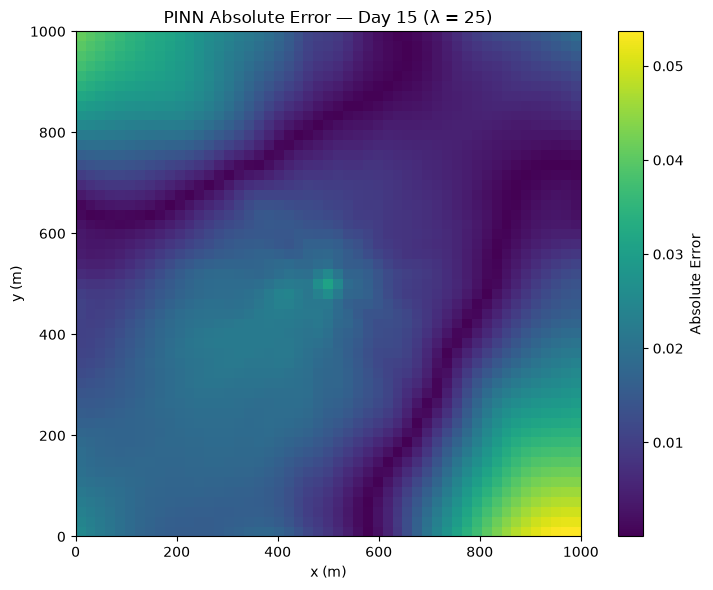

Correct Day-15 absolute error map saved.
MAE: 0.014043045894191673
Maximum absolute error: 0.053673763581407075


In [202]:
# Day-15 absolute error map

absolute_error_15 = np.abs(
    pinn_drawdown_15 - reference_drawdown_15
)

plt.figure(figsize=(8, 6))

plt.imshow(
    absolute_error_15.T,
    origin="lower",
    extent=[0, Lx, 0, Ly],
    aspect="equal"
)

plt.colorbar(label="Absolute Error")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("PINN Absolute Error — Day 15 (λ = 25)")

plt.tight_layout()

plt.savefig(
    "../results/well_driven_pinn_absolute_error_t15.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Correct Day-15 absolute error map saved.")
print("MAE:", np.mean(absolute_error_15))
print("Maximum absolute error:", absolute_error_15.max())

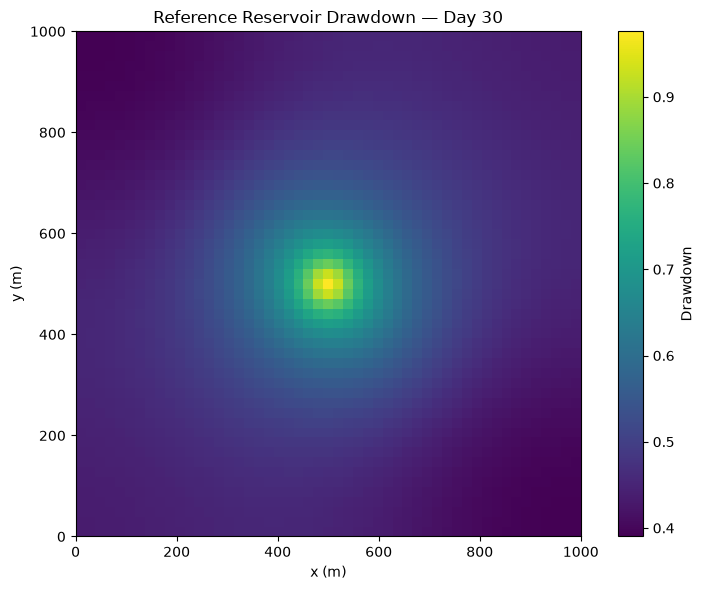

Reference 30-day drawdown map saved.
Maximum drawdown: 0.976002890630243
Well drawdown: 0.976002890630243


In [203]:
# 30-day reference drawdown

day = 30

target_time = day * 86400.0
time_index = np.argmin(
    np.abs(time_heterogeneous - target_time)
)

reference_drawdown_30 = (
    1.0 - pressure_well_gaussian_v2[time_index]
)

plt.figure(figsize=(8, 6))

plt.imshow(
    reference_drawdown_30.T,
    origin="lower",
    extent=[0, Lx, 0, Ly],
    aspect="equal"
)

plt.colorbar(label="Drawdown")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Reference Reservoir Drawdown — Day 30")

plt.tight_layout()

plt.savefig(
    "../results/reference_well_drawdown_t30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Reference 30-day drawdown map saved.")
print("Maximum drawdown:",
      reference_drawdown_30.max())
print("Well drawdown:",
      reference_drawdown_30[well_i, well_j])

In [204]:
# Correct Day-30 PINN prediction

day = 30

target_time = day * 86400.0
time_index = np.argmin(
    np.abs(time_heterogeneous - target_time)
)

t_star_30 = time_heterogeneous[time_index] / T

X_eval_30 = np.column_stack([
    X_perm.ravel() / Lx,
    Y_perm.ravel() / Ly,
    np.full(X_perm.size, t_star_30)
]).astype(np.float32)

pinn_drawdown_30 = (
    model_drawdown_conservation25(
        X_eval_30,
        training=False
    )
    .numpy()
    .reshape(X_perm.shape)
)

error_30 = (
    pinn_drawdown_30 - reference_drawdown_30
)

print("Day-30 lambda=25 PINN prediction")
print("--------------------------------")
print("PINN maximum drawdown:",
      pinn_drawdown_30.max())
print("PINN well drawdown:",
      pinn_drawdown_30[well_i, well_j])
print("MAE:",
      np.mean(np.abs(error_30)))
print("RMSE:",
      np.sqrt(np.mean(error_30**2)))
print("Maximum absolute error:",
      np.max(np.abs(error_30)))

Day-30 lambda=25 PINN prediction
--------------------------------
PINN maximum drawdown: 0.9650956
PINN well drawdown: 0.9650956
MAE: 0.009981767326530852
RMSE: 0.014070837668435133
Maximum absolute error: 0.0526326787703818


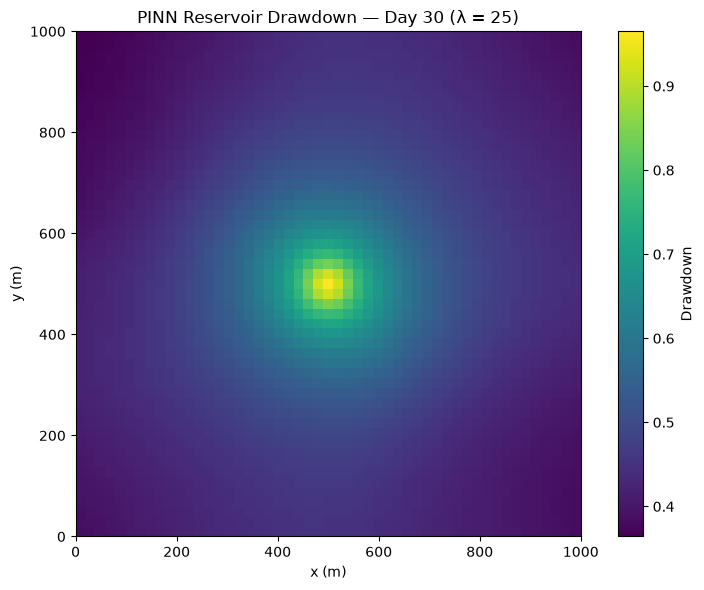

Day-30 PINN drawdown map saved.


In [205]:
# Day-30 lambda=25 PINN drawdown map

plt.figure(figsize=(8, 6))

plt.imshow(
    pinn_drawdown_30.T,
    origin="lower",
    extent=[0, Lx, 0, Ly],
    aspect="equal"
)

plt.colorbar(label="Drawdown")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("PINN Reservoir Drawdown — Day 30 (λ = 25)")

plt.tight_layout()

plt.savefig(
    "../results/well_driven_pinn_drawdown_t30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Day-30 PINN drawdown map saved.")

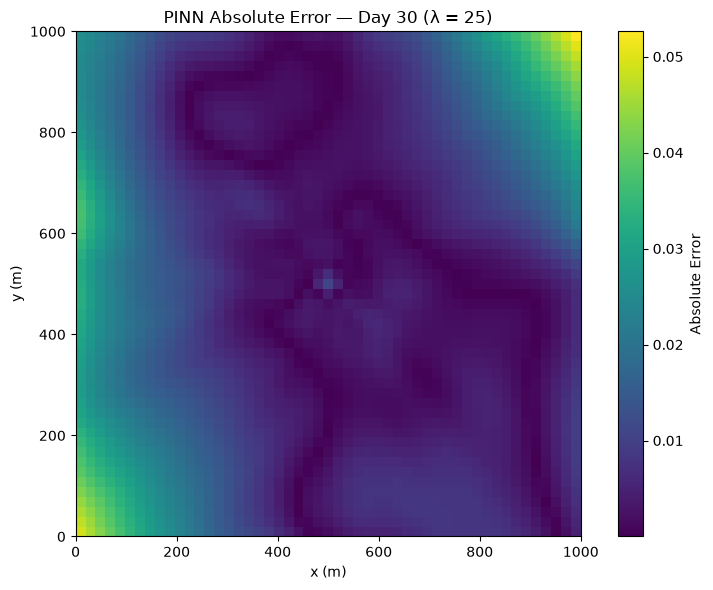

Day-30 absolute error map saved.
MAE: 0.009981767326530852
RMSE: 0.014070837668435133
Maximum absolute error: 0.0526326787703818


In [206]:
# Day-30 absolute error map

absolute_error_30 = np.abs(
    pinn_drawdown_30 - reference_drawdown_30
)

plt.figure(figsize=(8, 6))

plt.imshow(
    absolute_error_30.T,
    origin="lower",
    extent=[0, Lx, 0, Ly],
    aspect="equal"
)

plt.colorbar(label="Absolute Error")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("PINN Absolute Error — Day 30 (λ = 25)")

plt.tight_layout()

plt.savefig(
    "../results/well_driven_pinn_absolute_error_t30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Day-30 absolute error map saved.")
print("MAE:", np.mean(absolute_error_30))
print("RMSE:", np.sqrt(np.mean(
    (pinn_drawdown_30 - reference_drawdown_30)**2
)))
print("Maximum absolute error:",
      absolute_error_30.max())

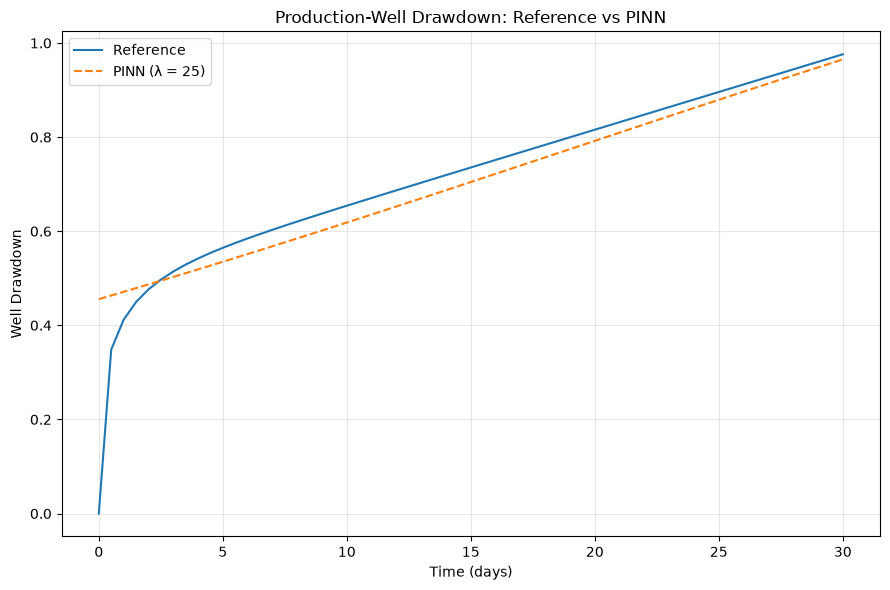

Well drawdown history saved.


In [207]:
# Well drawdown history: Reference vs PINN (lambda = 25)

plot_days = np.linspace(0, 30, 61)

reference_well_history = []
pinn_well_history = []

for day in plot_days:

    target_time = day * 86400.0
    time_index = np.argmin(
        np.abs(time_heterogeneous - target_time)
    )

    t_star = time_heterogeneous[time_index] / T

    # Reference well drawdown
    reference_drawdown = (
        1.0 - pressure_well_gaussian_v2[time_index]
    )

    reference_well_history.append(
        reference_drawdown[well_i, well_j]
    )

    # PINN prediction at well
    X_well = np.array([
        [well_x_actual / Lx,
         well_y_actual / Ly,
         t_star]
    ], dtype=np.float32)

    pinn_prediction = (
        model_drawdown_conservation25(
            X_well,
            training=False
        )
        .numpy()
        .squeeze()
    )

    pinn_well_history.append(float(pinn_prediction))

plt.figure(figsize=(9, 6))

plt.plot(
    plot_days,
    reference_well_history,
    label="Reference"
)

plt.plot(
    plot_days,
    pinn_well_history,
    "--",
    label="PINN (λ = 25)"
)

plt.xlabel("Time (days)")
plt.ylabel("Well Drawdown")
plt.title("Production-Well Drawdown: Reference vs PINN")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/well_drawdown_reference_vs_pinn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Well drawdown history saved.")